# 14 — LPIPS Metrics

**Origin:** Consolidates Existing Notebooks 11, 17, and 24  
**Refactor status:** Finished              
**Validation status:** Finished           
**Completion gate passed:** Yes              
**Output root:** `outputs/14_lpips_metrics/`  
**Depends on:** Notebook 02 geometry handoff and Notebooks 08–12A

## Purpose

Compute one normalized long-form LPIPS perceptual-distance table for every completed and technically valid restoration candidate in the controlled-300 evidence population.

The evaluated candidate universe contains:

- 2,620 OpenCV Telea candidates;
- 2,620 LaMa candidates;
- 8,520 Stable Diffusion 1.5 candidates;
- 24 technically validated SDXL candidates from the bounded 35-case attempt;
- 2,620 HINT candidates;
- 16,404 evaluated candidates in total;
- 1,200 zero-control candidates.

Eleven unsuccessful SDXL records—ten skipped and one timed out—remain explicit upstream exclusions. They do not receive placeholder LPIPS rows.

LPIPS is computed between:

1. the clean reference and damaged input;
2. the clean reference and restored candidate.

Restoration improvement is defined as:

`damaged LPIPS - restored LPIPS`

Positive improvement means that the restoration moved perceptually closer to the clean reference.

Canonical LPIPS evidence is restricted to spatially meaningful rectangular inputs:

- `content_region` for contextual evaluation;
- `mask_bbox_crop` as the primary local repair region.

Sparse masks and boundary pixels are prohibited because LPIPS requires ordered image-like spatial input. Full-image LPIPS is excluded because unchanged pixels and padded canvas areas dilute restoration effects. Sliding patch evaluation remains deferred.

Inputs are resized with preserved aspect ratio. Minimal neutral padding is used only when the shorter dimension would otherwise be below the LPIPS network’s safe spatial minimum.

SDXL remains an explicitly bounded partial scope. HINT is included as the selected deterministic learned production method. Missing or unsuccessful SDXL cases are never represented by placeholder metric rows.

The expected full LPIPS computation is approximately 35–90 minutes on the current RTX 3060 laptop, with a two-hour operational safety ceiling. Batch 4 is checkpointed and safe to resume after interruption.

In [1]:
from pathlib import Path
import json
import platform
import sys

import matplotlib
import numpy as np
import pandas as pd
import PIL
import torch
import yaml
from IPython.display import display


# ---------------------------------------------------------------------------
# Minimal repository bootstrap
# ---------------------------------------------------------------------------

CURRENT_DIRECTORY = Path.cwd().resolve()

PROJECT_ROOT_MATCHES = [
    candidate
    for candidate in (CURRENT_DIRECTORY, *CURRENT_DIRECTORY.parents)
    if (
        (candidate / ".git").exists()
        and (candidate / "src" / "restoration_eval").is_dir()
        and (candidate / "notebooks").is_dir()
    )
]

if not PROJECT_ROOT_MATCHES:
    raise FileNotFoundError(
        "Could not locate the painting-restoration repository root "
        f"from {CURRENT_DIRECTORY}."
    )

PROJECT_ROOT = PROJECT_ROOT_MATCHES[0]
SOURCE_DIRECTORY = PROJECT_ROOT / "src"

if str(SOURCE_DIRECTORY) not in sys.path:
    sys.path.insert(0, str(SOURCE_DIRECTORY))


# ---------------------------------------------------------------------------
# Versioned project helpers
# ---------------------------------------------------------------------------

from restoration_eval import __version__ as PACKAGE_VERSION

from restoration_eval.evaluation_inputs import (
    EVALUATION_INPUTS_MODULE_VERSION,
    EVALUATION_WORKLIST_SCHEMA_VERSION,
)

from restoration_eval.manifests import (
    MANIFESTS_MODULE_VERSION,
    sha256_file,
    utc_now_iso,
)

from restoration_eval.metrics_lpips import (
    LPIPS_ACTIVE_REGIONS,
    LPIPS_METRIC_VERSION,
    LPIPS_MODULE_NAME,
    LPIPS_MODULE_VERSION,
    LPIPS_SCHEMA_VERSION,
    get_package_version,
    load_lpips_config,
    resolve_lpips_device,
    validate_lpips_runtime_dependencies,
)

from restoration_eval.paths import (
    PATHS_MODULE_VERSION,
    ensure_output_subdirs,
    load_project_paths_registry,
    notebook_output_root,
    resolve_repo_path,
    to_repo_relative,
    validate_project_paths_registry,
)

from restoration_eval.regions import (
    REGIONS_MODULE_VERSION,
)

from restoration_eval.schemas import (
    CASE_REGISTRY_SCHEMA,
    LPIPS_METRICS_SCHEMA,
    MODEL_ELIGIBILITY_SCHEMA,
    PREPROCESSED_IMAGES_SCHEMA,
    REGION_POLICY_SCHEMA,
    RESTORATIONS_SCHEMA,
    SCHEMAS_MODULE_VERSION,
    SDXL_PARTIAL_CANDIDATES_SCHEMA,
    STABLE_DIFFUSION_CANDIDATES_SCHEMA,
)

from restoration_eval.validation import (
    VALIDATION_MODULE_VERSION,
    ValidationCollector,
)


# ---------------------------------------------------------------------------
# Notebook identity and owned output directories
# ---------------------------------------------------------------------------

NOTEBOOK_ID = "14"
NOTEBOOK_STEM = "14_lpips_metrics"
SUPPORTED_PYTHON_MINORS = {(3, 11), (3, 12)}
RUN_STARTED_AT_UTC = utc_now_iso()

NOTEBOOK_OUTPUT_ROOT = notebook_output_root(
    NOTEBOOK_STEM,
    PROJECT_ROOT,
    create=False,
)

OUTPUT_DIRECTORIES = ensure_output_subdirs(
    NOTEBOOK_STEM,
    (
        "metrics",
        "figures",
        "manifests",
        "validation",
        "work",
    ),
    PROJECT_ROOT,
)

print("Notebook 14 repository bootstrap complete.")
print("Project root:", PROJECT_ROOT)
print("Notebook output root:", NOTEBOOK_OUTPUT_ROOT)
print("LPIPS helper:", LPIPS_MODULE_NAME, LPIPS_MODULE_VERSION)
print("LPIPS metric version:", LPIPS_METRIC_VERSION)
print("LPIPS output schema:", LPIPS_SCHEMA_VERSION)
print("Run started at UTC:", RUN_STARTED_AT_UTC)

Notebook 14 repository bootstrap complete.
Project root: D:\Masters\FH\Thesis\painting-restoration-eval
Notebook output root: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\14_lpips_metrics
LPIPS helper: restoration_eval.metrics_lpips 3.0.0
LPIPS metric version: lpips_alex_full_reference.v1
LPIPS output schema: lpips_metrics.v1
Run started at UTC: 2026-09-14T11:07:43.749492Z


In [2]:
# ---------------------------------------------------------------------------
# Governing paths
# ---------------------------------------------------------------------------

LPIPS_CONFIG_PATH = (
    PROJECT_ROOT
    / "config"
    / "evaluation"
    / "lpips.yaml"
)

NOTEBOOK_ROADMAP_PATH = (
    PROJECT_ROOT
    / "docs"
    / "final_notebook_roadmap.md"
)

IMPLEMENTATION_GUIDELINES_PATH = (
    PROJECT_ROOT
    / "docs"
    / "refactoring_implementation_guidelines.md"
)

NOTEBOOK_PATH = (
    PROJECT_ROOT
    / "notebooks"
    / "14_lpips_metrics.ipynb"
)

HELPER_PATHS = {
    "evaluation_inputs_helper": (
        PROJECT_ROOT
        / "src"
        / "restoration_eval"
        / "evaluation_inputs.py"
    ),
    "lpips_metrics_helper": (
        PROJECT_ROOT
        / "src"
        / "restoration_eval"
        / "metrics_lpips.py"
    ),
    "regions_helper": (
        PROJECT_ROOT
        / "src"
        / "restoration_eval"
        / "regions.py"
    ),
    "schemas_helper": (
        PROJECT_ROOT
        / "src"
        / "restoration_eval"
        / "schemas.py"
    ),
}


# ---------------------------------------------------------------------------
# Approved LPIPS configuration
# ---------------------------------------------------------------------------

lpips_config = load_lpips_config(
    LPIPS_CONFIG_PATH
)

LPIPS_CONFIG = lpips_config["lpips_metrics"]
CONFIGURED_INPUTS = LPIPS_CONFIG["inputs"]
CONFIGURED_OUTPUTS = LPIPS_CONFIG["output"]
EXPECTED_COUNTS = LPIPS_CONFIG["expected_counts"]

if LPIPS_CONFIG["notebook_stem"] != NOTEBOOK_STEM:
    raise ValueError(
        "Configured notebook stem disagrees with Notebook 14."
    )

if CONFIGURED_OUTPUTS["root"] != f"outputs/{NOTEBOOK_STEM}":
    raise ValueError(
        "Configured output root disagrees with Notebook 14 ownership."
    )


# ---------------------------------------------------------------------------
# Explicit input paths
# ---------------------------------------------------------------------------

INPUTS = {
    "project_inventory": resolve_repo_path(
        CONFIGURED_INPUTS["inventory_path"],
        PROJECT_ROOT,
        must_exist=True,
    ),
    "inventory_run": resolve_repo_path(
        CONFIGURED_INPUTS["inventory_run_path"],
        PROJECT_ROOT,
        must_exist=True,
    ),
    "project_paths_registry": resolve_repo_path(
        CONFIGURED_INPUTS["project_paths_path"],
        PROJECT_ROOT,
        must_exist=True,
    ),
    "preprocessing_geometry": resolve_repo_path(
        CONFIGURED_INPUTS["geometry_path"],
        PROJECT_ROOT,
        must_exist=True,
    ),
    "preprocessing_run_manifest": resolve_repo_path(
        CONFIGURED_INPUTS["geometry_run_manifest_path"],
        PROJECT_ROOT,
        must_exist=True,
    ),
    "case_registry": resolve_repo_path(
        CONFIGURED_INPUTS["case_registry_path"],
        PROJECT_ROOT,
        must_exist=True,
    ),
    "model_eligibility": resolve_repo_path(
        CONFIGURED_INPUTS["model_eligibility_path"],
        PROJECT_ROOT,
        must_exist=True,
    ),
    "region_policy": resolve_repo_path(
        CONFIGURED_INPUTS["region_policy_path"],
        PROJECT_ROOT,
        must_exist=True,
    ),
    "schema_registry": resolve_repo_path(
        CONFIGURED_INPUTS["schema_registry_path"],
        PROJECT_ROOT,
        must_exist=True,
    ),
    "contracts_run_manifest": resolve_repo_path(
        CONFIGURED_INPUTS["contracts_run_manifest_path"],
        PROJECT_ROOT,
        must_exist=True,
    ),
    "contracts_artifacts": resolve_repo_path(
        CONFIGURED_INPUTS["contracts_artifacts_path"],
        PROJECT_ROOT,
        must_exist=True,
    ),
    "evaluation_contract_config": resolve_repo_path(
        CONFIGURED_INPUTS["evaluation_contract_config_path"],
        PROJECT_ROOT,
        must_exist=True,
    ),
}

SOURCE_CONFIGS = {
    item["source_table_id"]: item
    for item in CONFIGURED_INPUTS["upstream_sources"]
}

SOURCE_BY_MODEL = {
    item["model_id"]: item
    for item in CONFIGURED_INPUTS["upstream_sources"]
}

for source_id, source_config in SOURCE_CONFIGS.items():
    INPUTS[f"{source_id}_table"] = resolve_repo_path(
        source_config["path"],
        PROJECT_ROOT,
        must_exist=True,
    )
    INPUTS[f"{source_id}_run_manifest"] = resolve_repo_path(
        source_config["run_manifest_path"],
        PROJECT_ROOT,
        must_exist=True,
    )

CONFIGURATION_PATHS = {
    "lpips_metrics": LPIPS_CONFIG_PATH,
    "evaluation_contract": INPUTS["evaluation_contract_config"],
}

GOVERNING_PATHS = {
    "notebook_roadmap": NOTEBOOK_ROADMAP_PATH,
    "implementation_guidelines": IMPLEMENTATION_GUIDELINES_PATH,
    "notebook": NOTEBOOK_PATH,
}


# ---------------------------------------------------------------------------
# Canonical output paths
# ---------------------------------------------------------------------------

OUTPUTS = {
    "lpips_metrics": (
        NOTEBOOK_OUTPUT_ROOT
        / CONFIGURED_OUTPUTS["metrics_path"]
    ),
    "lpips_distributions": (
        NOTEBOOK_OUTPUT_ROOT
        / CONFIGURED_OUTPUTS["distributions_figure_path"]
    ),
    "run_manifest": (
        NOTEBOOK_OUTPUT_ROOT
        / CONFIGURED_OUTPUTS["run_manifest_path"]
    ),
    "artifacts": (
        NOTEBOOK_OUTPUT_ROOT
        / CONFIGURED_OUTPUTS["artifacts_path"]
    ),
    "validation": (
        NOTEBOOK_OUTPUT_ROOT
        / CONFIGURED_OUTPUTS["validation_path"]
    ),
}

WORK_PATHS = {
    "checkpoint": (
        NOTEBOOK_OUTPUT_ROOT
        / CONFIGURED_OUTPUTS["checkpoint_path"]
    ),
}


# ---------------------------------------------------------------------------
# Global discovery contracts
# ---------------------------------------------------------------------------

inventory_df = pd.read_csv(
    INPUTS["project_inventory"],
    low_memory=False,
)

with INPUTS["inventory_run"].open(
    "r",
    encoding="utf-8-sig",
) as handle:
    inventory_run = json.load(handle)

project_paths_registry = load_project_paths_registry(
    PROJECT_ROOT
)

inventory_relative_paths = set(
    inventory_df["relative_path"].astype(str)
)

registry_artifacts = {
    record["artifact_key"]: record
    for record in project_paths_registry["artifacts"]
}


# ---------------------------------------------------------------------------
# Upstream run manifests
# ---------------------------------------------------------------------------

UPSTREAM_MANIFEST_PATHS = {
    "notebook_02": INPUTS["preprocessing_run_manifest"],
    "notebook_08": INPUTS["contracts_run_manifest"],
}

for source_id in SOURCE_CONFIGS:
    UPSTREAM_MANIFEST_PATHS[source_id] = INPUTS[
        f"{source_id}_run_manifest"
    ]

upstream_manifests = {}

for producer, manifest_path in UPSTREAM_MANIFEST_PATHS.items():
    with manifest_path.open(
        "r",
        encoding="utf-8-sig",
    ) as handle:
        upstream_manifests[producer] = json.load(handle)

CONFIGURATION_CHECKSUMS = {
    key: sha256_file(path)
    for key, path in CONFIGURATION_PATHS.items()
}

HELPER_CHECKSUMS = {
    key: sha256_file(path)
    for key, path in HELPER_PATHS.items()
}

print("Notebook 14 paths and configurations loaded.")
print("Inventory run ID:", inventory_run["inventory_run_id"])
print("Inventory rows:", len(inventory_df))
print("Registry artifacts:", len(registry_artifacts))
print("Upstream run manifests:", len(upstream_manifests))
print("Declared canonical outputs:", len(OUTPUTS))

Notebook 14 paths and configurations loaded.
Inventory run ID: inventory_20260914T095930Z_adf5349b
Inventory rows: 39913
Registry artifacts: 235
Upstream run manifests: 7
Declared canonical outputs: 5


In [3]:
# ---------------------------------------------------------------------------
# Input contract
# ---------------------------------------------------------------------------

def input_contract_record(
    input_key,
    producer,
    path,
    file_format,
    schema_version,
    expected_cardinality,
    role,
):
    return {
        "input_key": input_key,
        "producer": producer,
        "relative_path": to_repo_relative(
            path,
            PROJECT_ROOT,
        ),
        "format": file_format,
        "schema_version": schema_version,
        "expected_cardinality": expected_cardinality,
        "role": role,
        "required": True,
    }


input_contract_records = [
    input_contract_record(
        "project_inventory",
        "tools/build_project_inventory.py",
        INPUTS["project_inventory"],
        "csv",
        "project_file_inventory.v1",
        inventory_run["summary"]["file_count"],
        "repository discovery",
    ),
    input_contract_record(
        "inventory_run",
        "tools/build_project_inventory.py",
        INPUTS["inventory_run"],
        "json",
        "inventory_run.v1",
        1,
        "inventory provenance",
    ),
    input_contract_record(
        "project_paths_registry",
        "validated notebook handoffs",
        INPUTS["project_paths_registry"],
        "json",
        "project_paths.v1",
        len(project_paths_registry["artifacts"]),
        "artifact discovery",
    ),
    input_contract_record(
        "preprocessing_geometry",
        "Notebook 02",
        INPUTS["preprocessing_geometry"],
        "csv",
        PREPROCESSED_IMAGES_SCHEMA.version,
        EXPECTED_COUNTS["preprocessing_geometry_rows"],
        "painting-content geometry",
    ),
    input_contract_record(
        "case_registry",
        "Notebook 08",
        INPUTS["case_registry"],
        "csv",
        CASE_REGISTRY_SCHEMA.version,
        EXPECTED_COUNTS["case_registry_rows"],
        "normalized evaluation cases",
    ),
    input_contract_record(
        "model_eligibility",
        "Notebook 08",
        INPUTS["model_eligibility"],
        "csv",
        MODEL_ELIGIBILITY_SCHEMA.version,
        EXPECTED_COUNTS["model_eligibility_rows"],
        "model/case routing",
    ),
    input_contract_record(
        "region_policy",
        "Notebook 08",
        INPUTS["region_policy"],
        "csv",
        REGION_POLICY_SCHEMA.version,
        143,
        "metric-region compatibility",
    ),
    input_contract_record(
        "schema_registry",
        "Notebook 08",
        INPUTS["schema_registry"],
        "json",
        "schema_registry.v1",
        1,
        "upstream schema discovery",
    ),
    input_contract_record(
        "contracts_artifacts",
        "Notebook 08",
        INPUTS["contracts_artifacts"],
        "csv",
        "artifact_manifest.v1",
        "one or more",
        "upstream artifact evidence",
    ),
    input_contract_record(
        "lpips_metrics_config",
        "Repository configuration",
        LPIPS_CONFIG_PATH,
        "yaml",
        lpips_config["config_schema_version"],
        1,
        "LPIPS definitions and numerical policy",
    ),
    input_contract_record(
        "evaluation_contract_config",
        "Repository configuration",
        INPUTS["evaluation_contract_config"],
        "yaml",
        "evaluation_contract_config.v1",
        1,
        "region and eligibility policy",
    ),
]

for producer, manifest_path in UPSTREAM_MANIFEST_PATHS.items():
    input_contract_records.append(
        input_contract_record(
            f"{producer}_run_manifest",
            producer,
            manifest_path,
            "json",
            "run_manifest.v1",
            1,
            "completed upstream run evidence",
        )
    )

for source_id, source_config in SOURCE_CONFIGS.items():
    model_id = source_config["model_id"]

    input_contract_records.append(
        input_contract_record(
            f"{source_id}_table",
            source_id,
            INPUTS[f"{source_id}_table"],
            "csv",
            source_config["schema_version"],
            EXPECTED_COUNTS["source_rows_by_model"][model_id],
            f"{model_id} restoration candidates",
        )
    )

input_contract_df = pd.DataFrame(
    input_contract_records
)


# ---------------------------------------------------------------------------
# Output contract
# ---------------------------------------------------------------------------

output_contract_df = pd.DataFrame(
    [
        {
            "artifact_key": "lpips_metrics.metrics",
            "relative_path": to_repo_relative(
                OUTPUTS["lpips_metrics"],
                PROJECT_ROOT,
            ),
            "format": "csv",
            "schema_version": LPIPS_METRICS_SCHEMA.version,
            "expected_cardinality": EXPECTED_COUNTS["total_metric_rows"],
            "role": "primary downstream evidence",
        },
        {
            "artifact_key": "lpips_metrics.distributions",
            "relative_path": to_repo_relative(
                OUTPUTS["lpips_distributions"],
                PROJECT_ROOT,
            ),
            "format": "png",
            "schema_version": "figure.lpips_distributions.v1",
            "expected_cardinality": 1,
            "role": "compact LPIPS diagnostic visualization",
        },
        {
            "artifact_key": "lpips_metrics.run_manifest",
            "relative_path": to_repo_relative(
                OUTPUTS["run_manifest"],
                PROJECT_ROOT,
            ),
            "format": "json",
            "schema_version": "run_manifest.v1",
            "expected_cardinality": 1,
            "role": "run provenance",
        },
        {
            "artifact_key": "lpips_metrics.artifacts",
            "relative_path": to_repo_relative(
                OUTPUTS["artifacts"],
                PROJECT_ROOT,
            ),
            "format": "csv",
            "schema_version": "artifact_manifest.v1",
            "expected_cardinality": "canonical artifacts only",
            "role": "artifact handoff",
        },
        {
            "artifact_key": "lpips_metrics.validation",
            "relative_path": to_repo_relative(
                OUTPUTS["validation"],
                PROJECT_ROOT,
            ),
            "format": "csv",
            "schema_version": "validation_checks.v1",
            "expected_cardinality": "consolidated checks",
            "role": "validation evidence",
        },
    ]
)

display(input_contract_df)
display(output_contract_df)

print("Notebook 14 input/output contracts constructed.")
print("Input contract rows:", len(input_contract_df))
print("Canonical output contract rows:", len(output_contract_df))

,input_key,producer,relative_path,format,schema_version,expected_cardinality,role,required
0,project_inventory,tools/build_project_inventory.py,outputs/inventory/project_file_inventory.csv,csv,project_file_inventory.v1,39913,repository discovery,True
1,inventory_run,tools/build_project_inventory.py,outputs/inventory/inventory_run.json,json,inventory_run.v1,1,inventory provenance,True
2,project_paths_registry,validated notebook handoffs,outputs/inventory/project_paths.json,json,project_paths.v1,235,artifact discovery,True
3,preprocessing_geometry,Notebook 02,outputs/02_image_preprocessing/data/preprocess...,csv,preprocessed_images.v1,300,painting-content geometry,True
4,case_registry,Notebook 08,outputs/08_experiment_contracts_and_region_pol...,csv,case_registry.v1,3425,normalized evaluation cases,True
5,model_eligibility,Notebook 08,outputs/08_experiment_contracts_and_region_pol...,csv,model_eligibility.v1,17125,model/case routing,True
6,region_policy,Notebook 08,outputs/08_experiment_contracts_and_region_pol...,csv,region_policy.v1,143,metric-region compatibility,True
7,schema_registry,Notebook 08,outputs/08_experiment_contracts_and_region_pol...,json,schema_registry.v1,1,upstream schema discovery,True
8,contracts_artifacts,Notebook 08,outputs/08_experiment_contracts_and_region_pol...,csv,artifact_manifest.v1,one or more,upstream artifact evidence,True
9,lpips_metrics_config,Repository configuration,config/evaluation/lpips.yaml,yaml,lpips_metrics_config.v1,1,LPIPS definitions and numerical policy,True


,artifact_key,relative_path,format,schema_version,expected_cardinality,role
0,lpips_metrics.metrics,outputs/14_lpips_metrics/metrics/lpips_metrics...,csv,lpips_metrics.v1,31608,primary downstream evidence
1,lpips_metrics.distributions,outputs/14_lpips_metrics/figures/lpips_distrib...,png,figure.lpips_distributions.v1,1,compact LPIPS diagnostic visualization
2,lpips_metrics.run_manifest,outputs/14_lpips_metrics/manifests/run_manifes...,json,run_manifest.v1,1,run provenance
3,lpips_metrics.artifacts,outputs/14_lpips_metrics/manifests/artifacts.csv,csv,artifact_manifest.v1,canonical artifacts only,artifact handoff
4,lpips_metrics.validation,outputs/14_lpips_metrics/validation/checks.csv,csv,validation_checks.v1,consolidated checks,validation evidence


Notebook 14 input/output contracts constructed.
Input contract rows: 23
Canonical output contract rows: 5


In [4]:
# ---------------------------------------------------------------------------
# Runtime dependency policy
# ---------------------------------------------------------------------------

dependency_status_df = (
    validate_lpips_runtime_dependencies()
)

resolved_device = resolve_lpips_device(
    lpips_config
)


# ---------------------------------------------------------------------------
# Region and transform policy
# ---------------------------------------------------------------------------

active_region_policy_df = pd.DataFrame(
    [
        {
            "region_id": region_id,
            "role": (
                "primary local region"
                if region_id
                == LPIPS_CONFIG["regions"]["primary_local_region"]
                else "contextual region"
            ),
            "spatial_support": "rectangle",
            "included": True,
        }
        for region_id in LPIPS_CONFIG["regions"]["active_regions"]
    ]
)

excluded_region_policy_df = pd.DataFrame(
    [
        {
            "region_scope": region_scope,
            "included": False,
            "reason": reason,
        }
        for region_scope, reason in (
            LPIPS_CONFIG["regions"]["excluded_regions"].items()
        )
    ]
)

transform_policy_df = pd.DataFrame(
    [
        {
            "network": LPIPS_CONFIG["model"]["network"],
            "lpips_version": LPIPS_CONFIG["model"]["lpips_version"],
            "preferred_device": LPIPS_CONFIG["model"]["preferred_device"],
            "resolved_device": resolved_device,
            "maximum_side_pixels": LPIPS_CONFIG[
                "transform"
            ]["maximum_side_pixels"],
            "minimum_side_pixels": LPIPS_CONFIG[
                "transform"
            ]["minimum_side_pixels"],
            "interpolation": LPIPS_CONFIG[
                "transform"
            ]["interpolation"],
            "padding_mode": LPIPS_CONFIG[
                "transform"
            ]["padding_mode"],
            "resize_policy": LPIPS_CONFIG[
                "transform"
            ]["resize_policy"],
            "batch_size": LPIPS_CONFIG[
                "execution"
            ]["batch_size"],
        }
    ]
)


# ---------------------------------------------------------------------------
# Expected cardinalities
# ---------------------------------------------------------------------------

expected_count_records = []

for count_key, expected_value in EXPECTED_COUNTS.items():
    if isinstance(expected_value, dict):
        continue

    expected_count_records.append(
        {
            "count_scope": "overall",
            "count_key": count_key,
            "expected_value": expected_value,
        }
    )

for model_id, candidate_count in (
    EXPECTED_COUNTS["candidates_by_model"].items()
):
    expected_count_records.append(
        {
            "count_scope": "model_candidates",
            "count_key": model_id,
            "expected_value": candidate_count,
        }
    )

for model_id, metric_row_count in (
    EXPECTED_COUNTS["metric_rows_by_model"].items()
):
    expected_count_records.append(
        {
            "count_scope": "model_metric_rows",
            "count_key": model_id,
            "expected_value": metric_row_count,
        }
    )

expected_counts_df = pd.DataFrame(
    expected_count_records
)

display(dependency_status_df)
display(active_region_policy_df)
display(excluded_region_policy_df)
display(transform_policy_df)
display(expected_counts_df)

print("LPIPS scientific and execution policies loaded.")
print("Resolved device:", resolved_device)
print("Expected candidates:", EXPECTED_COUNTS["evaluated_candidates"])
print("Expected content-region rows:", EXPECTED_COUNTS["content_region_rows"])
print("Expected mask-bbox rows:", EXPECTED_COUNTS["mask_bbox_crop_rows"])
print("Expected LPIPS rows:", EXPECTED_COUNTS["total_metric_rows"])
print("Expected damaged-baseline evaluations:", EXPECTED_COUNTS["damaged_baseline_pairs"])

,dependency,version,installed,status
0,lpips,0.1.4,True,passed
1,torch,2.5.1+cu121,True,passed
2,torchvision,0.20.1+cu121,True,passed
3,numpy,1.26.4,True,passed
4,pandas,2.3.3,True,passed
5,Pillow,9.5.0,True,passed


,region_id,role,spatial_support,included
0,content_region,contextual region,rectangle,True
1,mask_bbox_crop,primary local region,rectangle,True


,region_scope,included,reason
0,full_image,False,Compatible diagnostic but excluded because unc...
1,sparse_regions,False,Prohibited because LPIPS requires contiguous i...
2,patch_window,False,Deferred to later sliding-window and local ana...


,network,lpips_version,preferred_device,resolved_device,maximum_side_pixels,minimum_side_pixels,interpolation,padding_mode,resize_policy,batch_size
0,alex,0.1,cuda,cuda,256,64,bicubic,neutral_constant,longest_side_256_preserve_aspect_min_side_64_n...,16


,count_scope,count_key,expected_value
0,overall,preprocessing_geometry_rows,300
1,overall,case_registry_rows,3425
2,overall,model_eligibility_rows,17125
3,overall,eligible_case_model_pairs,13100
4,overall,evaluated_unique_cases,2620
5,overall,evaluated_candidates,16404
6,overall,zero_control_cases,300
7,overall,zero_control_candidates,1200
8,overall,excluded_candidates,11
9,overall,damaged_baseline_pairs,4940


LPIPS scientific and execution policies loaded.
Resolved device: cuda
Expected candidates: 16404
Expected content-region rows: 16404
Expected mask-bbox rows: 15204
Expected LPIPS rows: 31608
Expected damaged-baseline evaluations: 4940


In [5]:
# ---------------------------------------------------------------------------
# Batch 1 validation
# ---------------------------------------------------------------------------

VALIDATION = ValidationCollector()


def add_batch_1_check(
    check_id,
    description,
    expected,
    observed,
    passed,
    details="",
    severity="blocking",
):
    VALIDATION.add(
        validation_stage="batch_1_preflight",
        check_id=check_id,
        check_description=description,
        severity=severity,
        expected=expected,
        observed=observed,
        passed=bool(passed),
        details=details,
    )


# ---------------------------------------------------------------------------
# Runtime, helper, and schema checks
# ---------------------------------------------------------------------------

python_minor = (
    sys.version_info.major,
    sys.version_info.minor,
)

add_batch_1_check(
    "supported_python",
    "Python is one of the approved 3.11 or 3.12 runtimes.",
    sorted(SUPPORTED_PYTHON_MINORS),
    python_minor,
    python_minor in SUPPORTED_PYTHON_MINORS,
)

add_batch_1_check(
    "lpips_dependencies_installed",
    "All required LPIPS runtime dependencies are installed.",
    [],
    dependency_status_df.loc[
        ~dependency_status_df["installed"],
        "dependency",
    ].tolist(),
    dependency_status_df["installed"].all(),
)

add_batch_1_check(
    "lpips_schema_registered",
    "The normalized LPIPS metric schema is registered.",
    LPIPS_SCHEMA_VERSION,
    LPIPS_METRICS_SCHEMA.version,
    LPIPS_METRICS_SCHEMA.version == LPIPS_SCHEMA_VERSION,
)

add_batch_1_check(
    "lpips_metric_version_frozen",
    "Configuration and helper use the same metric version.",
    LPIPS_METRIC_VERSION,
    LPIPS_CONFIG["metric_version"],
    LPIPS_CONFIG["metric_version"] == LPIPS_METRIC_VERSION,
)

add_batch_1_check(
    "lpips_network",
    "AlexNet is the approved LPIPS backbone.",
    "alex",
    LPIPS_CONFIG["model"]["network"],
    LPIPS_CONFIG["model"]["network"] == "alex",
)

add_batch_1_check(
    "cuda_available",
    "CUDA is available for the preferred LPIPS execution path.",
    True,
    torch.cuda.is_available(),
    torch.cuda.is_available(),
    details=(
        torch.cuda.get_device_name(0)
        if torch.cuda.is_available()
        else "CPU fallback will be used."
    ),
    severity="warning",
)

add_batch_1_check(
    "resolved_device",
    "The LPIPS execution device resolves successfully.",
    {"cuda", "cpu"},
    resolved_device,
    resolved_device in {"cuda", "cpu"},
)

add_batch_1_check(
    "notebook_output_root",
    "The configured output root belongs exclusively to Notebook 14.",
    f"outputs/{NOTEBOOK_STEM}",
    to_repo_relative(
        NOTEBOOK_OUTPUT_ROOT,
        PROJECT_ROOT,
    ),
    (
        to_repo_relative(
            NOTEBOOK_OUTPUT_ROOT,
            PROJECT_ROOT,
        )
        == f"outputs/{NOTEBOOK_STEM}"
    ),
)


# ---------------------------------------------------------------------------
# Inventory validation
# ---------------------------------------------------------------------------

inventory_summary = inventory_run["summary"]

add_batch_1_check(
    "inventory_completed",
    "The refreshed inventory completed successfully.",
    "completed",
    inventory_run["status"],
    inventory_run["status"] == "completed",
)

add_batch_1_check(
    "inventory_read_errors",
    "The refreshed inventory contains no read errors.",
    0,
    inventory_summary["read_error_count"],
    inventory_summary["read_error_count"] == 0,
)

add_batch_1_check(
    "inventory_row_count",
    "Inventory rows match the inventory-run manifest.",
    inventory_summary["file_count"],
    len(inventory_df),
    len(inventory_df) == inventory_summary["file_count"],
)

observed_inventory_sha256 = sha256_file(
    INPUTS["project_inventory"]
)

add_batch_1_check(
    "inventory_checksum",
    "The inventory CSV checksum matches its run manifest.",
    inventory_run["inventory_sha256"],
    observed_inventory_sha256,
    (
        observed_inventory_sha256
        == inventory_run["inventory_sha256"]
    ),
)


# ---------------------------------------------------------------------------
# Declared file existence and inventory coverage
# ---------------------------------------------------------------------------

DECLARED_FILES = {
    **INPUTS,
    **CONFIGURATION_PATHS,
    **GOVERNING_PATHS,
    **HELPER_PATHS,
}

for file_key, file_path in DECLARED_FILES.items():
    add_batch_1_check(
        f"declared_file_exists_{file_key}",
        f"Declared file {file_key!r} exists.",
        True,
        file_path.exists(),
        file_path.exists(),
        details=to_repo_relative(
            file_path,
            PROJECT_ROOT,
        ),
    )

inventory_self_keys = {
    "project_inventory",
    "inventory_run",
}

missing_inventory_files = {
    file_key: to_repo_relative(
        file_path,
        PROJECT_ROOT,
    )
    for file_key, file_path in DECLARED_FILES.items()
    if (
        file_key not in inventory_self_keys
        and to_repo_relative(
            file_path,
            PROJECT_ROOT,
        )
        not in inventory_relative_paths
    )
}

add_batch_1_check(
    "declared_files_in_inventory",
    "Every non-self-referential declared file appears in the refreshed inventory.",
    {},
    missing_inventory_files,
    not missing_inventory_files,
)


# ---------------------------------------------------------------------------
# Legacy cleanup validation
# ---------------------------------------------------------------------------

legacy_exact_paths = {
    "notebooks/17_lama_lpips_metrics.ipynb",
    "notebooks/24_stable_diffusion_lpips_metrics.ipynb",
    "data/processed/metrics/metrics_opencv_telea_lpips.csv",
    "outputs/manifests/17_lama_lpips_metrics_manifest.json",
}

legacy_prefixes = (
    "outputs/24_stable_diffusion_lpips_metrics/",
    "outputs/figures/17_lama_lpips_metrics/",
    "outputs/figures/opencv_lpips_metrics/",
)

legacy_inventory_hits = sorted(
    relative_path
    for relative_path in inventory_relative_paths
    if (
        relative_path in legacy_exact_paths
        or any(
            relative_path.startswith(prefix)
            for prefix in legacy_prefixes
        )
        or (
            relative_path.startswith("outputs/metrics/lpips_")
            and "lama" in relative_path.lower()
        )
        or (
            relative_path.startswith("outputs/validation/lpips_")
            and "lama" in relative_path.lower()
        )
    )
)

add_batch_1_check(
    "legacy_lpips_artifacts_absent",
    "Deleted legacy LPIPS notebooks and owned outputs are absent.",
    [],
    legacy_inventory_hits,
    not legacy_inventory_hits,
)


# ---------------------------------------------------------------------------
# Upstream run manifests
# ---------------------------------------------------------------------------

for producer, manifest in upstream_manifests.items():
    add_batch_1_check(
        f"{producer}_run_completed",
        f"{producer} completed successfully.",
        "completed",
        manifest.get("run_status"),
        manifest.get("run_status") == "completed",
    )

    add_batch_1_check(
        f"{producer}_completion_gate",
        f"{producer} passed its completion gate.",
        True,
        manifest.get("completion_gate_passed"),
        manifest.get("completion_gate_passed") is True,
    )

    add_batch_1_check(
        f"{producer}_validation_status",
        f"{producer} has passed validation status.",
        "passed",
        manifest.get("validation_status"),
        manifest.get("validation_status") == "passed",
    )


# ---------------------------------------------------------------------------
# Project-path registry
# ---------------------------------------------------------------------------

project_paths_errors = validate_project_paths_registry(
    project_paths_registry
)

add_batch_1_check(
    "project_paths_registry_valid",
    "The authoritative project-path registry is structurally valid.",
    [],
    project_paths_errors,
    not project_paths_errors,
)

registry_expectations = {
    "preprocessing.geometry": CONFIGURED_INPUTS["geometry_path"],
    "experiment_contracts.case_registry": CONFIGURED_INPUTS["case_registry_path"],
    "experiment_contracts.model_eligibility": CONFIGURED_INPUTS["model_eligibility_path"],
    "experiment_contracts.region_policy": CONFIGURED_INPUTS["region_policy_path"],
    "experiment_contracts.schema_registry": CONFIGURED_INPUTS["schema_registry_path"],
    "opencv_telea.restorations": SOURCE_BY_MODEL["opencv_telea"]["path"],
    "lama.restorations": SOURCE_BY_MODEL["lama"]["path"],
    "stable_diffusion.candidates": SOURCE_BY_MODEL[
        "stable_diffusion_inpainting"
    ]["path"],
    "sdxl.candidates": SOURCE_BY_MODEL["sdxl_inpainting"]["path"],
    "hint.restorations": SOURCE_BY_MODEL["hint_places2"]["path"],
}

for artifact_key, expected_path in registry_expectations.items():
    record = registry_artifacts.get(artifact_key)

    observed = {
        "relative_path": (
            record["relative_path"]
            if record
            else ""
        ),
        "validation_status": (
            record["validation_status"]
            if record
            else ""
        ),
    }

    expected = {
        "relative_path": expected_path,
        "validation_status": "passed",
    }

    add_batch_1_check(
        "registry_" + artifact_key.replace(".", "_"),
        f"Registry artifact {artifact_key!r} matches the approved path.",
        expected,
        observed,
        record is not None and observed == expected,
    )


# ---------------------------------------------------------------------------
# Scientific policy and cardinality checks
# ---------------------------------------------------------------------------

configured_models = {
    source["model_id"]
    for source in SOURCE_CONFIGS.values()
}

approved_models = {
    "opencv_telea",
    "lama",
    "stable_diffusion_inpainting",
    "sdxl_inpainting",
    "hint_places2",
}

add_batch_1_check(
    "all_five_models_configured",
    "All five approved restoration models are included.",
    approved_models,
    configured_models,
    configured_models == approved_models,
)

add_batch_1_check(
    "total_candidate_count",
    "The approved candidate universe contains 16,404 rows.",
    16404,
    EXPECTED_COUNTS["evaluated_candidates"],
    EXPECTED_COUNTS["evaluated_candidates"] == 16404,
)

add_batch_1_check(
    "content_region_row_count",
    "Every candidate receives one content-region LPIPS row.",
    16404,
    EXPECTED_COUNTS["content_region_rows"],
    EXPECTED_COUNTS["content_region_rows"] == 16404,
)

add_batch_1_check(
    "mask_bbox_row_count",
    "Every non-zero candidate receives one mask-bbox LPIPS row.",
    15204,
    EXPECTED_COUNTS["mask_bbox_crop_rows"],
    EXPECTED_COUNTS["mask_bbox_crop_rows"] == 15204,
)

add_batch_1_check(
    "total_lpips_row_count",
    "The normalized output contains 31,608 LPIPS rows.",
    31608,
    EXPECTED_COUNTS["total_metric_rows"],
    EXPECTED_COUNTS["total_metric_rows"] == 31608,
)

add_batch_1_check(
    "damaged_baseline_count",
    "Damaged LPIPS baselines are computed once per unique case-region.",
    4940,
    EXPECTED_COUNTS["damaged_baseline_pairs"],
    EXPECTED_COUNTS["damaged_baseline_pairs"] == 4940,
)

add_batch_1_check(
    "active_regions_exact",
    "Only content and mask-bounding-box crops are canonical.",
    {
        "content_region",
        "mask_bbox_crop",
    },
    set(LPIPS_CONFIG["regions"]["active_regions"]),
    (
        set(LPIPS_CONFIG["regions"]["active_regions"])
        == {
            "content_region",
            "mask_bbox_crop",
        }
    ),
)

add_batch_1_check(
    "full_image_excluded",
    "Full-image LPIPS is excluded from canonical execution.",
    False,
    "full_image" in LPIPS_CONFIG["regions"]["active_regions"],
    "full_image" not in LPIPS_CONFIG["regions"]["active_regions"],
)

add_batch_1_check(
    "patch_window_deferred",
    "Sliding patch-window LPIPS is deferred.",
    False,
    "patch_window" in LPIPS_CONFIG["regions"]["active_regions"],
    "patch_window" not in LPIPS_CONFIG["regions"]["active_regions"],
)

add_batch_1_check(
    "aspect_preserving_transform",
    "The LPIPS transform explicitly preserves aspect ratio.",
    True,
    (
        "preserve_aspect"
        in LPIPS_CONFIG["transform"]["resize_policy"]
    ),
    (
        "preserve_aspect"
        in LPIPS_CONFIG["transform"]["resize_policy"]
    ),
)

add_batch_1_check(
    "safe_input_dimensions",
    "LPIPS input bounds are fixed at 64–256 pixels.",
    {
        "minimum": 64,
        "maximum": 256,
    },
    {
        "minimum": LPIPS_CONFIG[
            "transform"
        ]["minimum_side_pixels"],
        "maximum": LPIPS_CONFIG[
            "transform"
        ]["maximum_side_pixels"],
    },
    (
        LPIPS_CONFIG["transform"]["minimum_side_pixels"] == 64
        and LPIPS_CONFIG["transform"]["maximum_side_pixels"] == 256
    ),
)

add_batch_1_check(
    "progress_interval",
    "Long execution reports progress every ten cases.",
    10,
    LPIPS_CONFIG["execution"]["progress_interval_cases"],
    LPIPS_CONFIG["execution"]["progress_interval_cases"] == 10,
)

add_batch_1_check(
    "checkpoint_interval",
    "Long execution checkpoints every ten cases.",
    10,
    LPIPS_CONFIG["execution"]["checkpoint_interval_cases"],
    LPIPS_CONFIG["execution"]["checkpoint_interval_cases"] == 10,
)


# ---------------------------------------------------------------------------
# Output ownership
# ---------------------------------------------------------------------------

output_scope_errors = []

for output_key, output_path in {
    **OUTPUTS,
    **WORK_PATHS,
}.items():
    try:
        output_path.resolve().relative_to(
            NOTEBOOK_OUTPUT_ROOT.resolve()
        )
    except ValueError:
        output_scope_errors.append(
            {
                "output_key": output_key,
                "path": str(output_path),
            }
        )

add_batch_1_check(
    "all_outputs_owned_by_notebook",
    "Every canonical and temporary output remains under Notebook 14.",
    [],
    output_scope_errors,
    not output_scope_errors,
)


# ---------------------------------------------------------------------------
# Batch gate
# ---------------------------------------------------------------------------

batch_1_validation_df = VALIDATION.to_dataframe()

display(batch_1_validation_df)

VALIDATION.raise_for_blocking()

print("Batch 1 preflight passed.")
print("Validation checks:", len(batch_1_validation_df))
print("Blocking failures:", len(VALIDATION.blocking_failures))
print("Inventory run ID:", inventory_run["inventory_run_id"])
print("Resolved LPIPS device:", resolved_device)
print("LPIPS package version:", get_package_version("lpips"))
print("Torch version:", torch.__version__)
print("Approved candidates:", EXPECTED_COUNTS["evaluated_candidates"])
print("Approved LPIPS rows:", EXPECTED_COUNTS["total_metric_rows"])
print("Expected damaged-baseline evaluations:", EXPECTED_COUNTS["damaged_baseline_pairs"])

,validation_stage,check_id,check_description,severity,expected,observed,passed,details
0,batch_1_preflight,supported_python,Python is one of the approved 3.11 or 3.12 run...,blocking,"[[3, 11], [3, 12]]","[3, 12]",True,
1,batch_1_preflight,lpips_dependencies_installed,All required LPIPS runtime dependencies are in...,blocking,[],[],True,
2,batch_1_preflight,lpips_schema_registered,The normalized LPIPS metric schema is registered.,blocking,lpips_metrics.v1,lpips_metrics.v1,True,
3,batch_1_preflight,lpips_metric_version_frozen,Configuration and helper use the same metric v...,blocking,lpips_alex_full_reference.v1,lpips_alex_full_reference.v1,True,
4,batch_1_preflight,lpips_network,AlexNet is the approved LPIPS backbone.,blocking,alex,alex,True,
...,...,...,...,...,...,...,...,...
86,batch_1_preflight,aspect_preserving_transform,The LPIPS transform explicitly preserves aspec...,blocking,True,True,True,
87,batch_1_preflight,safe_input_dimensions,LPIPS input bounds are fixed at 64–256 pixels.,blocking,"{""maximum"": 256, ""minimum"": 64}","{""maximum"": 256, ""minimum"": 64}",True,
88,batch_1_preflight,progress_interval,Long execution reports progress every ten cases.,blocking,10,10,True,
89,batch_1_preflight,checkpoint_interval,Long execution checkpoints every ten cases.,blocking,10,10,True,


Batch 1 preflight passed.
Validation checks: 91
Blocking failures: 0
Inventory run ID: inventory_20260914T095930Z_adf5349b
Resolved LPIPS device: cuda
LPIPS package version: 0.1.4
Torch version: 2.5.1+cu121
Approved candidates: 16404
Approved LPIPS rows: 31608
Expected damaged-baseline evaluations: 4940


## Batch 2 — Input loading, normalized worklist, and LPIPS execution plan

This batch validates every upstream table against its registered schema, combines restoration outputs from Notebooks 09–12A into one model-agnostic worklist, verifies all referenced files against the refreshed inventory, and constructs the exact LPIPS candidate-region plan.

The planned LPIPS table must contain:

- 16,404 `content_region` rows;
- 15,204 `mask_bbox_crop` rows;
- 31,608 rows in total;
- 4,940 unique damaged-baseline case-region evaluations.

All 35 SDXL attempt records remain visible during source validation. The 24 completed candidates enter the worklist; ten skipped and one timed-out record remain explicit exclusions.

No LPIPS model is loaded and no canonical Notebook 14 artifact is persisted in this batch.

In [6]:
from restoration_eval.evaluation_inputs import (
    EVALUATION_WORKLIST_COLUMNS,
    build_evaluation_worklist,
    validate_evaluation_worklist,
)

from restoration_eval.metrics_lpips import (
    build_lpips_execution_plan,
    lpips_input_geometry,
)

from restoration_eval.schemas import (
    ARTIFACT_MANIFEST_SCHEMA,
    validate_dataframe,
)


# ---------------------------------------------------------------------------
# Notebook 02 and Notebook 08 support tables
# ---------------------------------------------------------------------------

preprocessing_geometry_df = pd.read_csv(
    INPUTS["preprocessing_geometry"],
    low_memory=False,
)

case_registry_df = pd.read_csv(
    INPUTS["case_registry"],
    low_memory=False,
)

model_eligibility_df = pd.read_csv(
    INPUTS["model_eligibility"],
    low_memory=False,
)

region_policy_df = pd.read_csv(
    INPUTS["region_policy"],
    low_memory=False,
)

contracts_artifacts_df = pd.read_csv(
    INPUTS["contracts_artifacts"],
    low_memory=False,
)

with INPUTS["schema_registry"].open(
    "r",
    encoding="utf-8-sig",
) as handle:
    schema_registry = json.load(handle)


# ---------------------------------------------------------------------------
# Notebook 09–12A restoration candidate tables
# ---------------------------------------------------------------------------

candidate_tables = {
    source_id: pd.read_csv(
        INPUTS[f"{source_id}_table"],
        low_memory=False,
    )
    for source_id in SOURCE_CONFIGS
}

CANDIDATE_SCHEMA_BY_SOURCE = {
    "notebook_09_opencv_telea": RESTORATIONS_SCHEMA,
    "notebook_10_lama": RESTORATIONS_SCHEMA,
    "notebook_11_stable_diffusion": STABLE_DIFFUSION_CANDIDATES_SCHEMA,
    "notebook_12_sdxl": SDXL_PARTIAL_CANDIDATES_SCHEMA,
    "notebook_12a_hint": RESTORATIONS_SCHEMA,
}


# ---------------------------------------------------------------------------
# Normalize intentional empty-string SDXL provenance
# ---------------------------------------------------------------------------

sdxl_candidates_df = candidate_tables[
    "notebook_12_sdxl"
].copy()

sdxl_candidates_df[
    "prompt_metadata_fields_used"
] = (
    sdxl_candidates_df[
        "prompt_metadata_fields_used"
    ]
    .fillna("")
    .astype(str)
)

candidate_tables[
    "notebook_12_sdxl"
] = sdxl_candidates_df

# ---------------------------------------------------------------------------
# Normalize intentional empty HINT CPU-environment provenance
#
# HINT was executed on CUDA. Its CPU environment is intentionally empty,
# but pandas reloads the empty CSV field as NaN.
# ---------------------------------------------------------------------------

hint_candidates_df = candidate_tables[
    "notebook_12a_hint"
].copy()

hint_candidates_df[
    "cpu_environment"
] = (
    hint_candidates_df[
        "cpu_environment"
    ]
    .fillna("")
    .astype(str)
)

candidate_tables[
    "notebook_12a_hint"
] = hint_candidates_df


# ---------------------------------------------------------------------------
# Compact loading summary
# ---------------------------------------------------------------------------

loaded_table_records = [
    {
        "input_key": "preprocessing_geometry",
        "rows": len(preprocessing_geometry_df),
        "columns": len(preprocessing_geometry_df.columns),
    },
    {
        "input_key": "case_registry",
        "rows": len(case_registry_df),
        "columns": len(case_registry_df.columns),
    },
    {
        "input_key": "model_eligibility",
        "rows": len(model_eligibility_df),
        "columns": len(model_eligibility_df.columns),
    },
    {
        "input_key": "region_policy",
        "rows": len(region_policy_df),
        "columns": len(region_policy_df.columns),
    },
    {
        "input_key": "contracts_artifacts",
        "rows": len(contracts_artifacts_df),
        "columns": len(contracts_artifacts_df.columns),
    },
]

for source_id, source_df in candidate_tables.items():
    loaded_table_records.append(
        {
            "input_key": source_id,
            "rows": len(source_df),
            "columns": len(source_df.columns),
        }
    )

loaded_tables_df = pd.DataFrame(
    loaded_table_records
)

display(loaded_tables_df)

print("All declared upstream tables loaded.")
print("Support tables:", 5)
print("Restoration candidate tables:", len(candidate_tables))
print(
    "Raw restoration rows:",
    sum(len(frame) for frame in candidate_tables.values()),
)
print(
    "SDXL empty prompt-metadata fields normalized:",
    int(
        candidate_tables[
            "notebook_12_sdxl"
        ]["prompt_metadata_fields_used"].eq("").sum()
    ),
)

,input_key,rows,columns
0,preprocessing_geometry,300,50
1,case_registry,3425,14
2,model_eligibility,17125,7
3,region_policy,143,15
4,contracts_artifacts,7,15
5,notebook_09_opencv_telea,2620,30
6,notebook_10_lama,2620,40
7,notebook_11_stable_diffusion,8520,57
8,notebook_12_sdxl,35,72
9,notebook_12a_hint,2620,30


All declared upstream tables loaded.
Support tables: 5
Restoration candidate tables: 5
Raw restoration rows: 16415
SDXL empty prompt-metadata fields normalized: 35


In [7]:
# ---------------------------------------------------------------------------
# Declarative schema checks
# ---------------------------------------------------------------------------

schema_specs = {
    "preprocessing_geometry": (
        preprocessing_geometry_df,
        PREPROCESSED_IMAGES_SCHEMA,
        EXPECTED_COUNTS["preprocessing_geometry_rows"],
        PREPROCESSED_IMAGES_SCHEMA.version,
    ),
    "case_registry": (
        case_registry_df,
        CASE_REGISTRY_SCHEMA,
        EXPECTED_COUNTS["case_registry_rows"],
        CASE_REGISTRY_SCHEMA.version,
    ),
    "model_eligibility": (
        model_eligibility_df,
        MODEL_ELIGIBILITY_SCHEMA,
        EXPECTED_COUNTS["model_eligibility_rows"],
        MODEL_ELIGIBILITY_SCHEMA.version,
    ),
    "region_policy": (
        region_policy_df,
        REGION_POLICY_SCHEMA,
        143,
        REGION_POLICY_SCHEMA.version,
    ),
    "contracts_artifacts": (
        contracts_artifacts_df,
        ARTIFACT_MANIFEST_SCHEMA,
        7,
        ARTIFACT_MANIFEST_SCHEMA.version,
    ),
}

for source_id, source_df in candidate_tables.items():
    source_config = SOURCE_CONFIGS[source_id]
    source_schema = CANDIDATE_SCHEMA_BY_SOURCE[source_id]

    schema_specs[source_id] = (
        source_df,
        source_schema,
        EXPECTED_COUNTS[
            "source_rows_by_model"
        ][source_config["model_id"]],
        source_config["schema_version"],
    )

schema_validation_records = []
schema_validation_results = {}

for input_key, (
    input_df,
    input_schema,
    expected_rows,
    declared_schema_version,
) in schema_specs.items():
    result = validate_dataframe(
        input_df,
        input_schema,
        allow_extra_columns=True,
    )

    schema_validation_results[input_key] = result

    schema_validation_records.append(
        {
            "input_key": input_key,
            "schema_name": result.schema_name,
            "schema_version": result.schema_version,
            "declared_schema_version": declared_schema_version,
            "rows": result.row_count,
            "expected_rows": expected_rows,
            "duplicate_primary_key_rows": (
                result.duplicate_primary_key_rows
            ),
            "null_violation_count": sum(
                result.null_counts.values()
            ),
            "invalid_value_count": sum(
                result.invalid_value_counts.values()
            ),
            "missing_columns": list(
                result.missing_columns
            ),
            "schema_version_matches": (
                result.schema_version
                == declared_schema_version
            ),
            "passed": (
                result.passed
                and result.row_count == expected_rows
                and result.schema_version
                == declared_schema_version
            ),
        }
    )

schema_validation_df = pd.DataFrame(
    schema_validation_records
)

registered_schema_versions = {
    record["name"]: record["version"]
    for record in schema_registry["schemas"]
}

expected_registered_schemas = {
    "case_registry": CASE_REGISTRY_SCHEMA.version,
    "model_eligibility": MODEL_ELIGIBILITY_SCHEMA.version,
    "region_policy": REGION_POLICY_SCHEMA.version,
    "artifact_manifest": ARTIFACT_MANIFEST_SCHEMA.version,
}

observed_registered_schemas = {
    schema_name: registered_schema_versions.get(
        schema_name
    )
    for schema_name in expected_registered_schemas
}

display(schema_validation_df)

print("Upstream schema validation complete.")
print("Validated tables:", len(schema_validation_df))
print(
    "Tables passing schema and row-count contracts:",
    int(schema_validation_df["passed"].sum()),
)
print(
    "Notebook 08 registered handoff schemas:",
    observed_registered_schemas,
)
print(
    "Notebook 14 helper-owned output schema:",
    LPIPS_METRICS_SCHEMA.name,
    LPIPS_METRICS_SCHEMA.version,
)

,input_key,schema_name,schema_version,declared_schema_version,rows,expected_rows,duplicate_primary_key_rows,null_violation_count,invalid_value_count,missing_columns,schema_version_matches,passed
0,preprocessing_geometry,preprocessed_images,preprocessed_images.v1,preprocessed_images.v1,300,300,0,0,0,[],True,True
1,case_registry,case_registry,case_registry.v1,case_registry.v1,3425,3425,0,0,0,[],True,True
2,model_eligibility,model_eligibility,model_eligibility.v1,model_eligibility.v1,17125,17125,0,0,0,[],True,True
3,region_policy,region_policy,region_policy.v1,region_policy.v1,143,143,0,0,0,[],True,True
4,contracts_artifacts,artifact_manifest,artifact_manifest.v1,artifact_manifest.v1,7,7,0,0,0,[],True,True
5,notebook_09_opencv_telea,restorations,restorations.v1,restorations.v1,2620,2620,0,0,0,[],True,True
6,notebook_10_lama,restorations,restorations.v1,restorations.v1,2620,2620,0,0,0,[],True,True
7,notebook_11_stable_diffusion,stable_diffusion_candidates,stable_diffusion_candidates.v1,stable_diffusion_candidates.v1,8520,8520,0,0,0,[],True,True
8,notebook_12_sdxl,sdxl_partial_candidates,sdxl_partial_candidates.v1,sdxl_partial_candidates.v1,35,35,0,0,0,[],True,True
9,notebook_12a_hint,restorations,restorations.v1,restorations.v1,2620,2620,0,0,0,[],True,True


Upstream schema validation complete.
Validated tables: 10
Tables passing schema and row-count contracts: 10
Notebook 08 registered handoff schemas: {'case_registry': 'case_registry.v1', 'model_eligibility': 'model_eligibility.v1', 'region_policy': 'region_policy.v1', 'artifact_manifest': 'artifact_manifest.v1'}
Notebook 14 helper-owned output schema: lpips_metrics lpips_metrics.v1


In [8]:
# ---------------------------------------------------------------------------
# Normalize source-specific restoration paths
# ---------------------------------------------------------------------------

candidate_source_roots = {
    source_id: Path(
        source_config["path"]
    ).parent.parent.as_posix()
    for source_id, source_config in (
        SOURCE_CONFIGS.items()
    )
}


# ---------------------------------------------------------------------------
# Normalize all candidate sources
# ---------------------------------------------------------------------------

evaluation_input_bundle = build_evaluation_worklist(
    case_registry=case_registry_df,
    model_eligibility=model_eligibility_df,
    preprocessing_geometry=preprocessing_geometry_df,
    candidate_tables=candidate_tables,
    candidate_source_roots=candidate_source_roots,
)

evaluation_worklist_df = (
    evaluation_input_bundle.worklist
)

evaluation_exclusions_df = (
    evaluation_input_bundle.exclusions
)

source_summary_df = (
    evaluation_input_bundle.source_summary
)

worklist_validation = validate_evaluation_worklist(
    evaluation_worklist_df
)


# ---------------------------------------------------------------------------
# Compact scope summaries
# ---------------------------------------------------------------------------

model_scope_summary_df = (
    evaluation_worklist_df
    .groupby("model_id", as_index=False)
    .agg(
        candidates=("candidate_id", "size"),
        unique_cases=("case_id", "nunique"),
        zero_control_candidates=(
            "is_zero_control",
            "sum",
        ),
        mask_thresholds=(
            "mask_threshold",
            lambda values: ", ".join(
                str(value)
                for value in sorted(
                    set(
                        pd.to_numeric(
                            values,
                            errors="raise",
                        ).astype(int)
                    )
                )
            ),
        ),
    )
    .sort_values(
        "model_id",
        kind="stable",
    )
    .reset_index(drop=True)
)

experiment_scope_summary_df = (
    evaluation_worklist_df
    .groupby(
        [
            "experiment_id",
            "damage_or_degradation_type",
        ],
        as_index=False,
    )
    .agg(
        candidates=("candidate_id", "size"),
        unique_cases=("case_id", "nunique"),
        models=("model_id", "nunique"),
    )
    .sort_values(
        [
            "experiment_id",
            "damage_or_degradation_type",
        ],
        kind="stable",
    )
    .reset_index(drop=True)
)

stable_diffusion_prompt_scope_df = (
    evaluation_worklist_df.loc[
        evaluation_worklist_df["model_id"].eq(
            "stable_diffusion_inpainting"
        )
    ]
    .groupby(
        [
            "prompt_policy_id",
            "prompt_variant_id",
            "execution_role",
        ],
        dropna=False,
        as_index=False,
    )
    .agg(
        candidates=("candidate_id", "size"),
        unique_cases=("case_id", "nunique"),
        seeds=("seed", "nunique"),
    )
    .sort_values(
        [
            "prompt_policy_id",
            "prompt_variant_id",
            "execution_role",
        ],
        kind="stable",
    )
    .reset_index(drop=True)
)

sdxl_scope_summary_df = (
    evaluation_worklist_df.loc[
        evaluation_worklist_df["model_id"].eq(
            "sdxl_inpainting"
        )
    ]
    .groupby(
        [
            "experiment_id",
            "damage_or_degradation_type",
        ],
        as_index=False,
    )
    .agg(
        candidates=("candidate_id", "size"),
        unique_cases=("case_id", "nunique"),
    )
    .sort_values(
        [
            "experiment_id",
            "damage_or_degradation_type",
        ],
        kind="stable",
    )
    .reset_index(drop=True)
)

display(source_summary_df)
display(model_scope_summary_df)
display(experiment_scope_summary_df)
display(stable_diffusion_prompt_scope_df)
display(sdxl_scope_summary_df)

print("Model-agnostic evaluation worklist constructed.")
print("Evaluation candidates:", len(evaluation_worklist_df))
print(
    "Unique evaluated cases:",
    evaluation_worklist_df["case_id"].nunique(),
)
print("Explicit exclusions:", len(evaluation_exclusions_df))
print(
    "Zero-control candidates:",
    int(
        evaluation_worklist_df[
            "is_zero_control"
        ].sum()
    ),
)
print(
    "Worklist structural validation passed:",
    worklist_validation["passed"],
)
print(
    "Stable Diffusion paths normalized:",
    evaluation_worklist_df.loc[
        evaluation_worklist_df["model_id"].eq(
            "stable_diffusion_inpainting"
        ),
        "restored_path",
    ]
    .str.startswith(
        "outputs/11_stable_diffusion_restoration/"
    )
    .all(),
)

,source_table_id,model_id,source_rows,included_rows,excluded_rows,unique_cases,zero_control_candidates
0,notebook_09_opencv_telea,opencv_telea,2620,2620,0,2620,300
1,notebook_10_lama,lama,2620,2620,0,2620,300
2,notebook_11_stable_diffusion,stable_diffusion_inpainting,8520,8520,0,2620,300
3,notebook_12_sdxl,sdxl_inpainting,35,24,11,24,0
4,notebook_12a_hint,hint_places2,2620,2620,0,2620,300


,model_id,candidates,unique_cases,zero_control_candidates,mask_thresholds
0,hint_places2,2620,2620,300,"13, 128"
1,lama,2620,2620,300,"13, 128"
2,opencv_telea,2620,2620,300,"13, 128"
3,sdxl_inpainting,24,24,0,"13, 128"
4,stable_diffusion_inpainting,8520,2620,300,"13, 128"


,experiment_id,damage_or_degradation_type,candidates,unique_cases,models
0,canonical_missing_region,binary_missing_region,9273,1500,5
1,damage_size_sensitivity,binary_missing_region,1600,245,4
2,mask_robustness,binary_missing_region,2720,525,4
3,synthetic_degradation,dirt_dust,843,105,5
4,synthetic_degradation,partial_transparency,842,105,5
5,synthetic_degradation,water_stain,844,105,5
6,synthetic_degradation,water_stain_dirt,282,35,5


,prompt_policy_id,prompt_variant_id,execution_role,candidates,unique_cases,seeds
0,sd15_prompt_policy.v3,p00_generic,primary,2620,2620,1
1,sd15_prompt_policy.v3,p00_generic,uncertainty_extension,1440,480,3
2,sd15_prompt_policy.v3,p01_category,prompt_context,815,815,1
3,sd15_prompt_policy.v3,p02_artist,prompt_context,815,815,1
4,sd15_prompt_policy.v3,p03_artist_category,prompt_context,815,815,1
5,sd15_prompt_policy.v3,p04_full_context,prompt_context,815,815,1
6,sd15_prompt_policy.v3,p05_scratch_aware,prompt_context,1200,300,4


,experiment_id,damage_or_degradation_type,candidates,unique_cases
0,canonical_missing_region,binary_missing_region,13,13
1,synthetic_degradation,dirt_dust,3,3
2,synthetic_degradation,partial_transparency,2,2
3,synthetic_degradation,water_stain,4,4
4,synthetic_degradation,water_stain_dirt,2,2


Model-agnostic evaluation worklist constructed.
Evaluation candidates: 16404
Unique evaluated cases: 2620
Explicit exclusions: 11
Zero-control candidates: 1200
Worklist structural validation passed: True
Stable Diffusion paths normalized: True


In [9]:
# ---------------------------------------------------------------------------
# Notebook 08 LPIPS region-policy inheritance
# ---------------------------------------------------------------------------

compatible_region_mask = (
    region_policy_df["compatible"]
    .fillna(False)
    .astype(str)
    .str.strip()
    .str.lower()
    .isin({"true", "1", "yes"})
)

approved_region_mask = (
    region_policy_df["status"]
    .astype(str)
    .eq("approved")
)

lpips_policy_df = (
    region_policy_df.loc[
        approved_region_mask
        & region_policy_df[
            "metric_family"
        ].eq("lpips")
    ]
    .copy()
    .reset_index(drop=True)
)

notebook_08_primary_lpips_regions = set(
    lpips_policy_df.loc[
        compatible_region_mask.loc[
            lpips_policy_df.index
        ].to_numpy()
        & lpips_policy_df[
            "primary_role"
        ].eq("primary"),
        "region_id",
    ].astype(str)
)

notebook_08_diagnostic_lpips_regions = set(
    lpips_policy_df.loc[
        lpips_policy_df[
            "compatible"
        ]
        .fillna(False)
        .astype(str)
        .str.strip()
        .str.lower()
        .isin({"true", "1", "yes"})
        & lpips_policy_df[
            "primary_role"
        ].eq("diagnostic"),
        "region_id",
    ].astype(str)
)

configured_lpips_regions = set(
    LPIPS_CONFIG["regions"]["active_regions"]
)

region_alignment_df = pd.DataFrame(
    [
        {
            "policy_scope": "primary",
            "notebook_08_regions": sorted(
                notebook_08_primary_lpips_regions
            ),
            "notebook_14_regions": sorted(
                configured_lpips_regions
            ),
            "aligned": (
                notebook_08_primary_lpips_regions
                == configured_lpips_regions
            ),
        },
        {
            "policy_scope": "compatible diagnostics excluded",
            "notebook_08_regions": sorted(
                notebook_08_diagnostic_lpips_regions
            ),
            "notebook_14_regions": [],
            "aligned": (
                notebook_08_diagnostic_lpips_regions
                == {
                    "full_image",
                    "patch_window",
                }
            ),
        },
    ]
)


# ---------------------------------------------------------------------------
# Repository-reference inspection
# ---------------------------------------------------------------------------

def inspect_repo_reference(value):
    path = Path(str(value).strip())

    if not path.is_absolute():
        path = PROJECT_ROOT / path

    resolved_path = path.resolve()

    try:
        relative_path = to_repo_relative(
            resolved_path,
            PROJECT_ROOT,
        )
        inside_project = True
    except ValueError:
        relative_path = str(resolved_path)
        inside_project = False

    normalized_relative_path = (
        relative_path.replace("\\", "/")
    )

    return {
        "resolved_path": resolved_path,
        "relative_path": normalized_relative_path,
        "inside_project": inside_project,
        "exists": resolved_path.is_file(),
        "inventory_covered": (
            normalized_relative_path
            in inventory_relative_paths
        ),
    }


reference_fields = (
    "input_image_path",
    "clean_image_path",
    "mask_or_effect_path",
    "restored_path",
)

file_reference_detail_records = []

for path_field in reference_fields:
    unique_references = sorted(
        {
            str(value).strip()
            for value in (
                evaluation_worklist_df[
                    path_field
                ].dropna()
            )
            if str(value).strip()
        }
    )

    for reference in unique_references:
        evidence = inspect_repo_reference(
            reference
        )

        file_reference_detail_records.append(
            {
                "path_field": path_field,
                "declared_reference": reference,
                "relative_path": evidence[
                    "relative_path"
                ],
                "inside_project": evidence[
                    "inside_project"
                ],
                "exists": evidence["exists"],
                "inventory_covered": evidence[
                    "inventory_covered"
                ],
            }
        )

file_reference_detail_df = pd.DataFrame(
    file_reference_detail_records
)

file_reference_audit_df = (
    file_reference_detail_df
    .groupby(
        "path_field",
        as_index=False,
    )
    .agg(
        unique_references=(
            "relative_path",
            "size",
        ),
        outside_project=(
            "inside_project",
            lambda values: int(
                (~values.astype(bool)).sum()
            ),
        ),
        missing_files=(
            "exists",
            lambda values: int(
                (~values.astype(bool)).sum()
            ),
        ),
        missing_from_inventory=(
            "inventory_covered",
            lambda values: int(
                (~values.astype(bool)).sum()
            ),
        ),
    )
)


# ---------------------------------------------------------------------------
# Inventory metadata for restored images
# ---------------------------------------------------------------------------

inventory_reference_df = (
    inventory_df[
        [
            "relative_path",
            "size_bytes",
            "hash_mode",
            "hash_algorithm",
            "hash_bytes_read",
            "hash_value",
            "read_error_count",
        ]
    ]
    .copy()
)

inventory_reference_df[
    "normalized_relative_path"
] = (
    inventory_reference_df[
        "relative_path"
    ]
    .astype(str)
    .str.replace(
        "\\",
        "/",
        regex=False,
    )
)

inventory_reference_df = (
    inventory_reference_df
    .drop_duplicates(
        "normalized_relative_path",
        keep="last",
    )
)

restored_inventory_audit_df = (
    evaluation_worklist_df[
        [
            "candidate_id",
            "model_id",
            "restored_path",
            "restored_sha256",
        ]
    ]
    .copy()
)

restored_inventory_audit_df[
    "relative_path"
] = restored_inventory_audit_df[
    "restored_path"
].map(
    lambda value: inspect_repo_reference(
        value
    )["relative_path"]
)

restored_inventory_audit_df = (
    restored_inventory_audit_df.merge(
        inventory_reference_df[
            [
                "normalized_relative_path",
                "size_bytes",
                "hash_mode",
                "hash_algorithm",
                "hash_bytes_read",
                "hash_value",
                "read_error_count",
            ]
        ],
        left_on="relative_path",
        right_on="normalized_relative_path",
        how="left",
        validate="many_to_one",
    )
)

restored_inventory_audit_df[
    "inventory_record_present"
] = restored_inventory_audit_df[
    "normalized_relative_path"
].notna()

restored_inventory_audit_df[
    "inventory_size_positive"
] = (
    pd.to_numeric(
        restored_inventory_audit_df[
            "size_bytes"
        ],
        errors="coerce",
    )
    .fillna(0)
    .gt(0)
)

restored_inventory_audit_df[
    "inventory_read_error_free"
] = (
    pd.to_numeric(
        restored_inventory_audit_df[
            "read_error_count"
        ],
        errors="coerce",
    )
    .fillna(1)
    .eq(0)
)

restored_inventory_hash_policy_df = (
    restored_inventory_audit_df
    .groupby(
        [
            "hash_mode",
            "hash_algorithm",
        ],
        dropna=False,
        as_index=False,
    )
    .agg(
        restored_files=(
            "candidate_id",
            "size",
        ),
        minimum_hash_bytes_read=(
            "hash_bytes_read",
            "min",
        ),
        maximum_hash_bytes_read=(
            "hash_bytes_read",
            "max",
        ),
    )
)

display(lpips_policy_df)
display(region_alignment_df)
display(file_reference_audit_df)
display(restored_inventory_hash_policy_df)

print("Region-policy and file-reference audits complete.")
print("Notebook 08 primary LPIPS regions:", sorted(notebook_08_primary_lpips_regions))
print("Notebook 08 diagnostic LPIPS regions:", sorted(notebook_08_diagnostic_lpips_regions))
print("Notebook 14 active regions:", sorted(configured_lpips_regions))
print("Unique referenced files:", len(file_reference_detail_df))
print(
    "Missing referenced files:",
    int(file_reference_audit_df["missing_files"].sum()),
)
print(
    "References missing from inventory:",
    int(
        file_reference_audit_df[
            "missing_from_inventory"
        ].sum()
    ),
)
print(
    "Restored files represented in inventory:",
    int(
        restored_inventory_audit_df[
            "inventory_record_present"
        ].sum()
    ),
    "of",
    len(restored_inventory_audit_df),
)

,policy_id,policy_version,metric_family,region_id,region_type,spatial_support,compatible,compatibility_reason,primary_role,case_semantics,parameters_json,threshold_policy,minimum_size_policy,ablation_policy_ids_json,status
0,lpips::boundary_ring,evaluation_region_policy.v1,lpips,boundary_ring,boundary,irregular_pixels,False,Prohibited: this metric family requires differ...,prohibited,mask_or_effect,"{""width_pixels"":3}",>= 128 for binary masks,not_applicable,"[""boundary_regions"", ""complete_approved_policy""]",approved
1,lpips::content_region,evaluation_region_policy.v1,lpips,content_region,content,rectangle,True,Approved for this metric family under the decl...,primary,all_cases,{},not_applicable,nonempty region,"[""complete_approved_policy"", ""content_region_o...",approved
2,lpips::degradation_support,evaluation_region_policy.v1,lpips,degradation_support,degradation_effect,irregular_pixels,False,Prohibited: this metric family requires differ...,prohibited,synthetic_degradation,{},source support_threshold (inclusive),not_applicable,"[""complete_approved_policy"", ""masked_pixels_wh...",approved
3,lpips::full_image,evaluation_region_policy.v1,lpips,full_image,full_image,rectangle,True,Approved for this metric family under the decl...,diagnostic,all_cases,{},not_applicable,nonempty region,"[""complete_approved_policy"", ""full_image_only""]",approved
4,lpips::inner_boundary_band,evaluation_region_policy.v1,lpips,inner_boundary_band,boundary,irregular_pixels,False,Prohibited: this metric family requires differ...,prohibited,mask_or_effect,"{""width_pixels"":3}",>= 128 for binary masks,not_applicable,"[""boundary_regions"", ""complete_approved_policy""]",approved
5,lpips::mask_bbox_crop,evaluation_region_policy.v1,lpips,mask_bbox_crop,mask_bbox,rectangle,True,Approved for this metric family under the decl...,primary,mask_or_effect,"{""margin_pixels"":8}",>= 128 for binary masks,nonempty region,"[""complete_approved_policy"", ""mask_bbox_only""]",approved
6,lpips::masked_region,evaluation_region_policy.v1,lpips,masked_region,mask,irregular_pixels,False,Prohibited: this metric family requires differ...,prohibited,mask_or_effect,{},>= 128 for binary masks,not_applicable,"[""complete_approved_policy"", ""masked_pixels_wh...",approved
7,lpips::outer_boundary_band,evaluation_region_policy.v1,lpips,outer_boundary_band,boundary,irregular_pixels,False,Prohibited: this metric family requires differ...,prohibited,mask_or_effect,"{""width_pixels"":3}",>= 128 for binary masks,not_applicable,"[""boundary_regions"", ""complete_approved_policy""]",approved
8,lpips::outside_boundary_ring,evaluation_region_policy.v1,lpips,outside_boundary_ring,outside_boundary,irregular_pixels,False,Prohibited: this metric family requires differ...,prohibited,mask_or_effect,"{""inner_offset_pixels"":3,""outer_width_pixels"":8}",>= 128 for binary masks,not_applicable,"[""boundary_regions"", ""complete_approved_policy...",approved
9,lpips::outside_mask_content,evaluation_region_policy.v1,lpips,outside_mask_content,outside_mask,irregular_pixels,False,Prohibited: this metric family requires differ...,prohibited,mask_or_effect,{},>= 128 for binary masks,not_applicable,"[""complete_approved_policy"", ""outside_mask_only""]",approved


,policy_scope,notebook_08_regions,notebook_14_regions,aligned
0,primary,"[content_region, mask_bbox_crop]","[content_region, mask_bbox_crop]",True
1,compatible diagnostics excluded,"[full_image, patch_window]",[],True


,path_field,unique_references,outside_project,missing_files,missing_from_inventory
0,clean_image_path,300,0,0,0
1,input_image_path,2620,0,0,0
2,mask_or_effect_path,2620,0,0,0
3,restored_path,16404,0,0,0


,hash_mode,hash_algorithm,restored_files,minimum_hash_bytes_read,maximum_hash_bytes_read
0,partial,sha256_first_n_bytes,16404,234705,1048576


Region-policy and file-reference audits complete.
Notebook 08 primary LPIPS regions: ['content_region', 'mask_bbox_crop']
Notebook 08 diagnostic LPIPS regions: ['full_image', 'patch_window']
Notebook 14 active regions: ['content_region', 'mask_bbox_crop']
Unique referenced files: 21944
Missing referenced files: 0
References missing from inventory: 0
Restored files represented in inventory: 16404 of 16404


In [10]:
# ---------------------------------------------------------------------------
# Exact LPIPS candidate-region execution plan
# ---------------------------------------------------------------------------

lpips_execution_plan_df = build_lpips_execution_plan(
    evaluation_worklist_df,
    project_root=PROJECT_ROOT,
    config=lpips_config,
)

plan_region_summary_df = (
    lpips_execution_plan_df
    .groupby("region_id", as_index=False)
    .agg(
        metric_rows=("candidate_id", "size"),
        candidates=("candidate_id", "nunique"),
        unique_cases=("case_id", "nunique"),
        minimum_region_width=("region_width", "min"),
        maximum_region_width=("region_width", "max"),
        minimum_region_height=("region_height", "min"),
        maximum_region_height=("region_height", "max"),
        minimum_input_width=("input_width", "min"),
        maximum_input_width=("input_width", "max"),
        minimum_input_height=("input_height", "min"),
        maximum_input_height=("input_height", "max"),
    )
    .sort_values("region_id", kind="stable")
    .reset_index(drop=True)
)

plan_model_summary_df = (
    lpips_execution_plan_df
    .groupby("model_id", as_index=False)
    .agg(
        metric_rows=("candidate_id", "size"),
        candidates=("candidate_id", "nunique"),
        unique_cases=("case_id", "nunique"),
        content_rows=(
            "region_id",
            lambda values: int(
                values.eq("content_region").sum()
            ),
        ),
        mask_bbox_rows=(
            "region_id",
            lambda values: int(
                values.eq("mask_bbox_crop").sum()
            ),
        ),
    )
    .sort_values("model_id", kind="stable")
    .reset_index(drop=True)
)


# ---------------------------------------------------------------------------
# Unique region geometry and padding audit
# ---------------------------------------------------------------------------

unique_region_geometry_df = (
    lpips_execution_plan_df[
        [
            "case_id",
            "region_id",
            "region_pixel_count",
            "region_width",
            "region_height",
            "input_width",
            "input_height",
        ]
    ]
    .drop_duplicates(
        [
            "case_id",
            "region_id",
        ]
    )
    .reset_index(drop=True)
)

geometry_detail_records = []

for row in unique_region_geometry_df.itertuples(
    index=False
):
    geometry = lpips_input_geometry(
        row.region_width,
        row.region_height,
        lpips_config,
    )

    geometry_detail_records.append(
        {
            "case_id": row.case_id,
            "region_id": row.region_id,
            "region_width": row.region_width,
            "region_height": row.region_height,
            "resized_width": geometry.resized_width,
            "resized_height": geometry.resized_height,
            "input_width": geometry.input_width,
            "input_height": geometry.input_height,
            "pad_left": geometry.pad_left,
            "pad_top": geometry.pad_top,
            "padding_applied": (
                geometry.input_width
                != geometry.resized_width
                or geometry.input_height
                != geometry.resized_height
            ),
            "original_aspect_ratio": (
                row.region_width
                / row.region_height
            ),
            "resized_aspect_ratio": (
                geometry.resized_width
                / geometry.resized_height
            ),
        }
    )

geometry_detail_df = pd.DataFrame(
    geometry_detail_records
)

geometry_summary_df = (
    geometry_detail_df
    .groupby("region_id", as_index=False)
    .agg(
        unique_case_regions=("case_id", "size"),
        padded_case_regions=("padding_applied", "sum"),
        minimum_original_aspect_ratio=(
            "original_aspect_ratio",
            "min",
        ),
        maximum_original_aspect_ratio=(
            "original_aspect_ratio",
            "max",
        ),
        minimum_resized_aspect_ratio=(
            "resized_aspect_ratio",
            "min",
        ),
        maximum_resized_aspect_ratio=(
            "resized_aspect_ratio",
            "max",
        ),
    )
    .sort_values("region_id", kind="stable")
    .reset_index(drop=True)
)

plan_model_region_counts_df = (
    lpips_execution_plan_df
    .groupby(
        [
            "model_id",
            "region_id",
        ],
        as_index=False,
    )
    .size()
    .rename(columns={"size": "metric_rows"})
    .sort_values(
        [
            "model_id",
            "region_id",
        ],
        kind="stable",
    )
    .reset_index(drop=True)
)

display(plan_region_summary_df)
display(plan_model_summary_df)
display(plan_model_region_counts_df)
display(geometry_summary_df)

print("Exact LPIPS execution plan constructed.")
print("Planned metric rows:", len(lpips_execution_plan_df))
print(
    "Planned candidates:",
    lpips_execution_plan_df["candidate_id"].nunique(),
)
print(
    "Unique case-region damaged baselines:",
    len(unique_region_geometry_df),
)
print(
    "Duplicate candidate-region keys:",
    int(
        lpips_execution_plan_df.duplicated(
            [
                "candidate_id",
                "region_id",
            ],
            keep=False,
        ).sum()
    ),
)
print(
    "Minimum network input dimensions:",
    int(lpips_execution_plan_df["input_width"].min()),
    "x",
    int(lpips_execution_plan_df["input_height"].min()),
)
print(
    "Maximum network input dimensions:",
    int(lpips_execution_plan_df["input_width"].max()),
    "x",
    int(lpips_execution_plan_df["input_height"].max()),
)

,region_id,metric_rows,candidates,unique_cases,minimum_region_width,maximum_region_width,minimum_region_height,maximum_region_height,minimum_input_width,maximum_input_width,minimum_input_height,maximum_input_height
0,content_region,16404,16404,2620,446,768,354,768,149,256,118,256
1,mask_bbox_crop,15204,15204,2320,108,768,103,768,79,256,78,256


,model_id,metric_rows,candidates,unique_cases,content_rows,mask_bbox_rows
0,hint_places2,4940,2620,2620,2620,2320
1,lama,4940,2620,2620,2620,2320
2,opencv_telea,4940,2620,2620,2620,2320
3,sdxl_inpainting,48,24,24,24,24
4,stable_diffusion_inpainting,16740,8520,2620,8520,8220


,model_id,region_id,metric_rows
0,hint_places2,content_region,2620
1,hint_places2,mask_bbox_crop,2320
2,lama,content_region,2620
3,lama,mask_bbox_crop,2320
4,opencv_telea,content_region,2620
5,opencv_telea,mask_bbox_crop,2320
6,sdxl_inpainting,content_region,24
7,sdxl_inpainting,mask_bbox_crop,24
8,stable_diffusion_inpainting,content_region,8520
9,stable_diffusion_inpainting,mask_bbox_crop,8220


,region_id,unique_case_regions,padded_case_regions,minimum_original_aspect_ratio,maximum_original_aspect_ratio,minimum_resized_aspect_ratio,maximum_resized_aspect_ratio
0,content_region,2620,0,0.580729,2.169492,0.582031,2.169492
1,mask_bbox_crop,2320,0,0.308511,3.288372,0.308594,3.282051


Exact LPIPS execution plan constructed.
Planned metric rows: 31608
Planned candidates: 16404
Unique case-region damaged baselines: 4940
Duplicate candidate-region keys: 0
Minimum network input dimensions: 79 x 78
Maximum network input dimensions: 256 x 256


In [11]:
# ---------------------------------------------------------------------------
# Batch 2 validation
# ---------------------------------------------------------------------------

def add_batch_2_check(
    check_id,
    description,
    expected,
    observed,
    passed,
    details="",
    severity="blocking",
):
    VALIDATION.add(
        validation_stage="batch_2_input_loading",
        check_id=check_id,
        check_description=description,
        severity=severity,
        expected=expected,
        observed=observed,
        passed=bool(passed),
        details=details,
    )


# ---------------------------------------------------------------------------
# Schema checks
# ---------------------------------------------------------------------------

for record in schema_validation_records:
    add_batch_2_check(
        f"schema_{record['input_key']}",
        (
            f"{record['input_key']!r} satisfies its "
            "schema, version, and row-count contract."
        ),
        {
            "schema_version": record[
                "declared_schema_version"
            ],
            "rows": record["expected_rows"],
        },
        {
            "schema_version": record[
                "schema_version"
            ],
            "rows": record["rows"],
            "duplicate_primary_key_rows": record[
                "duplicate_primary_key_rows"
            ],
            "null_violation_count": record[
                "null_violation_count"
            ],
            "invalid_value_count": record[
                "invalid_value_count"
            ],
            "missing_columns": record[
                "missing_columns"
            ],
        },
        record["passed"],
    )

add_batch_2_check(
    "schema_registry_version",
    "Notebook 08 exposes the approved schema-registry version.",
    "schema_registry.v1",
    schema_registry.get(
        "schema_registry_version"
    ),
    (
        schema_registry.get(
            "schema_registry_version"
        )
        == "schema_registry.v1"
    ),
)

add_batch_2_check(
    "registered_contract_schemas",
    "Notebook 08 registers the required upstream handoff schemas.",
    expected_registered_schemas,
    observed_registered_schemas,
    (
        observed_registered_schemas
        == expected_registered_schemas
    ),
)


# ---------------------------------------------------------------------------
# Worklist cardinality checks
# ---------------------------------------------------------------------------

add_batch_2_check(
    "evaluation_worklist_structure",
    "The normalized worklist passes structural validation.",
    True,
    worklist_validation,
    worklist_validation["passed"],
)

add_batch_2_check(
    "evaluation_worklist_columns",
    "The worklist uses the exact versioned column order.",
    list(EVALUATION_WORKLIST_COLUMNS),
    list(evaluation_worklist_df.columns),
    (
        list(evaluation_worklist_df.columns)
        == list(EVALUATION_WORKLIST_COLUMNS)
    ),
)

add_batch_2_check(
    "evaluated_candidate_count",
    "The worklist contains every approved candidate.",
    EXPECTED_COUNTS["evaluated_candidates"],
    len(evaluation_worklist_df),
    (
        len(evaluation_worklist_df)
        == EXPECTED_COUNTS[
            "evaluated_candidates"
        ]
    ),
)

add_batch_2_check(
    "evaluated_unique_case_count",
    "The worklist spans 2620 unique cases.",
    EXPECTED_COUNTS["evaluated_unique_cases"],
    evaluation_worklist_df[
        "case_id"
    ].nunique(),
    (
        evaluation_worklist_df[
            "case_id"
        ].nunique()
        == EXPECTED_COUNTS[
            "evaluated_unique_cases"
        ]
    ),
)

add_batch_2_check(
    "explicit_exclusion_count",
    "Only the eleven unsuccessful SDXL source records are excluded.",
    EXPECTED_COUNTS["excluded_candidates"],
    len(evaluation_exclusions_df),
    (
        len(evaluation_exclusions_df)
        == EXPECTED_COUNTS["excluded_candidates"]
    ),
)

zero_control_candidates = int(
    evaluation_worklist_df[
        "is_zero_control"
    ].sum()
)

zero_control_cases = int(
    evaluation_worklist_df.loc[
        evaluation_worklist_df[
            "is_zero_control"
        ],
        "case_id",
    ].nunique()
)

add_batch_2_check(
    "zero_control_candidate_count",
    "The worklist contains 1200 zero-control candidates.",
    EXPECTED_COUNTS[
        "zero_control_candidates"
    ],
    zero_control_candidates,
    (
        zero_control_candidates
        == EXPECTED_COUNTS[
            "zero_control_candidates"
        ]
    ),
)

add_batch_2_check(
    "zero_control_case_count",
    "Zero controls cover 300 unique cases.",
    EXPECTED_COUNTS["zero_control_cases"],
    zero_control_cases,
    (
        zero_control_cases
        == EXPECTED_COUNTS[
            "zero_control_cases"
        ]
    ),
)

observed_model_counts = {
    str(model_id): int(count)
    for model_id, count in (
        evaluation_worklist_df[
            "model_id"
        ].value_counts().items()
    )
}

add_batch_2_check(
    "candidate_counts_by_model",
    "Candidate counts match all five model scopes.",
    EXPECTED_COUNTS["candidates_by_model"],
    observed_model_counts,
    (
        observed_model_counts
        == EXPECTED_COUNTS[
            "candidates_by_model"
        ]
    ),
)

observed_threshold_counts = {
    int(threshold): int(count)
    for threshold, count in (
        evaluation_worklist_df[
            "mask_threshold"
        ].value_counts().items()
    )
}

add_batch_2_check(
    "active_mask_threshold_values",
    "Only the approved inclusive mask thresholds are used.",
    {13, 128},
    set(observed_threshold_counts),
    set(observed_threshold_counts) == {13, 128},
    details=str(observed_threshold_counts),
)

add_batch_2_check(
    "active_mask_threshold_total",
    "Mask-threshold accounting covers every candidate.",
    len(evaluation_worklist_df),
    sum(observed_threshold_counts.values()),
    (
        sum(observed_threshold_counts.values())
        == len(evaluation_worklist_df)
    ),
)


# ---------------------------------------------------------------------------
# Source and partial-scope accounting
# ---------------------------------------------------------------------------

source_summary_indexed = (
    source_summary_df.set_index(
        "source_table_id"
    )
)

for source_id, source_config in SOURCE_CONFIGS.items():
    model_id = source_config["model_id"]

    expected_source_rows = EXPECTED_COUNTS[
        "source_rows_by_model"
    ][model_id]

    expected_included_rows = EXPECTED_COUNTS[
        "candidates_by_model"
    ][model_id]

    observed_source = source_summary_indexed.loc[
        source_id
    ]

    observed_accounting = {
        "source_rows": int(
            observed_source["source_rows"]
        ),
        "included_rows": int(
            observed_source["included_rows"]
        ),
        "excluded_rows": int(
            observed_source["excluded_rows"]
        ),
    }

    expected_accounting = {
        "source_rows": expected_source_rows,
        "included_rows": expected_included_rows,
        "excluded_rows": (
            expected_source_rows
            - expected_included_rows
        ),
    }

    add_batch_2_check(
        f"source_accounting_{source_id}",
        (
            f"{source_id!r} matches its declared "
            "source, inclusion, and exclusion accounting."
        ),
        expected_accounting,
        observed_accounting,
        observed_accounting == expected_accounting,
    )

sdxl_worklist_df = (
    evaluation_worklist_df.loc[
        evaluation_worklist_df[
            "model_id"
        ].eq("sdxl_inpainting")
    ]
)

sdxl_experiment_counts = {
    str(experiment_id): int(count)
    for experiment_id, count in (
        sdxl_worklist_df[
            "experiment_id"
        ].value_counts().items()
    )
}

add_batch_2_check(
    "sdxl_partial_scope",
    "SDXL contributes 24 technically valid candidates.",
    24,
    len(sdxl_worklist_df),
    len(sdxl_worklist_df) == 24,
)

add_batch_2_check(
    "sdxl_experiment_split",
    "SDXL contains 13 canonical and 11 synthetic candidates.",
    {
        "canonical_missing_region": 13,
        "synthetic_degradation": 11,
    },
    sdxl_experiment_counts,
    (
        sdxl_experiment_counts
        == {
            "canonical_missing_region": 13,
            "synthetic_degradation": 11,
        }
    ),
)


# ---------------------------------------------------------------------------
# Region-policy and execution-plan checks
# ---------------------------------------------------------------------------

add_batch_2_check(
    "primary_lpips_region_alignment",
    "Notebook 14 inherits Notebook 08's primary LPIPS regions.",
    sorted(notebook_08_primary_lpips_regions),
    sorted(configured_lpips_regions),
    (
        notebook_08_primary_lpips_regions
        == configured_lpips_regions
    ),
)

add_batch_2_check(
    "diagnostic_lpips_regions_deferred",
    "Full-image and patch-window LPIPS remain diagnostics outside Notebook 14.",
    {
        "full_image",
        "patch_window",
    },
    notebook_08_diagnostic_lpips_regions,
    (
        notebook_08_diagnostic_lpips_regions
        == {
            "full_image",
            "patch_window",
        }
    ),
)

add_batch_2_check(
    "execution_plan_rows",
    "The exact LPIPS execution plan contains 31608 rows.",
    EXPECTED_COUNTS["total_metric_rows"],
    len(lpips_execution_plan_df),
    (
        len(lpips_execution_plan_df)
        == EXPECTED_COUNTS[
            "total_metric_rows"
        ]
    ),
)

observed_region_counts = {
    str(region_id): int(count)
    for region_id, count in (
        lpips_execution_plan_df[
            "region_id"
        ].value_counts().items()
    )
}

expected_region_counts = {
    "content_region": EXPECTED_COUNTS[
        "content_region_rows"
    ],
    "mask_bbox_crop": EXPECTED_COUNTS[
        "mask_bbox_crop_rows"
    ],
}

add_batch_2_check(
    "execution_plan_region_counts",
    "LPIPS rows match the approved regional cardinalities.",
    expected_region_counts,
    observed_region_counts,
    observed_region_counts == expected_region_counts,
)

observed_metric_rows_by_model = {
    str(model_id): int(count)
    for model_id, count in (
        lpips_execution_plan_df[
            "model_id"
        ].value_counts().items()
    )
}

add_batch_2_check(
    "execution_plan_model_counts",
    "Planned LPIPS rows match all five model scopes.",
    EXPECTED_COUNTS["metric_rows_by_model"],
    observed_metric_rows_by_model,
    (
        observed_metric_rows_by_model
        == EXPECTED_COUNTS[
            "metric_rows_by_model"
        ]
    ),
)

add_batch_2_check(
    "execution_plan_candidate_coverage",
    "Every candidate has at least one planned LPIPS row.",
    len(evaluation_worklist_df),
    lpips_execution_plan_df[
        "candidate_id"
    ].nunique(),
    (
        lpips_execution_plan_df[
            "candidate_id"
        ].nunique()
        == len(evaluation_worklist_df)
    ),
)

duplicate_plan_keys = int(
    lpips_execution_plan_df.duplicated(
        [
            "candidate_id",
            "region_id",
        ],
        keep=False,
    ).sum()
)

add_batch_2_check(
    "execution_plan_unique_keys",
    "Candidate-region LPIPS keys are unique.",
    0,
    duplicate_plan_keys,
    duplicate_plan_keys == 0,
)

add_batch_2_check(
    "damaged_baseline_case_regions",
    "The plan contains 4940 unique damaged-baseline case-regions.",
    EXPECTED_COUNTS[
        "damaged_baseline_pairs"
    ],
    len(unique_region_geometry_df),
    (
        len(unique_region_geometry_df)
        == EXPECTED_COUNTS[
            "damaged_baseline_pairs"
        ]
    ),
)

zero_plan_df = (
    lpips_execution_plan_df.loc[
        lpips_execution_plan_df[
            "candidate_id"
        ].isin(
            evaluation_worklist_df.loc[
                evaluation_worklist_df[
                    "is_zero_control"
                ],
                "candidate_id",
            ]
        )
    ]
)

add_batch_2_check(
    "zero_controls_content_only",
    "Zero controls have content-region rows and no empty mask-bbox rows.",
    {"content_region"},
    set(zero_plan_df["region_id"]),
    set(zero_plan_df["region_id"]) == {"content_region"},
)

input_dimension_failures = int(
    (
        lpips_execution_plan_df[
            "input_width"
        ].lt(
            LPIPS_CONFIG[
                "transform"
            ]["minimum_side_pixels"]
        )
        | lpips_execution_plan_df[
            "input_height"
        ].lt(
            LPIPS_CONFIG[
                "transform"
            ]["minimum_side_pixels"]
        )
        | lpips_execution_plan_df[
            "input_width"
        ].gt(
            LPIPS_CONFIG[
                "transform"
            ]["maximum_side_pixels"]
        )
        | lpips_execution_plan_df[
            "input_height"
        ].gt(
            LPIPS_CONFIG[
                "transform"
            ]["maximum_side_pixels"]
        )
    ).sum()
)

add_batch_2_check(
    "execution_plan_input_dimensions",
    "Every LPIPS input lies within the declared 64–256 pixel bounds.",
    0,
    input_dimension_failures,
    input_dimension_failures == 0,
)

nonpositive_region_failures = int(
    (
        lpips_execution_plan_df[
            [
                "region_pixel_count",
                "region_width",
                "region_height",
            ]
        ]
        .le(0)
        .any(axis=1)
    ).sum()
)

add_batch_2_check(
    "execution_plan_region_geometry",
    "Every planned LPIPS region has positive rectangular geometry.",
    0,
    nonpositive_region_failures,
    nonpositive_region_failures == 0,
)


# ---------------------------------------------------------------------------
# File-reference and inventory checks
# ---------------------------------------------------------------------------

for record in file_reference_audit_df.to_dict(
    "records"
):
    expected_reference_state = {
        "outside_project": 0,
        "missing_files": 0,
        "missing_from_inventory": 0,
    }

    observed_reference_state = {
        "outside_project": int(
            record["outside_project"]
        ),
        "missing_files": int(
            record["missing_files"]
        ),
        "missing_from_inventory": int(
            record["missing_from_inventory"]
        ),
    }

    add_batch_2_check(
        (
            "file_references_"
            + record["path_field"]
        ),
        (
            f"Every {record['path_field']!r} "
            "reference exists and appears in inventory."
        ),
        expected_reference_state,
        observed_reference_state,
        (
            observed_reference_state
            == expected_reference_state
        ),
    )

valid_restored_sha256_count = int(
    evaluation_worklist_df[
        "restored_sha256"
    ]
    .fillna("")
    .astype(str)
    .str.fullmatch(
        r"[0-9a-fA-F]{64}"
    )
    .sum()
)

add_batch_2_check(
    "restored_checksum_format",
    "Every restoration declares a full SHA-256 checksum.",
    len(evaluation_worklist_df),
    valid_restored_sha256_count,
    (
        valid_restored_sha256_count
        == len(evaluation_worklist_df)
    ),
)

inventory_record_count = int(
    restored_inventory_audit_df[
        "inventory_record_present"
    ].sum()
)

add_batch_2_check(
    "restored_inventory_coverage",
    "Every evaluated restoration has an inventory record.",
    len(evaluation_worklist_df),
    inventory_record_count,
    (
        inventory_record_count
        == len(evaluation_worklist_df)
    ),
)

positive_inventory_size_count = int(
    restored_inventory_audit_df[
        "inventory_size_positive"
    ].sum()
)

add_batch_2_check(
    "restored_inventory_sizes",
    "Every restored-image inventory record has positive size.",
    len(evaluation_worklist_df),
    positive_inventory_size_count,
    (
        positive_inventory_size_count
        == len(evaluation_worklist_df)
    ),
)

inventory_read_error_free_count = int(
    restored_inventory_audit_df[
        "inventory_read_error_free"
    ].sum()
)

add_batch_2_check(
    "restored_inventory_read_errors",
    "Inventory inspection found no restored-image read errors.",
    len(evaluation_worklist_df),
    inventory_read_error_free_count,
    (
        inventory_read_error_free_count
        == len(evaluation_worklist_df)
    ),
)


# ---------------------------------------------------------------------------
# No premature canonical persistence
# ---------------------------------------------------------------------------

premature_canonical_outputs = {
    output_key: to_repo_relative(
        output_path,
        PROJECT_ROOT,
    )
    for output_key, output_path in OUTPUTS.items()
    if output_path.is_file()
}

add_batch_2_check(
    "no_premature_canonical_outputs",
    "Batch 2 does not persist canonical Notebook 14 artifacts.",
    {},
    premature_canonical_outputs,
    not premature_canonical_outputs,
)


# ---------------------------------------------------------------------------
# Batch gate
# ---------------------------------------------------------------------------

all_validation_df = (
    VALIDATION.to_dataframe()
)

batch_2_validation_df = (
    all_validation_df.loc[
        all_validation_df[
            "validation_stage"
        ].eq("batch_2_input_loading")
    ]
    .reset_index(drop=True)
)

display(batch_2_validation_df)

VALIDATION.raise_for_blocking()

print("Batch 2 input loading and LPIPS planning passed.")
print("Batch 2 validation checks:", len(batch_2_validation_df))
print(
    "Blocking failures across Batches 1–2:",
    len(VALIDATION.blocking_failures),
)
print("Evaluation worklist rows:", len(evaluation_worklist_df))
print(
    "Unique evaluated cases:",
    evaluation_worklist_df["case_id"].nunique(),
)
print("Planned LPIPS rows:", len(lpips_execution_plan_df))
print("Unique damaged baselines:", len(unique_region_geometry_df))
print("No canonical Notebook 14 files were persisted in Batch 2.")

,validation_stage,check_id,check_description,severity,expected,observed,passed,details
0,batch_2_input_loading,schema_preprocessing_geometry,"'preprocessing_geometry' satisfies its schema,...",blocking,"{""rows"": 300, ""schema_version"": ""preprocessed_...","{""duplicate_primary_key_rows"": 0, ""invalid_val...",True,
1,batch_2_input_loading,schema_case_registry,"'case_registry' satisfies its schema, version,...",blocking,"{""rows"": 3425, ""schema_version"": ""case_registr...","{""duplicate_primary_key_rows"": 0, ""invalid_val...",True,
2,batch_2_input_loading,schema_model_eligibility,"'model_eligibility' satisfies its schema, vers...",blocking,"{""rows"": 17125, ""schema_version"": ""model_eligi...","{""duplicate_primary_key_rows"": 0, ""invalid_val...",True,
3,batch_2_input_loading,schema_region_policy,"'region_policy' satisfies its schema, version,...",blocking,"{""rows"": 143, ""schema_version"": ""region_policy...","{""duplicate_primary_key_rows"": 0, ""invalid_val...",True,
4,batch_2_input_loading,schema_contracts_artifacts,"'contracts_artifacts' satisfies its schema, ve...",blocking,"{""rows"": 7, ""schema_version"": ""artifact_manife...","{""duplicate_primary_key_rows"": 0, ""invalid_val...",True,
5,batch_2_input_loading,schema_notebook_09_opencv_telea,'notebook_09_opencv_telea' satisfies its schem...,blocking,"{""rows"": 2620, ""schema_version"": ""restorations...","{""duplicate_primary_key_rows"": 0, ""invalid_val...",True,
6,batch_2_input_loading,schema_notebook_10_lama,"'notebook_10_lama' satisfies its schema, versi...",blocking,"{""rows"": 2620, ""schema_version"": ""restorations...","{""duplicate_primary_key_rows"": 0, ""invalid_val...",True,
7,batch_2_input_loading,schema_notebook_11_stable_diffusion,'notebook_11_stable_diffusion' satisfies its s...,blocking,"{""rows"": 8520, ""schema_version"": ""stable_diffu...","{""duplicate_primary_key_rows"": 0, ""invalid_val...",True,
8,batch_2_input_loading,schema_notebook_12_sdxl,"'notebook_12_sdxl' satisfies its schema, versi...",blocking,"{""rows"": 35, ""schema_version"": ""sdxl_partial_c...","{""duplicate_primary_key_rows"": 0, ""invalid_val...",True,
9,batch_2_input_loading,schema_notebook_12a_hint,"'notebook_12a_hint' satisfies its schema, vers...",blocking,"{""rows"": 2620, ""schema_version"": ""restorations...","{""duplicate_primary_key_rows"": 0, ""invalid_val...",True,


Batch 2 input loading and LPIPS planning passed.
Batch 2 validation checks: 49
Blocking failures across Batches 1–2: 0
Evaluation worklist rows: 16404
Unique evaluated cases: 2620
Planned LPIPS rows: 31608
Unique damaged baselines: 4940
No canonical Notebook 14 files were persisted in Batch 2.


## Batch 3 — LPIPS model loading and scientific smoke test

This batch loads the frozen AlexNet LPIPS network and records its runtime provenance and complete parameter-state fingerprint.

A deterministic seven-candidate smoke subset covers:

- OpenCV Telea zero-control behavior;
- LaMa canonical missing-region restoration;
- HINT canonical missing-region restoration;
- Stable Diffusion synthetic-degradation restoration;
- Stable Diffusion generic versus scratch-aware prompting for the same `scratch_thin` case;
- the technically validated SDXL partial scope;
- both canonical LPIPS regions;
- both active mask thresholds.

The smoke calculation is repeated to verify deterministic LPIPS values. No candidate is selected or rejected based on its metric result, and no canonical Notebook 14 artifact is persisted.

In [12]:
import hashlib
import time

from restoration_eval.metrics_lpips import (
    compute_case_lpips_metrics,
    load_configured_lpips_model,
    run_lpips_metrics,
    validate_lpips_metrics,
)


# ---------------------------------------------------------------------------
# Deterministic smoke-candidate selection
# ---------------------------------------------------------------------------

def first_smoke_candidate(
    candidate_mask,
    smoke_role,
):
    subset = (
        evaluation_worklist_df.loc[
            candidate_mask
        ]
        .sort_values(
            "candidate_id",
            kind="stable",
        )
    )

    if subset.empty:
        raise ValueError(
            f"No candidate satisfies smoke role {smoke_role!r}."
        )

    candidate = subset.iloc[0]

    return {
        "smoke_role": smoke_role,
        "candidate_id": candidate["candidate_id"],
        "case_id": candidate["case_id"],
        "model_id": candidate["model_id"],
        "experiment_id": candidate["experiment_id"],
        "damage_or_degradation_type": (
            candidate["damage_or_degradation_type"]
        ),
        "prompt_variant_id": candidate[
            "prompt_variant_id"
        ],
        "seed": candidate["seed"],
        "is_zero_control": bool(
            candidate["is_zero_control"]
        ),
        "mask_threshold": int(
            candidate["mask_threshold"]
        ),
    }


telea_zero_selection = first_smoke_candidate(
    (
        evaluation_worklist_df[
            "model_id"
        ].eq("opencv_telea")
        & evaluation_worklist_df[
            "is_zero_control"
        ]
    ),
    "opencv_telea_zero_control",
)

lama_canonical_selection = first_smoke_candidate(
    (
        evaluation_worklist_df[
            "model_id"
        ].eq("lama")
        & evaluation_worklist_df[
            "experiment_id"
        ].eq("canonical_missing_region")
        & ~evaluation_worklist_df[
            "is_zero_control"
        ]
    ),
    "lama_canonical_nonzero",
)

sd_synthetic_selection = first_smoke_candidate(
    (
        evaluation_worklist_df[
            "model_id"
        ].eq("stable_diffusion_inpainting")
        & evaluation_worklist_df[
            "experiment_id"
        ].eq("synthetic_degradation")
        & evaluation_worklist_df[
            "prompt_variant_id"
        ].eq("p00_generic")
        & evaluation_worklist_df[
            "execution_role"
        ].eq("primary")
        & ~evaluation_worklist_df[
            "is_zero_control"
        ]
    ),
    "stable_diffusion_synthetic_generic",
)

sd_scratch_aware_selection = first_smoke_candidate(
    (
        evaluation_worklist_df[
            "model_id"
        ].eq("stable_diffusion_inpainting")
        & evaluation_worklist_df[
            "case_id"
        ].astype(str)
        .str.contains(
            "scratch_thin",
            case=False,
            regex=False,
        )
        & evaluation_worklist_df[
            "prompt_variant_id"
        ].eq("p05_scratch_aware")
        & ~evaluation_worklist_df[
            "is_zero_control"
        ]
    ),
    "stable_diffusion_scratch_aware",
)

scratch_case_id = (
    sd_scratch_aware_selection["case_id"]
)

sd_scratch_generic_selection = first_smoke_candidate(
    (
        evaluation_worklist_df[
            "model_id"
        ].eq("stable_diffusion_inpainting")
        & evaluation_worklist_df[
            "case_id"
        ].eq(scratch_case_id)
        & evaluation_worklist_df[
            "prompt_variant_id"
        ].eq("p00_generic")
        & evaluation_worklist_df[
            "execution_role"
        ].eq("primary")
    ),
    "stable_diffusion_scratch_generic",
)

hint_canonical_selection = first_smoke_candidate(
    (
        evaluation_worklist_df[
            "model_id"
        ].eq("hint_places2")
        & evaluation_worklist_df[
            "experiment_id"
        ].eq("canonical_missing_region")
        & ~evaluation_worklist_df[
            "is_zero_control"
        ]
    ),
    "hint_canonical_nonzero",
)

sdxl_selection = first_smoke_candidate(
    (
        evaluation_worklist_df[
            "model_id"
        ].eq("sdxl_inpainting")
        & evaluation_worklist_df[
            "experiment_id"
        ].eq("synthetic_degradation")
        & ~evaluation_worklist_df[
            "is_zero_control"
        ]
    ),
    "sdxl_synthetic_partial_scope",
)

smoke_selection_df = pd.DataFrame(
    [
        telea_zero_selection,
        lama_canonical_selection,
        sd_synthetic_selection,
        sd_scratch_generic_selection,
        sd_scratch_aware_selection,
        sdxl_selection,
        hint_canonical_selection
    ]
)

smoke_candidate_ids = (
    smoke_selection_df[
        "candidate_id"
    ].tolist()
)

if len(set(smoke_candidate_ids)) != len(
    smoke_candidate_ids
):
    raise ValueError(
        "Smoke selection contains duplicate candidates."
    )

worklist_by_candidate = (
    evaluation_worklist_df
    .set_index(
        "candidate_id",
        drop=False,
    )
)

smoke_worklist_df = (
    worklist_by_candidate
    .loc[smoke_candidate_ids]
    .reset_index(drop=True)
)

smoke_execution_plan_df = (
    build_lpips_execution_plan(
        smoke_worklist_df,
        project_root=PROJECT_ROOT,
        config=lpips_config,
    )
)

smoke_plan_summary_df = (
    smoke_execution_plan_df
    .groupby(
        [
            "model_id",
            "region_id",
        ],
        as_index=False,
    )
    .size()
    .rename(columns={"size": "planned_rows"})
    .sort_values(
        [
            "model_id",
            "region_id",
        ],
        kind="stable",
    )
    .reset_index(drop=True)
)

display(smoke_selection_df)
display(smoke_plan_summary_df)

print("Deterministic LPIPS smoke subset selected.")
print("Smoke candidates:", len(smoke_worklist_df))
print(
    "Smoke unique cases:",
    smoke_worklist_df["case_id"].nunique(),
)
print(
    "Smoke models:",
    sorted(
        smoke_worklist_df[
            "model_id"
        ].unique()
    ),
)
print(
    "Smoke regions:",
    sorted(
        smoke_execution_plan_df[
            "region_id"
        ].unique()
    ),
)
print("Planned smoke LPIPS rows:", len(smoke_execution_plan_df))
print("Scratch comparison case:", scratch_case_id)

,smoke_role,candidate_id,case_id,model_id,experiment_id,damage_or_degradation_type,prompt_variant_id,seed,is_zero_control,mask_threshold
0,opencv_telea_zero_control,candidate__opencv_telea__canonical__p001__zero...,canonical__p001__zero_control,opencv_telea,canonical_missing_region,binary_missing_region,,NaN,True,128
1,lama_canonical_nonzero,candidate__lama__canonical__p001__loss_large__c00,canonical__p001__loss_large,lama,canonical_missing_region,binary_missing_region,,NaN,False,128
2,stable_diffusion_synthetic_generic,sd15__p00__s2026__00a702bd388d,synthetic_degradation__p052__water_stain__severe,stable_diffusion_inpainting,synthetic_degradation,water_stain,p00_generic,2026.0,False,13
3,stable_diffusion_scratch_generic,sd15__p00__s2026__19b27706a28f,canonical__p164__scratch_thin,stable_diffusion_inpainting,canonical_missing_region,binary_missing_region,p00_generic,2026.0,False,128
4,stable_diffusion_scratch_aware,sd15__p05__s2026__01f24511d18c,canonical__p164__scratch_thin,stable_diffusion_inpainting,canonical_missing_region,binary_missing_region,p05_scratch_aware,2026.0,False,128
5,sdxl_synthetic_partial_scope,sdxl__006233c39ebd__p00_generic__seed2026,synthetic_degradation__p039__water_stain__severe,sdxl_inpainting,synthetic_degradation,water_stain,p00_generic,2026.0,False,13
6,hint_canonical_nonzero,candidate__hint_places2__canonical__p001__loss...,canonical__p001__loss_large,hint_places2,canonical_missing_region,binary_missing_region,,2026.0,False,128


,model_id,region_id,planned_rows
0,hint_places2,content_region,1
1,hint_places2,mask_bbox_crop,1
2,lama,content_region,1
3,lama,mask_bbox_crop,1
4,opencv_telea,content_region,1
5,sdxl_inpainting,content_region,1
6,sdxl_inpainting,mask_bbox_crop,1
7,stable_diffusion_inpainting,content_region,3
8,stable_diffusion_inpainting,mask_bbox_crop,3


Deterministic LPIPS smoke subset selected.
Smoke candidates: 7
Smoke unique cases: 5
Smoke models: ['hint_places2', 'lama', 'opencv_telea', 'sdxl_inpainting', 'stable_diffusion_inpainting']
Smoke regions: ['content_region', 'mask_bbox_crop']
Planned smoke LPIPS rows: 13
Scratch comparison case: canonical__p164__scratch_thin


In [13]:
# ---------------------------------------------------------------------------
# Frozen LPIPS model loading
# ---------------------------------------------------------------------------

model_load_started = time.perf_counter()

(
    lpips_model,
    LPIPS_DEVICE,
    LPIPS_MODEL_METADATA,
) = load_configured_lpips_model(
    lpips_config,
    device=resolved_device,
)

LPIPS_MODEL_LOAD_SECONDS = (
    time.perf_counter()
    - model_load_started
)


# ---------------------------------------------------------------------------
# Complete model-state fingerprint
# ---------------------------------------------------------------------------

def model_state_sha256(model):
    digest = hashlib.sha256()

    for parameter_name, tensor in sorted(
        model.state_dict().items()
    ):
        cpu_tensor = (
            tensor
            .detach()
            .cpu()
            .contiguous()
        )

        digest.update(
            parameter_name.encode("utf-8")
        )
        digest.update(
            str(cpu_tensor.dtype).encode("utf-8")
        )
        digest.update(
            str(tuple(cpu_tensor.shape)).encode(
                "utf-8"
            )
        )
        digest.update(
            cpu_tensor.numpy().tobytes()
        )

    return digest.hexdigest()


LPIPS_MODEL_STATE_SHA256 = (
    model_state_sha256(
        lpips_model
    )
)

lpips_model_provenance_df = pd.DataFrame(
    [
        {
            **LPIPS_MODEL_METADATA,
            "metric_version": LPIPS_METRIC_VERSION,
            "schema_version": LPIPS_SCHEMA_VERSION,
            "helper_version": LPIPS_MODULE_VERSION,
            "model_state_sha256": (
                LPIPS_MODEL_STATE_SHA256
            ),
            "model_load_seconds": (
                LPIPS_MODEL_LOAD_SECONDS
            ),
            "deterministic_algorithms": (
                LPIPS_CONFIG[
                    "model"
                ][
                    "deterministic_algorithms"
                ]
            ),
            "batch_size": LPIPS_CONFIG[
                "execution"
            ]["batch_size"],
            "resize_policy": LPIPS_CONFIG[
                "transform"
            ]["resize_policy"],
        }
    ]
)

display(lpips_model_provenance_df)

print("Frozen LPIPS model loaded.")
print("Network:", LPIPS_MODEL_METADATA["network"])
print("LPIPS package:", LPIPS_MODEL_METADATA["lpips_package_version"])
print("Torch:", LPIPS_MODEL_METADATA["torch_version"])
print("Device:", LPIPS_DEVICE)
print("CUDA device:", LPIPS_MODEL_METADATA["cuda_device_name"])
print("Model load seconds:", round(LPIPS_MODEL_LOAD_SECONDS, 3))
print("Model-state SHA-256:", LPIPS_MODEL_STATE_SHA256)

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


D:\Masters\FH\Thesis\painting-restoration-eval\.venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
D:\Masters\FH\Thesis\painting-restoration-eval\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: D:\Masters\FH\Thesis\painting-restoration-eval\.venv\Lib\site-packages\lpips\weights\v0.1\alex.pth


D:\Masters\FH\Thesis\painting-restoration-eval\.venv\Lib\site-packages\lpips\lpips.py:107: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.load_state_dict(torch.load(mode

,network,lpips_version,lpips_package_version,torch_version,device,cuda_device_name,python_version,metric_version,schema_version,helper_version,model_state_sha256,model_load_seconds,deterministic_algorithms,batch_size,resize_policy
0,alex,0.1,0.1.4,2.5.1+cu121,cuda,NVIDIA GeForce RTX 3060 Laptop GPU,3.12.6,lpips_alex_full_reference.v1,lpips_metrics.v1,3.0.0,973be7f57af4d36c6aeecee198cb98ae31519205465363...,10.20119,True,16,longest_side_256_preserve_aspect_min_side_64_n...


Frozen LPIPS model loaded.
Network: alex
LPIPS package: 0.1.4
Torch: 2.5.1+cu121
Device: cuda
CUDA device: NVIDIA GeForce RTX 3060 Laptop GPU
Model load seconds: 10.201
Model-state SHA-256: 973be7f57af4d36c6aeecee198cb98ae315192054653634e3ba5d1a421a5023b


In [14]:
# ---------------------------------------------------------------------------
# First deterministic smoke execution
# ---------------------------------------------------------------------------

smoke_run_started = time.perf_counter()

smoke_result = run_lpips_metrics(
    smoke_worklist_df,
    model=lpips_model,
    device=LPIPS_DEVICE,
    project_root=PROJECT_ROOT,
    config=lpips_config,
    prior_metrics=None,
    progress_callback=print,
    checkpoint_callback=None,
)

SMOKE_RUN_SECONDS = (
    time.perf_counter()
    - smoke_run_started
)

smoke_metrics_df = (
    smoke_result.metrics
)

smoke_runtime_summary = {
    **dict(smoke_result.summary),
    "observed_outer_runtime_seconds": (
        SMOKE_RUN_SECONDS
    ),
}

smoke_runtime_summary_df = pd.DataFrame(
    [smoke_runtime_summary]
)

smoke_display_df = (
    smoke_metrics_df[
        [
            "case_id",
            "candidate_id",
            "model_id",
            "region_id",
            "region_width",
            "region_height",
            "input_width",
            "input_height",
            "damaged_value",
            "restored_value",
            "improvement_value",
            "metric_runtime_seconds",
            "status",
            "issue",
        ]
    ]
    .copy()
)

display(smoke_display_df)
display(smoke_runtime_summary_df)

print("First LPIPS smoke execution finished.")
print("Smoke metric rows:", len(smoke_metrics_df))
print(
    "Successful rows:",
    int(
        smoke_metrics_df[
            "status"
        ].eq("ok").sum()
    ),
)
print(
    "Error rows:",
    int(
        smoke_metrics_df[
            "status"
        ].eq("error").sum()
    ),
)
print(
    "Damaged baselines evaluated:",
    smoke_result.summary[
        "baseline_pair_count"
    ],
)
print(
    "Restored pairs evaluated:",
    smoke_result.summary[
        "restored_pair_count"
    ],
)
print(
    "Observed smoke runtime seconds:",
    round(SMOKE_RUN_SECONDS, 3),
)

LPIPS: 5/5 cases (100.0%), 7/7 candidates, elapsed=5.8s, throughput=0.865 cases/s, eta=0.0s, latest=synthetic_degradation__p039__water_stain__severe, reused_cases=0


,case_id,candidate_id,model_id,region_id,region_width,region_height,input_width,input_height,damaged_value,restored_value,improvement_value,metric_runtime_seconds,status,issue
0,canonical__p001__zero_control,candidate__opencv_telea__canonical__p001__zero...,opencv_telea,content_region,663,768,221,256,0.000000,0.000000,0.000000,0.010696,ok,
1,canonical__p001__loss_large,candidate__lama__canonical__p001__loss_large__c00,lama,content_region,663,768,221,256,0.328067,0.110130,0.217936,0.039931,ok,
2,canonical__p001__loss_large,candidate__lama__canonical__p001__loss_large__c00,lama,mask_bbox_crop,401,366,256,234,0.765043,0.310730,0.454313,0.026090,ok,
3,synthetic_degradation__p052__water_stain__severe,sd15__p00__s2026__00a702bd388d,stable_diffusion_inpainting,content_region,768,656,256,219,0.012501,0.373981,-0.361480,0.010059,ok,
4,synthetic_degradation__p052__water_stain__severe,sd15__p00__s2026__00a702bd388d,stable_diffusion_inpainting,mask_bbox_crop,624,606,256,249,0.016359,0.484453,-0.468094,0.012361,ok,
5,canonical__p164__scratch_thin,sd15__p00__s2026__19b27706a28f,stable_diffusion_inpainting,content_region,768,513,256,171,0.477655,0.338122,0.139533,0.016792,ok,
6,canonical__p164__scratch_thin,sd15__p00__s2026__19b27706a28f,stable_diffusion_inpainting,mask_bbox_crop,658,485,256,189,0.517453,0.372083,0.145370,0.017198,ok,
7,canonical__p164__scratch_thin,sd15__p05__s2026__01f24511d18c,stable_diffusion_inpainting,content_region,768,513,256,171,0.477655,0.321167,0.156489,0.016792,ok,
8,canonical__p164__scratch_thin,sd15__p05__s2026__01f24511d18c,stable_diffusion_inpainting,mask_bbox_crop,658,485,256,189,0.517453,0.354547,0.162906,0.017198,ok,
9,synthetic_degradation__p039__water_stain__severe,sdxl__006233c39ebd__p00_generic__seed2026,sdxl_inpainting,content_region,768,564,256,188,0.011056,0.259465,-0.248409,0.010638,ok,


,evaluated_case_count,reused_case_count,candidate_count,baseline_pair_count,restored_pair_count,restored_load_failure_count,computation_failure_count,baseline_runtime_seconds,restored_runtime_seconds,total_case_count,metric_row_count,error_row_count,total_runtime_seconds,device,batch_size,observed_outer_runtime_seconds
0,5,0,7,9,13,0,0,3.440207,0.254788,5,13,0,5.790696,cuda,16,5.796526


First LPIPS smoke execution finished.
Smoke metric rows: 13
Successful rows: 13
Error rows: 0
Damaged baselines evaluated: 9
Restored pairs evaluated: 13
Observed smoke runtime seconds: 5.797


In [15]:
# ---------------------------------------------------------------------------
# Deterministic repeat
# ---------------------------------------------------------------------------

smoke_repeat_result = run_lpips_metrics(
    smoke_worklist_df,
    model=lpips_model,
    device=LPIPS_DEVICE,
    project_root=PROJECT_ROOT,
    config=lpips_config,
    prior_metrics=None,
    progress_callback=None,
    checkpoint_callback=None,
)

smoke_repeat_metrics_df = (
    smoke_repeat_result.metrics
)

repeat_comparison_df = (
    smoke_metrics_df[
        [
            "metric_row_id",
            "damaged_value",
            "restored_value",
            "improvement_value",
        ]
    ]
    .merge(
        smoke_repeat_metrics_df[
            [
                "metric_row_id",
                "damaged_value",
                "restored_value",
                "improvement_value",
            ]
        ],
        on="metric_row_id",
        how="outer",
        validate="one_to_one",
        suffixes=(
            "_first",
            "_repeat",
        ),
        indicator=True,
    )
)

for value_name in (
    "damaged_value",
    "restored_value",
    "improvement_value",
):
    repeat_comparison_df[
        f"{value_name}_absolute_difference"
    ] = (
        repeat_comparison_df[
            f"{value_name}_first"
        ]
        - repeat_comparison_df[
            f"{value_name}_repeat"
        ]
    ).abs()

repeat_difference_columns = [
    column
    for column in repeat_comparison_df.columns
    if column.endswith(
        "_absolute_difference"
    )
]

maximum_repeat_difference = float(
    repeat_comparison_df[
        repeat_difference_columns
    ]
    .to_numpy(dtype=float)
    .max()
)

smoke_validation = validate_lpips_metrics(
    smoke_metrics_df,
    smoke_worklist_df,
    project_root=PROJECT_ROOT,
    config=lpips_config,
    expected_plan=smoke_execution_plan_df,
)


# ---------------------------------------------------------------------------
# Baseline-reuse evidence
# ---------------------------------------------------------------------------

baseline_spread_df = (
    smoke_metrics_df
    .groupby(
        [
            "case_id",
            "region_id",
        ],
        as_index=False,
    )
    .agg(
        candidate_rows=(
            "candidate_id",
            "size",
        ),
        minimum_damaged_value=(
            "damaged_value",
            "min",
        ),
        maximum_damaged_value=(
            "damaged_value",
            "max",
        ),
    )
)

baseline_spread_df[
    "damaged_value_spread"
] = (
    baseline_spread_df[
        "maximum_damaged_value"
    ]
    - baseline_spread_df[
        "minimum_damaged_value"
    ]
)

maximum_baseline_spread = float(
    baseline_spread_df[
        "damaged_value_spread"
    ].max()
)


# ---------------------------------------------------------------------------
# Zero-control and scratch-prompt diagnostics
# ---------------------------------------------------------------------------

zero_candidate_id = (
    telea_zero_selection["candidate_id"]
)

zero_smoke_df = (
    smoke_metrics_df.loc[
        smoke_metrics_df[
            "candidate_id"
        ].eq(zero_candidate_id)
    ]
    .copy()
)

scratch_candidate_ids = {
    sd_scratch_generic_selection[
        "candidate_id"
    ],
    sd_scratch_aware_selection[
        "candidate_id"
    ],
}

scratch_prompt_smoke_df = (
    smoke_metrics_df.loc[
        smoke_metrics_df[
            "candidate_id"
        ].isin(scratch_candidate_ids)
    ]
    .merge(
        smoke_selection_df[
            [
                "candidate_id",
                "smoke_role",
                "prompt_variant_id",
                "seed",
            ]
        ],
        on="candidate_id",
        how="left",
        validate="many_to_one",
    )
    [
        [
            "case_id",
            "candidate_id",
            "smoke_role",
            "prompt_variant_id",
            "seed",
            "region_id",
            "damaged_value",
            "restored_value",
            "improvement_value",
        ]
    ]
    .sort_values(
        [
            "region_id",
            "prompt_variant_id",
            "candidate_id",
        ],
        kind="stable",
    )
    .reset_index(drop=True)
)

display(repeat_comparison_df)
display(baseline_spread_df)
display(scratch_prompt_smoke_df)


# ---------------------------------------------------------------------------
# Batch 3 validation
# ---------------------------------------------------------------------------

def add_batch_3_check(
    check_id,
    description,
    expected,
    observed,
    passed,
    details="",
    severity="blocking",
):
    VALIDATION.add(
        validation_stage="batch_3_smoke_test",
        check_id=check_id,
        check_description=description,
        severity=severity,
        expected=expected,
        observed=observed,
        passed=bool(passed),
        details=details,
    )


add_batch_3_check(
    "smoke_candidate_count",
    "The smoke test contains seven predeclared candidates.",
    7,
    len(smoke_worklist_df),
    len(smoke_worklist_df) == 7,
)

add_batch_3_check(
    "smoke_model_coverage",
    "The smoke test covers all five restoration models.",
    {
        "opencv_telea",
        "lama",
        "stable_diffusion_inpainting",
        "sdxl_inpainting",
        "hint_places2",
    },
    set(smoke_worklist_df["model_id"]),
    (
        set(smoke_worklist_df["model_id"])
        == {
            "opencv_telea",
            "lama",
            "stable_diffusion_inpainting",
            "sdxl_inpainting",
            "hint_places2",
        }
    ),
)

add_batch_3_check(
    "smoke_region_coverage",
    "The smoke plan covers both canonical LPIPS regions.",
    {
        "content_region",
        "mask_bbox_crop",
    },
    set(smoke_execution_plan_df["region_id"]),
    (
        set(smoke_execution_plan_df["region_id"])
        == {
            "content_region",
            "mask_bbox_crop",
        }
    ),
)

add_batch_3_check(
    "smoke_threshold_coverage",
    "The smoke subset covers both active mask thresholds.",
    {13, 128},
    set(
        smoke_worklist_df[
            "mask_threshold"
        ].astype(int)
    ),
    (
        set(
            smoke_worklist_df[
                "mask_threshold"
            ].astype(int)
        )
        == {13, 128}
    ),
)

add_batch_3_check(
    "smoke_expected_rows",
    "The seven smoke candidates produce thirteen LPIPS rows.",
    13,
    len(smoke_metrics_df),
    len(smoke_metrics_df) == 13,
)

add_batch_3_check(
    "smoke_helper_validation",
    "The helper's complete LPIPS scientific validation passes.",
    True,
    smoke_validation,
    smoke_validation["passed"],
)

add_batch_3_check(
    "smoke_status",
    "Every smoke metric row completed successfully.",
    0,
    int(
        smoke_metrics_df[
            "status"
        ].eq("error").sum()
    ),
    smoke_metrics_df["status"].eq("ok").all(),
)

add_batch_3_check(
    "smoke_finite_values",
    "Every successful smoke value is finite.",
    0,
    int(
        (
            ~np.isfinite(
                smoke_metrics_df[
                    [
                        "damaged_value",
                        "restored_value",
                        "improvement_value",
                    ]
                ].to_numpy(dtype=float)
            )
        ).sum()
    ),
    np.isfinite(
        smoke_metrics_df[
            [
                "damaged_value",
                "restored_value",
                "improvement_value",
            ]
        ].to_numpy(dtype=float)
    ).all(),
)

add_batch_3_check(
    "smoke_repeat_keys",
    "The deterministic repeat produces identical metric keys.",
    {"both"},
    set(repeat_comparison_df["_merge"]),
    set(repeat_comparison_df["_merge"]) == {"both"},
)

determinism_tolerance = float(
    LPIPS_CONFIG[
        "finite_value_policy"
    ]["improvement_tolerance"]
)

add_batch_3_check(
    "smoke_deterministic_values",
    "Repeated LPIPS values agree within the declared tolerance.",
    f"<= {determinism_tolerance}",
    maximum_repeat_difference,
    maximum_repeat_difference
    <= determinism_tolerance,
)

add_batch_3_check(
    "damaged_baseline_reuse",
    "Candidates sharing a case-region reuse the same damaged baseline.",
    0.0,
    maximum_baseline_spread,
    maximum_baseline_spread
    <= determinism_tolerance,
)

zero_tolerance = float(
    LPIPS_CONFIG[
        "finite_value_policy"
    ]["zero_control_tolerance"]
)

zero_control_maximum_absolute_value = float(
    zero_smoke_df[
        [
            "damaged_value",
            "restored_value",
            "improvement_value",
        ]
    ]
    .abs()
    .to_numpy(dtype=float)
    .max()
)

add_batch_3_check(
    "zero_control_value",
    "The Telea zero control has near-zero LPIPS values.",
    f"<= {zero_tolerance}",
    zero_control_maximum_absolute_value,
    zero_control_maximum_absolute_value
    <= zero_tolerance,
)

add_batch_3_check(
    "zero_control_region",
    "The zero control has content-region evidence only.",
    {"content_region"},
    set(zero_smoke_df["region_id"]),
    set(zero_smoke_df["region_id"])
    == {"content_region"},
)

add_batch_3_check(
    "scratch_prompt_pair",
    "Generic and scratch-aware prompts are evaluated for the same case.",
    {
        "p00_generic",
        "p05_scratch_aware",
    },
    set(
        scratch_prompt_smoke_df[
            "prompt_variant_id"
        ]
    ),
    (
        set(
            scratch_prompt_smoke_df[
                "prompt_variant_id"
            ]
        )
        == {
            "p00_generic",
            "p05_scratch_aware",
        }
        and scratch_prompt_smoke_df[
            "case_id"
        ].nunique() == 1
    ),
)

add_batch_3_check(
    "model_state_fingerprint",
    "The loaded LPIPS model has a complete SHA-256 fingerprint.",
    64,
    len(LPIPS_MODEL_STATE_SHA256),
    (
        len(LPIPS_MODEL_STATE_SHA256) == 64
        and all(
            character in "0123456789abcdef"
            for character in (
                LPIPS_MODEL_STATE_SHA256
            )
        )
    ),
)

premature_canonical_outputs = {
    output_key: to_repo_relative(
        output_path,
        PROJECT_ROOT,
    )
    for output_key, output_path in OUTPUTS.items()
    if output_path.is_file()
}

add_batch_3_check(
    "no_premature_canonical_outputs",
    "The smoke test does not persist canonical Notebook 14 artifacts.",
    {},
    premature_canonical_outputs,
    not premature_canonical_outputs,
)


# ---------------------------------------------------------------------------
# Batch gate
# ---------------------------------------------------------------------------

all_validation_df = (
    VALIDATION.to_dataframe()
)

batch_3_validation_df = (
    all_validation_df.loc[
        all_validation_df[
            "validation_stage"
        ].eq("batch_3_smoke_test")
    ]
    .reset_index(drop=True)
)

display(batch_3_validation_df)

VALIDATION.raise_for_blocking()

print("Batch 3 LPIPS model and smoke validation passed.")
print("Batch 3 validation checks:", len(batch_3_validation_df))
print(
    "Blocking failures across Batches 1–3:",
    len(VALIDATION.blocking_failures),
)
print("Smoke metric rows:", len(smoke_metrics_df))
print(
    "Maximum repeat difference:",
    maximum_repeat_difference,
)
print(
    "Maximum damaged-baseline spread:",
    maximum_baseline_spread,
)
print(
    "Zero-control maximum absolute value:",
    zero_control_maximum_absolute_value,
)
print("Model-state SHA-256:", LPIPS_MODEL_STATE_SHA256)
print("No canonical Notebook 14 files were persisted in Batch 3.")

,metric_row_id,damaged_value_first,restored_value_first,improvement_value_first,damaged_value_repeat,restored_value_repeat,improvement_value_repeat,_merge,damaged_value_absolute_difference,restored_value_absolute_difference,improvement_value_absolute_difference
0,lp__113a3c58082ea0dc9478,0.012501,0.373981,-0.361480,0.012501,0.373981,-0.361480,both,0.0,0.0,0.0
1,lp__19e963817bb36a0406ad,0.011056,0.259465,-0.248409,0.011056,0.259465,-0.248409,both,0.0,0.0,0.0
2,lp__1fd2a34c891dc779b383,0.765043,0.436767,0.328275,0.765043,0.436767,0.328275,both,0.0,0.0,0.0
3,lp__38e9e6618f9fdb8176b8,0.016359,0.484453,-0.468094,0.016359,0.484453,-0.468094,both,0.0,0.0,0.0
4,lp__3abb5fb6a2278e0251c2,0.517453,0.372083,0.145370,0.517453,0.372083,0.145370,both,0.0,0.0,0.0
5,lp__5c2c72f838e99388ad18,0.477655,0.321167,0.156489,0.477655,0.321167,0.156489,both,0.0,0.0,0.0
6,lp__810003db88efb2b05b92,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,both,0.0,0.0,0.0
7,lp__81de0bf9e23fa618febd,0.328067,0.110130,0.217936,0.328067,0.110130,0.217936,both,0.0,0.0,0.0
8,lp__84b2887c6ebee4ea54ea,0.765043,0.310730,0.454313,0.765043,0.310730,0.454313,both,0.0,0.0,0.0
9,lp__8bab5a370969ad26230d,0.477655,0.338122,0.139533,0.477655,0.338122,0.139533,both,0.0,0.0,0.0


,case_id,region_id,candidate_rows,minimum_damaged_value,maximum_damaged_value,damaged_value_spread
0,canonical__p001__loss_large,content_region,2,0.328067,0.328067,0.0
1,canonical__p001__loss_large,mask_bbox_crop,2,0.765043,0.765043,0.0
2,canonical__p001__zero_control,content_region,1,0.000000,0.000000,0.0
3,canonical__p164__scratch_thin,content_region,2,0.477655,0.477655,0.0
4,canonical__p164__scratch_thin,mask_bbox_crop,2,0.517453,0.517453,0.0
5,synthetic_degradation__p039__water_stain__severe,content_region,1,0.011056,0.011056,0.0
6,synthetic_degradation__p039__water_stain__severe,mask_bbox_crop,1,0.016973,0.016973,0.0
7,synthetic_degradation__p052__water_stain__severe,content_region,1,0.012501,0.012501,0.0
8,synthetic_degradation__p052__water_stain__severe,mask_bbox_crop,1,0.016359,0.016359,0.0


,case_id,candidate_id,smoke_role,prompt_variant_id,seed,region_id,damaged_value,restored_value,improvement_value
0,canonical__p164__scratch_thin,sd15__p00__s2026__19b27706a28f,stable_diffusion_scratch_generic,p00_generic,2026.0,content_region,0.477655,0.338122,0.139533
1,canonical__p164__scratch_thin,sd15__p05__s2026__01f24511d18c,stable_diffusion_scratch_aware,p05_scratch_aware,2026.0,content_region,0.477655,0.321167,0.156489
2,canonical__p164__scratch_thin,sd15__p00__s2026__19b27706a28f,stable_diffusion_scratch_generic,p00_generic,2026.0,mask_bbox_crop,0.517453,0.372083,0.145370
3,canonical__p164__scratch_thin,sd15__p05__s2026__01f24511d18c,stable_diffusion_scratch_aware,p05_scratch_aware,2026.0,mask_bbox_crop,0.517453,0.354547,0.162906


,validation_stage,check_id,check_description,severity,expected,observed,passed,details
0,batch_3_smoke_test,smoke_candidate_count,The smoke test contains seven predeclared cand...,blocking,7,7,True,
1,batch_3_smoke_test,smoke_model_coverage,The smoke test covers all five restoration mod...,blocking,"""{'hint_places2', 'lama', 'sdxl_inpainting', '...","""{'lama', 'opencv_telea', 'hint_places2', 'sdx...",True,
2,batch_3_smoke_test,smoke_region_coverage,The smoke plan covers both canonical LPIPS reg...,blocking,"""{'mask_bbox_crop', 'content_region'}""","""{'mask_bbox_crop', 'content_region'}""",True,
3,batch_3_smoke_test,smoke_threshold_coverage,The smoke subset covers both active mask thres...,blocking,"""{128, 13}""","""{128, 13}""",True,
4,batch_3_smoke_test,smoke_expected_rows,The seven smoke candidates produce thirteen LP...,blocking,13,13,True,
5,batch_3_smoke_test,smoke_helper_validation,The helper's complete LPIPS scientific validat...,blocking,True,"{""error_row_count"": 0, ""expected_row_count"": 1...",True,
6,batch_3_smoke_test,smoke_status,Every smoke metric row completed successfully.,blocking,0,0,True,
7,batch_3_smoke_test,smoke_finite_values,Every successful smoke value is finite.,blocking,0,0,True,
8,batch_3_smoke_test,smoke_repeat_keys,The deterministic repeat produces identical me...,blocking,"""{'both'}""","""{'both'}""",True,
9,batch_3_smoke_test,smoke_deterministic_values,Repeated LPIPS values agree within the declare...,blocking,<= 1e-06,0.0,True,


Batch 3 LPIPS model and smoke validation passed.
Batch 3 validation checks: 16
Blocking failures across Batches 1–3: 0
Smoke metric rows: 13
Maximum repeat difference: 0.0
Maximum damaged-baseline spread: 0.0
Zero-control maximum absolute value: 0.0
Model-state SHA-256: 973be7f57af4d36c6aeecee198cb98ae315192054653634e3ba5d1a421a5023b
No canonical Notebook 14 files were persisted in Batch 3.


## Batch 4 — Full checkpointed LPIPS execution

This batch evaluates all 16,404 restoration candidates and produces the complete 31,608-row in-memory LPIPS table.

Execution behavior:

- clean and damaged images are loaded once per case;
- damaged LPIPS is computed once per case-region;
- restored candidates sharing a case-region are evaluated in GPU batches;
- progress is printed every ten cases;
- a checkpoint is written every ten completed cases;
- resume is allowed only when checkpoint metadata matches the exact configuration, helper, model-state fingerprint, worklist, execution plan, device, package version, and schema;
- checkpoint replacement failures use timestamped recovery files instead of terminating the evaluation.

The pilot computation took 263.4 seconds for 4,170 rows. The controlled-300 run is expected to take approximately 35–90 minutes, while allowing a two-hour operational ceiling for disk, cache, and thermal variation.

Only temporary files under `outputs/14_lpips_metrics/work/` may be written. Canonical metrics, figures, manifests, and validation files remain unwritten.

In [16]:
import os
import uuid

from restoration_eval.metrics_lpips import (
    write_lpips_checkpoint,
)


# ---------------------------------------------------------------------------
# Stable execution fingerprints
# ---------------------------------------------------------------------------

def dataframe_contract_sha256(
    dataframe,
    columns,
    sort_columns,
):
    normalized = (
        dataframe.loc[
            :,
            columns,
        ]
        .copy()
        .sort_values(
            sort_columns,
            kind="stable",
        )
        .reset_index(drop=True)
        .fillna("")
        .astype(str)
    )

    payload = normalized.to_csv(
        index=False,
        lineterminator="\n",
    )

    return hashlib.sha256(
        payload.encode("utf-8")
    ).hexdigest()


WORKLIST_CONTRACT_SHA256 = (
    dataframe_contract_sha256(
        evaluation_worklist_df,
        columns=[
            "candidate_id",
            "case_id",
            "model_id",
            "restored_path",
            "restored_sha256",
            "mask_threshold",
            "clean_image_path",
            "input_image_path",
            "mask_or_effect_path",
            "content_x_min",
            "content_y_min",
            "content_x_max",
            "content_y_max",
            "is_zero_control",
        ],
        sort_columns=[
            "candidate_id",
        ],
    )
)

EXECUTION_PLAN_SHA256 = (
    dataframe_contract_sha256(
        lpips_execution_plan_df,
        columns=[
            "case_id",
            "candidate_id",
            "model_id",
            "region_id",
            "region_pixel_count",
            "region_width",
            "region_height",
            "input_width",
            "input_height",
        ],
        sort_columns=[
            "candidate_id",
            "region_id",
        ],
    )
)

CHECKPOINT_COMPATIBILITY = {
    "notebook_id": NOTEBOOK_ID,
    "notebook_stem": NOTEBOOK_STEM,
    "metric_version": LPIPS_METRIC_VERSION,
    "schema_version": LPIPS_SCHEMA_VERSION,
    "region_policy_version": LPIPS_CONFIG[
        "regions"
    ]["policy_version"],
    "resize_policy": LPIPS_CONFIG[
        "transform"
    ]["resize_policy"],
    "network": LPIPS_CONFIG[
        "model"
    ]["network"],
    "lpips_package_version": get_package_version(
        "lpips"
    ),
    "device": LPIPS_DEVICE,
    "model_state_sha256": LPIPS_MODEL_STATE_SHA256,
    "configuration_sha256": CONFIGURATION_CHECKSUMS[
        "lpips_metrics"
    ],
    "helper_sha256": HELPER_CHECKSUMS[
        "lpips_metrics_helper"
    ],
    "worklist_sha256": WORKLIST_CONTRACT_SHA256,
    "execution_plan_sha256": EXECUTION_PLAN_SHA256,
    "expected_candidates": EXPECTED_COUNTS[
        "evaluated_candidates"
    ],
    "expected_metric_rows": EXPECTED_COUNTS[
        "total_metric_rows"
    ],
}

CHECKPOINT_METADATA_PATH = (
    WORK_PATHS["checkpoint"]
    .with_name(
        "lpips_checkpoint_metadata.json"
    )
)


# ---------------------------------------------------------------------------
# Windows-resilient metadata persistence
# ---------------------------------------------------------------------------

def write_checkpoint_metadata(
    target_path,
    payload,
    retries=5,
    retry_delay_seconds=0.25,
):
    target_path.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    temporary_path = (
        target_path.parent
        / (
            f".{target_path.name}."
            f"{uuid.uuid4().hex}.tmp"
        )
    )

    temporary_path.write_text(
        json.dumps(
            payload,
            indent=2,
            ensure_ascii=False,
            sort_keys=True,
        )
        + "\n",
        encoding="utf-8",
    )

    last_issue = ""

    for attempt in range(
        1,
        retries + 1,
    ):
        try:
            os.replace(
                temporary_path,
                target_path,
            )

            return {
                "status": "canonical",
                "path": str(target_path),
                "attempts": attempt,
                "issue": "",
            }

        except PermissionError as exc:
            last_issue = (
                f"{type(exc).__name__}: {exc}"
            )

            if attempt < retries:
                time.sleep(
                    retry_delay_seconds
                )

    recovery_path = (
        target_path.parent
        / (
            f"{target_path.stem}.recovery-"
            f"{utc_now_iso().replace(':', '').replace('-', '')}"
            f"{target_path.suffix}"
        )
    )

    os.replace(
        temporary_path,
        recovery_path,
    )

    return {
        "status": "recovery",
        "path": str(recovery_path),
        "attempts": retries,
        "issue": last_issue,
    }


def latest_checkpoint_metadata_path():
    candidates = []

    if CHECKPOINT_METADATA_PATH.is_file():
        candidates.append(
            CHECKPOINT_METADATA_PATH
        )

    candidates.extend(
        path
        for path in (
            CHECKPOINT_METADATA_PATH.parent.glob(
                (
                    f"{CHECKPOINT_METADATA_PATH.stem}"
                    ".recovery-*"
                    f"{CHECKPOINT_METADATA_PATH.suffix}"
                )
            )
        )
        if path.is_file()
    )

    if not candidates:
        return None

    return max(
        candidates,
        key=lambda path: (
            path.stat().st_mtime_ns
        ),
    )


# ---------------------------------------------------------------------------
# Strict checkpoint loading
# ---------------------------------------------------------------------------

EXPECTED_PLAN_KEYS = set(
    lpips_execution_plan_df[
        [
            "candidate_id",
            "region_id",
        ]
    ]
    .astype(str)
    .itertuples(
        index=False,
        name=None,
    )
)


def load_compatible_prior_checkpoint():
    metadata_path = (
        latest_checkpoint_metadata_path()
    )

    audit_records = []

    if metadata_path is None:
        audit_records.append(
            {
                "check": "metadata_exists",
                "passed": False,
                "details": "No prior checkpoint metadata.",
            }
        )

        return (
            pd.DataFrame(
                columns=LPIPS_METRICS_SCHEMA.required_columns
            ),
            None,
            pd.DataFrame(audit_records),
        )

    try:
        with metadata_path.open(
            "r",
            encoding="utf-8-sig",
        ) as handle:
            metadata = json.load(handle)

        observed_compatibility = (
            metadata.get(
                "compatibility",
                {},
            )
        )

        metadata_matches = (
            observed_compatibility
            == CHECKPOINT_COMPATIBILITY
        )

        audit_records.append(
            {
                "check": "metadata_compatibility",
                "passed": metadata_matches,
                "details": str(metadata_path),
            }
        )

        checkpoint_path = Path(
            metadata.get(
                "checkpoint_path",
                "",
            )
        )

        if not checkpoint_path.is_absolute():
            checkpoint_path = (
                PROJECT_ROOT
                / checkpoint_path
            )

        checkpoint_path = (
            checkpoint_path.resolve()
        )

        checkpoint_exists = (
            checkpoint_path.is_file()
        )

        audit_records.append(
            {
                "check": "checkpoint_exists",
                "passed": checkpoint_exists,
                "details": str(checkpoint_path),
            }
        )

        if not (
            metadata_matches
            and checkpoint_exists
        ):
            return (
                pd.DataFrame(
                    columns=LPIPS_METRICS_SCHEMA.required_columns
                ),
                None,
                pd.DataFrame(audit_records),
            )

        checkpoint_df = pd.read_csv(
            checkpoint_path,
            low_memory=False,
        )

        checkpoint_schema = validate_dataframe(
            checkpoint_df,
            LPIPS_METRICS_SCHEMA,
            allow_extra_columns=False,
        )

        audit_records.append(
            {
                "check": "checkpoint_schema",
                "passed": checkpoint_schema.passed,
                "details": str(
                    checkpoint_schema.to_dict()
                ),
            }
        )

        checkpoint_keys = set(
            checkpoint_df[
                [
                    "candidate_id",
                    "region_id",
                ]
            ]
            .astype(str)
            .itertuples(
                index=False,
                name=None,
            )
        )

        keys_are_subset = (
            checkpoint_keys
            <= EXPECTED_PLAN_KEYS
        )

        audit_records.append(
            {
                "check": "checkpoint_keys",
                "passed": keys_are_subset,
                "details": (
                    f"checkpoint={len(checkpoint_keys)}, "
                    f"expected={len(EXPECTED_PLAN_KEYS)}"
                ),
            }
        )

        duplicate_keys = int(
            checkpoint_df.duplicated(
                [
                    "candidate_id",
                    "region_id",
                ],
                keep=False,
            ).sum()
        )

        audit_records.append(
            {
                "check": "checkpoint_unique_keys",
                "passed": duplicate_keys == 0,
                "details": str(duplicate_keys),
            }
        )

        checkpoint_status_ok = bool(
            checkpoint_df[
                "status"
            ].astype(str).eq("ok").all()
        )

        audit_records.append(
            {
                "check": "checkpoint_status",
                "passed": checkpoint_status_ok,
                "details": str(
                    checkpoint_df[
                        "status"
                    ].value_counts().to_dict()
                ),
            }
        )

        checkpoint_values_finite = bool(
            np.isfinite(
                checkpoint_df[
                    [
                        "damaged_value",
                        "restored_value",
                        "improvement_value",
                        "metric_runtime_seconds",
                    ]
                ].to_numpy(dtype=float)
            ).all()
        )

        audit_records.append(
            {
                "check": "checkpoint_finite_values",
                "passed": checkpoint_values_finite,
                "details": "",
            }
        )

        metadata_row_count_matches = (
            int(
                metadata.get(
                    "checkpoint_row_count",
                    -1,
                )
            )
            == len(checkpoint_df)
        )

        audit_records.append(
            {
                "check": "metadata_row_count",
                "passed": metadata_row_count_matches,
                "details": (
                    f"metadata={metadata.get('checkpoint_row_count')}, "
                    f"csv={len(checkpoint_df)}"
                ),
            }
        )

        checkpoint_is_compatible = all(
            record["passed"]
            for record in audit_records
        )

        if not checkpoint_is_compatible:
            return (
                pd.DataFrame(
                    columns=LPIPS_METRICS_SCHEMA.required_columns
                ),
                None,
                pd.DataFrame(audit_records),
            )

        return (
            checkpoint_df.loc[
                :,
                LPIPS_METRICS_SCHEMA.required_columns,
            ],
            checkpoint_path,
            pd.DataFrame(audit_records),
        )

    except Exception as exc:
        audit_records.append(
            {
                "check": "checkpoint_load",
                "passed": False,
                "details": (
                    f"{type(exc).__name__}: {exc}"
                ),
            }
        )

        return (
            pd.DataFrame(
                columns=LPIPS_METRICS_SCHEMA.required_columns
            ),
            None,
            pd.DataFrame(audit_records),
        )


(
    prior_checkpoint_df,
    prior_checkpoint_path,
    prior_checkpoint_audit_df,
) = load_compatible_prior_checkpoint()

display(prior_checkpoint_audit_df)

print("Full-execution fingerprints prepared.")
print("Worklist SHA-256:", WORKLIST_CONTRACT_SHA256)
print("Execution-plan SHA-256:", EXECUTION_PLAN_SHA256)
print("Model-state SHA-256:", LPIPS_MODEL_STATE_SHA256)
print(
    "Compatible prior checkpoint:",
    (
        str(prior_checkpoint_path)
        if prior_checkpoint_path
        else "none"
    ),
)
print(
    "Reusable prior rows:",
    len(prior_checkpoint_df),
)

,check,passed,details
0,metadata_exists,False,No prior checkpoint metadata.


Full-execution fingerprints prepared.
Worklist SHA-256: a17943153cbe8cf0601aa4c8d6b1d9967535e00064bb70936bdd8d80296abc47
Execution-plan SHA-256: 07f6615ece0afcfbe00d2b23a690458a3ff000e7c1a62b962bb00afb6c87e8ba
Model-state SHA-256: 973be7f57af4d36c6aeecee198cb98ae315192054653634e3ba5d1a421a5023b
Compatible prior checkpoint: none
Reusable prior rows: 0


In [17]:
# ---------------------------------------------------------------------------
# Reload the newest compatible checkpoint on every execution
#
# This is deliberately repeated here so rerunning only this cell after an
# interruption discovers checkpoints created during the previous attempt.
# ---------------------------------------------------------------------------

(
    execution_prior_df,
    execution_prior_path,
    execution_prior_audit_df,
) = load_compatible_prior_checkpoint()

checkpoint_events = []


def full_execution_checkpoint_callback(
    checkpoint_frame,
):
    checkpoint_result = (
        write_lpips_checkpoint(
            checkpoint_frame,
            WORK_PATHS["checkpoint"],
        )
    )

    metadata_payload = {
        "checkpoint_metadata_schema_version": (
            "lpips_checkpoint_metadata.v1"
        ),
        "written_at_utc": utc_now_iso(),
        "checkpoint_path": checkpoint_result[
            "path"
        ],
        "checkpoint_row_count": int(
            len(checkpoint_frame)
        ),
        "compatibility": (
            CHECKPOINT_COMPATIBILITY
        ),
    }

    metadata_result = (
        write_checkpoint_metadata(
            CHECKPOINT_METADATA_PATH,
            metadata_payload,
        )
    )

    event = {
        "written_at_utc": metadata_payload[
            "written_at_utc"
        ],
        "checkpoint_rows": len(
            checkpoint_frame
        ),
        "checkpoint_status": checkpoint_result[
            "status"
        ],
        "checkpoint_path": checkpoint_result[
            "path"
        ],
        "checkpoint_attempts": checkpoint_result[
            "attempts"
        ],
        "checkpoint_issue": checkpoint_result[
            "issue"
        ],
        "metadata_status": metadata_result[
            "status"
        ],
        "metadata_path": metadata_result[
            "path"
        ],
        "metadata_attempts": metadata_result[
            "attempts"
        ],
        "metadata_issue": metadata_result[
            "issue"
        ],
    }

    checkpoint_events.append(
        event
    )

    if (
        checkpoint_result["status"]
        != "canonical"
        or metadata_result["status"]
        != "canonical"
    ):
        print(
            "Checkpoint recovery fallback used:",
            event,
        )


# ---------------------------------------------------------------------------
# Complete LPIPS execution
# ---------------------------------------------------------------------------

FULL_EXECUTION_STARTED_AT_UTC = (
    utc_now_iso()
)

full_execution_started = (
    time.perf_counter()
)

try:
    full_result = run_lpips_metrics(
        evaluation_worklist_df,
        model=lpips_model,
        device=LPIPS_DEVICE,
        project_root=PROJECT_ROOT,
        config=lpips_config,
        prior_metrics=execution_prior_df,
        progress_callback=print,
        checkpoint_callback=(
            full_execution_checkpoint_callback
        ),
    )

except Exception:
    latest_metadata_path = (
        latest_checkpoint_metadata_path()
    )

    print(
        "Full execution stopped after seconds:",
        round(
            time.perf_counter()
            - full_execution_started,
            3,
        ),
    )
    print(
        "Latest checkpoint metadata:",
        (
            str(latest_metadata_path)
            if latest_metadata_path
            else "none"
        ),
    )
    print(
        "Rerun this cell to strictly validate "
        "and resume from the newest compatible checkpoint."
    )

    raise

FULL_EXECUTION_COMPLETED_AT_UTC = (
    utc_now_iso()
)

FULL_EXECUTION_SECONDS = (
    time.perf_counter()
    - full_execution_started
)

full_metrics_df = (
    full_result.metrics
)

full_runtime_summary = {
    **dict(full_result.summary),
    "outer_runtime_seconds": (
        FULL_EXECUTION_SECONDS
    ),
    "resumed_checkpoint_path": (
        str(execution_prior_path)
        if execution_prior_path
        else ""
    ),
    "resumed_checkpoint_rows": (
        len(execution_prior_df)
    ),
    "checkpoint_event_count": (
        len(checkpoint_events)
    ),
}

full_runtime_summary_df = pd.DataFrame(
    [full_runtime_summary]
)

checkpoint_events_df = pd.DataFrame(
    checkpoint_events
)

display(full_runtime_summary_df)

if not checkpoint_events_df.empty:
    display(
        checkpoint_events_df.tail(10)
    )

print("Full LPIPS execution finished.")
print("Metric rows:", len(full_metrics_df))
print(
    "Successful rows:",
    int(
        full_metrics_df[
            "status"
        ].eq("ok").sum()
    ),
)
print(
    "Error rows:",
    int(
        full_metrics_df[
            "status"
        ].eq("error").sum()
    ),
)
print(
    "Evaluated cases this attempt:",
    full_result.summary[
        "evaluated_case_count"
    ],
)
print(
    "Reused cases this attempt:",
    full_result.summary[
        "reused_case_count"
    ],
)
print(
    "Resumed checkpoint rows:",
    len(execution_prior_df),
)
print(
    "Outer runtime seconds:",
    round(FULL_EXECUTION_SECONDS, 3),
)

LPIPS: 10/2620 cases (0.4%), 68/16404 candidates, elapsed=11.2s, throughput=0.891 cases/s, eta=2928.6s, latest=canonical__p002__zero_control, reused_cases=0
LPIPS: 20/2620 cases (0.8%), 122/16404 candidates, elapsed=22.3s, throughput=0.895 cases/s, eta=2905.5s, latest=canonical__p004__zero_control, reused_cases=0
LPIPS: 30/2620 cases (1.1%), 180/16404 candidates, elapsed=34.1s, throughput=0.880 cases/s, eta=2941.5s, latest=canonical__p006__zero_control, reused_cases=0
LPIPS: 40/2620 cases (1.5%), 247/16404 candidates, elapsed=49.2s, throughput=0.813 cases/s, eta=3174.3s, latest=canonical__p008__zero_control, reused_cases=0
LPIPS: 50/2620 cases (1.9%), 305/16404 candidates, elapsed=62.2s, throughput=0.803 cases/s, eta=3199.3s, latest=canonical__p010__zero_control, reused_cases=0
LPIPS: 60/2620 cases (2.3%), 372/16404 candidates, elapsed=75.0s, throughput=0.800 cases/s, eta=3201.8s, latest=canonical__p012__zero_control, reused_cases=0
LPIPS: 70/2620 cases (2.7%), 430/16404 candidates, el

,evaluated_case_count,reused_case_count,candidate_count,baseline_pair_count,restored_pair_count,restored_load_failure_count,computation_failure_count,baseline_runtime_seconds,restored_runtime_seconds,total_case_count,metric_row_count,error_row_count,total_runtime_seconds,device,batch_size,outer_runtime_seconds,resumed_checkpoint_path,resumed_checkpoint_rows,checkpoint_event_count
0,2620,0,16404,4940,31608,0,0,58.45893,241.936958,2620,31608,0,3341.252432,cuda,16,3341.795196,,0,262


,written_at_utc,checkpoint_rows,checkpoint_status,checkpoint_path,checkpoint_attempts,checkpoint_issue,metadata_status,metadata_path,metadata_attempts,metadata_issue
252,2026-09-14T12:03:09.437278Z,30166,canonical,D:/Masters/FH/Thesis/painting-restoration-eval...,1,,canonical,D:\Masters\FH\Thesis\painting-restoration-eval...,1,
253,2026-09-14T12:03:24.604626Z,30326,canonical,D:/Masters/FH/Thesis/painting-restoration-eval...,1,,canonical,D:\Masters\FH\Thesis\painting-restoration-eval...,1,
254,2026-09-14T12:03:38.390178Z,30486,canonical,D:/Masters/FH/Thesis/painting-restoration-eval...,3,,canonical,D:\Masters\FH\Thesis\painting-restoration-eval...,1,
255,2026-09-14T12:03:55.718715Z,30646,canonical,D:/Masters/FH/Thesis/painting-restoration-eval...,1,,canonical,D:\Masters\FH\Thesis\painting-restoration-eval...,1,
256,2026-09-14T12:04:10.991191Z,30806,canonical,D:/Masters/FH/Thesis/painting-restoration-eval...,1,,canonical,D:\Masters\FH\Thesis\painting-restoration-eval...,1,
257,2026-09-14T12:04:29.027670Z,30966,canonical,D:/Masters/FH/Thesis/painting-restoration-eval...,4,,canonical,D:\Masters\FH\Thesis\painting-restoration-eval...,1,
258,2026-09-14T12:04:46.545964Z,31126,canonical,D:/Masters/FH/Thesis/painting-restoration-eval...,2,,canonical,D:\Masters\FH\Thesis\painting-restoration-eval...,1,
259,2026-09-14T12:05:04.530164Z,31288,canonical,D:/Masters/FH/Thesis/painting-restoration-eval...,3,,canonical,D:\Masters\FH\Thesis\painting-restoration-eval...,1,
260,2026-09-14T12:05:22.167195Z,31448,canonical,D:/Masters/FH/Thesis/painting-restoration-eval...,1,,canonical,D:\Masters\FH\Thesis\painting-restoration-eval...,1,
261,2026-09-14T12:05:37.461308Z,31608,canonical,D:/Masters/FH/Thesis/painting-restoration-eval...,2,,canonical,D:\Masters\FH\Thesis\painting-restoration-eval...,1,


Full LPIPS execution finished.
Metric rows: 31608
Successful rows: 31608
Error rows: 0
Evaluated cases this attempt: 2620
Reused cases this attempt: 0
Resumed checkpoint rows: 0
Outer runtime seconds: 3341.795


In [18]:
# ---------------------------------------------------------------------------
# Full-result scientific validation
# ---------------------------------------------------------------------------

full_helper_validation = (
    validate_lpips_metrics(
        full_metrics_df,
        evaluation_worklist_df,
        project_root=PROJECT_ROOT,
        config=lpips_config,
        expected_plan=lpips_execution_plan_df,
    )
)


# ---------------------------------------------------------------------------
# Reload the final checkpoint
# ---------------------------------------------------------------------------

(
    final_checkpoint_df,
    final_checkpoint_path,
    final_checkpoint_audit_df,
) = load_compatible_prior_checkpoint()

checkpoint_comparison_df = (
    full_metrics_df[
        [
            "metric_row_id",
            "damaged_value",
            "restored_value",
            "improvement_value",
        ]
    ]
    .merge(
        final_checkpoint_df[
            [
                "metric_row_id",
                "damaged_value",
                "restored_value",
                "improvement_value",
            ]
        ],
        on="metric_row_id",
        how="outer",
        validate="one_to_one",
        suffixes=(
            "_memory",
            "_checkpoint",
        ),
        indicator=True,
    )
)

checkpoint_difference_columns = []

for value_name in (
    "damaged_value",
    "restored_value",
    "improvement_value",
):
    difference_column = (
        f"{value_name}_absolute_difference"
    )

    checkpoint_comparison_df[
        difference_column
    ] = (
        checkpoint_comparison_df[
            f"{value_name}_memory"
        ]
        - checkpoint_comparison_df[
            f"{value_name}_checkpoint"
        ]
    ).abs()

    checkpoint_difference_columns.append(
        difference_column
    )

maximum_checkpoint_difference = float(
    checkpoint_comparison_df[
        checkpoint_difference_columns
    ]
    .to_numpy(dtype=float)
    .max()
)


# ---------------------------------------------------------------------------
# Execution summaries
# ---------------------------------------------------------------------------

full_model_region_summary_df = (
    full_metrics_df
    .groupby(
        [
            "model_id",
            "region_id",
        ],
        as_index=False,
    )
    .agg(
        metric_rows=("metric_row_id", "size"),
        candidates=("candidate_id", "nunique"),
        unique_cases=("case_id", "nunique"),
        error_rows=(
            "status",
            lambda values: int(
                values.eq("error").sum()
            ),
        ),
        median_damaged_lpips=(
            "damaged_value",
            "median",
        ),
        median_restored_lpips=(
            "restored_value",
            "median",
        ),
        median_improvement=(
            "improvement_value",
            "median",
        ),
        positive_improvement_fraction=(
            "improvement_value",
            lambda values: float(
                values.gt(0).mean()
            ),
        ),
    )
    .sort_values(
        [
            "model_id",
            "region_id",
        ],
        kind="stable",
    )
    .reset_index(drop=True)
)

full_status_summary_df = (
    full_metrics_df[
        "status"
    ]
    .value_counts(
        dropna=False
    )
    .rename_axis("status")
    .reset_index(name="metric_rows")
)

damaged_baseline_spread_df = (
    full_metrics_df
    .groupby(
        [
            "case_id",
            "region_id",
        ],
        as_index=False,
    )
    .agg(
        candidate_rows=(
            "candidate_id",
            "size",
        ),
        minimum_damaged_value=(
            "damaged_value",
            "min",
        ),
        maximum_damaged_value=(
            "damaged_value",
            "max",
        ),
    )
)

damaged_baseline_spread_df[
    "damaged_value_spread"
] = (
    damaged_baseline_spread_df[
        "maximum_damaged_value"
    ]
    - damaged_baseline_spread_df[
        "minimum_damaged_value"
    ]
)

maximum_full_baseline_spread = float(
    damaged_baseline_spread_df[
        "damaged_value_spread"
    ].max()
)

display(full_model_region_summary_df)
display(full_status_summary_df)
display(final_checkpoint_audit_df)

print("Full-result and checkpoint inspection complete.")
print("Full metric rows:", len(full_metrics_df))
print(
    "Unique metric-row IDs:",
    full_metrics_df[
        "metric_row_id"
    ].nunique(),
)
print(
    "Unique damaged case-regions:",
    len(damaged_baseline_spread_df),
)
print(
    "Maximum damaged-baseline spread:",
    maximum_full_baseline_spread,
)
print(
    "Final compatible checkpoint:",
    final_checkpoint_path,
)
print(
    "Final checkpoint rows:",
    len(final_checkpoint_df),
)
print(
    "Maximum checkpoint numeric difference:",
    maximum_checkpoint_difference,
)


# ---------------------------------------------------------------------------
# Batch 4 validation
# ---------------------------------------------------------------------------

def add_batch_4_check(
    check_id,
    description,
    expected,
    observed,
    passed,
    details="",
    severity="blocking",
):
    VALIDATION.add(
        validation_stage="batch_4_full_execution",
        check_id=check_id,
        check_description=description,
        severity=severity,
        expected=expected,
        observed=observed,
        passed=bool(passed),
        details=details,
    )


add_batch_4_check(
    "full_helper_validation",
    "The complete metric table passes the LPIPS helper validation.",
    True,
    full_helper_validation,
    full_helper_validation["passed"],
)

add_batch_4_check(
    "full_metric_row_count",
    "Full execution produced exactly 31608 rows.",
    EXPECTED_COUNTS["total_metric_rows"],
    len(full_metrics_df),
    (
        len(full_metrics_df)
        == EXPECTED_COUNTS[
            "total_metric_rows"
        ]
    ),
)

add_batch_4_check(
    "full_metric_row_ids",
    "Every full-execution metric-row ID is unique.",
    len(full_metrics_df),
    full_metrics_df[
        "metric_row_id"
    ].nunique(),
    (
        full_metrics_df[
            "metric_row_id"
        ].nunique()
        == len(full_metrics_df)
    ),
)

add_batch_4_check(
    "full_candidate_coverage",
    "All 16404 candidates have LPIPS evidence.",
    EXPECTED_COUNTS[
        "evaluated_candidates"
    ],
    full_metrics_df[
        "candidate_id"
    ].nunique(),
    (
        full_metrics_df[
            "candidate_id"
        ].nunique()
        == EXPECTED_COUNTS[
            "evaluated_candidates"
        ]
    ),
)

add_batch_4_check(
    "full_status",
    "Every full-execution LPIPS row completed successfully.",
    0,
    int(
        full_metrics_df[
            "status"
        ].eq("error").sum()
    ),
    full_metrics_df[
        "status"
    ].eq("ok").all(),
)

observed_full_region_counts = {
    str(region_id): int(count)
    for region_id, count in (
        full_metrics_df[
            "region_id"
        ].value_counts().items()
    )
}

add_batch_4_check(
    "full_region_counts",
    "Full LPIPS rows match both approved regional scopes.",
    {
        "content_region": EXPECTED_COUNTS[
            "content_region_rows"
        ],
        "mask_bbox_crop": EXPECTED_COUNTS[
            "mask_bbox_crop_rows"
        ],
    },
    observed_full_region_counts,
    (
        observed_full_region_counts
        == {
            "content_region": EXPECTED_COUNTS[
                "content_region_rows"
            ],
            "mask_bbox_crop": EXPECTED_COUNTS[
                "mask_bbox_crop_rows"
            ],
        }
    ),
)

observed_full_model_counts = {
    str(model_id): int(count)
    for model_id, count in (
        full_metrics_df[
            "model_id"
        ].value_counts().items()
    )
}

add_batch_4_check(
    "full_model_counts",
    "Full LPIPS rows match all five model scopes.",
    EXPECTED_COUNTS[
        "metric_rows_by_model"
    ],
    observed_full_model_counts,
    (
        observed_full_model_counts
        == EXPECTED_COUNTS[
            "metric_rows_by_model"
        ]
    ),
)

add_batch_4_check(
    "full_damaged_baseline_count",
    "Full evidence contains 4940 unique case-region baselines.",
    EXPECTED_COUNTS[
        "damaged_baseline_pairs"
    ],
    len(damaged_baseline_spread_df),
    (
        len(damaged_baseline_spread_df)
        == EXPECTED_COUNTS[
            "damaged_baseline_pairs"
        ]
    ),
)

add_batch_4_check(
    "full_damaged_baseline_consistency",
    "Repeated candidate rows share identical damaged baselines.",
    f"<= {determinism_tolerance}",
    maximum_full_baseline_spread,
    maximum_full_baseline_spread
    <= determinism_tolerance,
)

add_batch_4_check(
    "execution_case_accounting",
    "Evaluated and reused cases account for all 2620 cases.",
    EXPECTED_COUNTS[
        "evaluated_unique_cases"
    ],
    (
        full_result.summary[
            "evaluated_case_count"
        ]
        + full_result.summary[
            "reused_case_count"
        ]
    ),
    (
        full_result.summary[
            "evaluated_case_count"
        ]
        + full_result.summary[
            "reused_case_count"
        ]
        == EXPECTED_COUNTS[
            "evaluated_unique_cases"
        ]
    ),
)

add_batch_4_check(
    "execution_candidate_accounting",
    "Full execution accounts for all 16404 candidates.",
    EXPECTED_COUNTS[
        "evaluated_candidates"
    ],
    full_result.summary[
        "candidate_count"
    ],
    (
        full_result.summary[
            "candidate_count"
        ]
        == EXPECTED_COUNTS[
            "evaluated_candidates"
        ]
    ),
)

add_batch_4_check(
    "final_checkpoint_compatible",
    "The final checkpoint and metadata pass strict compatibility checks.",
    True,
    final_checkpoint_audit_df.to_dict(
        "records"
    ),
    (
        not final_checkpoint_audit_df.empty
        and final_checkpoint_audit_df[
            "passed"
        ].all()
    ),
)

add_batch_4_check(
    "final_checkpoint_rows",
    "The final checkpoint contains every metric row.",
    len(full_metrics_df),
    len(final_checkpoint_df),
    len(final_checkpoint_df)
    == len(full_metrics_df),
)

add_batch_4_check(
    "final_checkpoint_keys",
    "The final checkpoint and memory table have identical row keys.",
    {"both"},
    set(
        checkpoint_comparison_df[
            "_merge"
        ]
    ),
    (
        set(
            checkpoint_comparison_df[
                "_merge"
            ]
        )
        == {"both"}
    ),
)

add_batch_4_check(
    "final_checkpoint_values",
    "Checkpoint numeric values match the in-memory table.",
    f"<= {determinism_tolerance}",
    maximum_checkpoint_difference,
    maximum_checkpoint_difference
    <= determinism_tolerance,
)

checkpoint_recovery_count = int(
    (
        checkpoint_events_df[
            "checkpoint_status"
        ].ne("canonical")
        | checkpoint_events_df[
            "metadata_status"
        ].ne("canonical")
    ).sum()
) if not checkpoint_events_df.empty else 0

add_batch_4_check(
    "checkpoint_canonical_writes",
    "Checkpoint and metadata replacements used their canonical paths.",
    0,
    checkpoint_recovery_count,
    checkpoint_recovery_count == 0,
    severity="warning",
)

premature_canonical_outputs = {
    output_key: to_repo_relative(
        output_path,
        PROJECT_ROOT,
    )
    for output_key, output_path in OUTPUTS.items()
    if output_path.is_file()
}

add_batch_4_check(
    "no_premature_canonical_outputs",
    "Full execution persists only temporary work files.",
    {},
    premature_canonical_outputs,
    not premature_canonical_outputs,
)


# ---------------------------------------------------------------------------
# Batch gate
# ---------------------------------------------------------------------------

all_validation_df = (
    VALIDATION.to_dataframe()
)

batch_4_validation_df = (
    all_validation_df.loc[
        all_validation_df[
            "validation_stage"
        ].eq("batch_4_full_execution")
    ]
    .reset_index(drop=True)
)

display(batch_4_validation_df)

VALIDATION.raise_for_blocking()

print("Batch 4 full LPIPS execution passed.")
print("Batch 4 validation checks:", len(batch_4_validation_df))
print(
    "Blocking failures across Batches 1–4:",
    len(VALIDATION.blocking_failures),
)
print("Full LPIPS rows:", len(full_metrics_df))
print(
    "Full execution seconds:",
    round(FULL_EXECUTION_SECONDS, 3),
)
print(
    "Cases evaluated this attempt:",
    full_result.summary[
        "evaluated_case_count"
    ],
)
print(
    "Cases reused this attempt:",
    full_result.summary[
        "reused_case_count"
    ],
)
print(
    "Checkpoint recovery events:",
    checkpoint_recovery_count,
)
print("Canonical Notebook 14 artifacts remain unwritten.")

,model_id,region_id,metric_rows,candidates,unique_cases,error_rows,median_damaged_lpips,median_restored_lpips,median_improvement,positive_improvement_fraction
0,hint_places2,content_region,2620,2620,2620,0,0.198750,0.019936,0.141042,0.779008
1,hint_places2,mask_bbox_crop,2320,2320,2320,0,0.353360,0.046976,0.253747,0.880172
2,lama,content_region,2620,2620,2620,0,0.198750,0.011318,0.164962,0.780916
3,lama,mask_bbox_crop,2320,2320,2320,0,0.353360,0.027318,0.299978,0.881897
4,opencv_telea,content_region,2620,2620,2620,0,0.198750,0.023711,0.135688,0.780534
5,opencv_telea,mask_bbox_crop,2320,2320,2320,0,0.353360,0.054028,0.222665,0.880603
6,sdxl_inpainting,content_region,24,24,24,0,0.097452,0.249008,0.045741,0.541667
7,sdxl_inpainting,mask_bbox_crop,24,24,24,0,0.150610,0.365604,0.063417,0.541667
8,stable_diffusion_inpainting,content_region,8520,8520,2620,0,0.208237,0.078638,0.145083,0.753052
9,stable_diffusion_inpainting,mask_bbox_crop,8220,8220,2320,0,0.318384,0.155089,0.205612,0.780170


,status,metric_rows
0,ok,31608


,check,passed,details
0,metadata_compatibility,True,D:\Masters\FH\Thesis\painting-restoration-eval...
1,checkpoint_exists,True,D:\Masters\FH\Thesis\painting-restoration-eval...
2,checkpoint_schema,True,"{'schema_name': 'lpips_metrics', 'schema_versi..."
3,checkpoint_keys,True,"checkpoint=31608, expected=31608"
4,checkpoint_unique_keys,True,0
5,checkpoint_status,True,{'ok': 31608}
6,checkpoint_finite_values,True,
7,metadata_row_count,True,"metadata=31608, csv=31608"


Full-result and checkpoint inspection complete.
Full metric rows: 31608
Unique metric-row IDs: 31608
Unique damaged case-regions: 4940
Maximum damaged-baseline spread: 0.0
Final compatible checkpoint: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\14_lpips_metrics\work\lpips_metrics_checkpoint.csv
Final checkpoint rows: 31608
Maximum checkpoint numeric difference: 1.1102230246251565e-16


,validation_stage,check_id,check_description,severity,expected,observed,passed,details
0,batch_4_full_execution,full_helper_validation,The complete metric table passes the LPIPS hel...,blocking,True,"{""error_row_count"": 0, ""expected_row_count"": 3...",True,
1,batch_4_full_execution,full_metric_row_count,Full execution produced exactly 31608 rows.,blocking,31608,31608,True,
2,batch_4_full_execution,full_metric_row_ids,Every full-execution metric-row ID is unique.,blocking,31608,31608,True,
3,batch_4_full_execution,full_candidate_coverage,All 16404 candidates have LPIPS evidence.,blocking,16404,16404,True,
4,batch_4_full_execution,full_status,Every full-execution LPIPS row completed succe...,blocking,0,0,True,
5,batch_4_full_execution,full_region_counts,Full LPIPS rows match both approved regional s...,blocking,"{""content_region"": 16404, ""mask_bbox_crop"": 15...","{""content_region"": 16404, ""mask_bbox_crop"": 15...",True,
6,batch_4_full_execution,full_model_counts,Full LPIPS rows match all five model scopes.,blocking,"{""hint_places2"": 4940, ""lama"": 4940, ""opencv_t...","{""hint_places2"": 4940, ""lama"": 4940, ""opencv_t...",True,
7,batch_4_full_execution,full_damaged_baseline_count,Full evidence contains 4940 unique case-region...,blocking,4940,4940,True,
8,batch_4_full_execution,full_damaged_baseline_consistency,Repeated candidate rows share identical damage...,blocking,<= 1e-06,0.0,True,
9,batch_4_full_execution,execution_case_accounting,Evaluated and reused cases account for all 262...,blocking,2620,2620,True,


Batch 4 full LPIPS execution passed.
Batch 4 validation checks: 17
Blocking failures across Batches 1–4: 0
Full LPIPS rows: 31608
Full execution seconds: 3341.795
Cases evaluated this attempt: 2620
Cases reused this attempt: 0
Checkpoint recovery events: 0
Canonical Notebook 14 artifacts remain unwritten.


## Batch 5 — Scientific and paired-ablation validation

This batch performs deeper scientific validation of the complete controlled-300 LPIPS evidence.

It verifies:

- exact alignment with the candidate-region execution plan;
- deterministic metric-row identifiers;
- frozen network, package, device, resize, metric, region-policy, and schema provenance;
- finite and materially non-negative LPIPS distances;
- exact improvement arithmetic;
- zero-control behavior across Telea, LaMa, Stable Diffusion, and HINT;
- cross-model and cross-prompt damaged-baseline invariance;
- retention of both improvements and regressions without clipping;
- complete Stable Diffusion generic-versus-scratch-aware matching across 300 paintings, four seeds, and both LPIPS regions;
- retention of the bounded 24-candidate SDXL evidence.

The scratch-prompt comparison remains descriptive. Prompt performance does not determine candidate inclusion or validation success.

No canonical artifact is persisted in this batch.

In [19]:
from restoration_eval.metrics_lpips import (
    metric_row_id,
)


# ---------------------------------------------------------------------------
# Join normalized candidate metadata for analysis only
#
# The canonical metric table remains normalized and does not duplicate these
# candidate-level fields.
# ---------------------------------------------------------------------------

candidate_analysis_metadata_df = (
    evaluation_worklist_df[
        [
            "candidate_id",
            "painting_id",
            "dataset_scope",
            "experiment_id",
            "damage_or_degradation_type",
            "prompt_policy_id",
            "prompt_variant_id",
            "execution_role",
            "candidate_index",
            "seed",
            "configuration_id",
            "mask_threshold",
            "is_zero_control",
        ]
    ]
    .copy()
)

lpips_analysis_df = (
    full_metrics_df.merge(
        candidate_analysis_metadata_df,
        on="candidate_id",
        how="left",
        validate="many_to_one",
    )
)


# ---------------------------------------------------------------------------
# Exact execution-plan alignment
# ---------------------------------------------------------------------------

expected_plan_geometry_df = (
    lpips_execution_plan_df.rename(
        columns={
            "case_id": "expected_case_id",
            "model_id": "expected_model_id",
            "region_pixel_count": (
                "expected_region_pixel_count"
            ),
            "region_width": (
                "expected_region_width"
            ),
            "region_height": (
                "expected_region_height"
            ),
            "input_width": (
                "expected_input_width"
            ),
            "input_height": (
                "expected_input_height"
            ),
        }
    )
)

plan_alignment_df = (
    full_metrics_df.merge(
        expected_plan_geometry_df,
        on=[
            "candidate_id",
            "region_id",
        ],
        how="outer",
        validate="one_to_one",
        indicator=True,
    )
)

plan_alignment_fields = {
    "case_id": "expected_case_id",
    "model_id": "expected_model_id",
    "region_pixel_count": (
        "expected_region_pixel_count"
    ),
    "region_width": "expected_region_width",
    "region_height": "expected_region_height",
    "input_width": "expected_input_width",
    "input_height": "expected_input_height",
}

plan_alignment_records = []

for observed_column, expected_column in (
    plan_alignment_fields.items()
):
    mismatch_count = int(
        (
            plan_alignment_df[
                observed_column
            ].astype(str)
            != plan_alignment_df[
                expected_column
            ].astype(str)
        ).sum()
    )

    plan_alignment_records.append(
        {
            "field": observed_column,
            "mismatch_count": mismatch_count,
        }
    )

plan_alignment_summary_df = pd.DataFrame(
    plan_alignment_records
)


# ---------------------------------------------------------------------------
# Deterministic metric-row identifiers
# ---------------------------------------------------------------------------

recomputed_metric_row_ids = [
    metric_row_id(
        str(row.case_id),
        str(row.candidate_id),
        str(row.region_id),
        str(row.metric_version),
    )
    for row in full_metrics_df.itertuples(
        index=False
    )
]

metric_row_id_mismatch_count = int(
    (
        full_metrics_df[
            "metric_row_id"
        ].astype(str)
        != pd.Series(
            recomputed_metric_row_ids,
            index=full_metrics_df.index,
        )
    ).sum()
)


# ---------------------------------------------------------------------------
# Frozen row-level provenance
# ---------------------------------------------------------------------------

expected_metric_constants = {
    "metric_family": {
        "perceptual",
    },
    "metric_name": {
        "lpips",
    },
    "resize_policy": {
        LPIPS_CONFIG[
            "transform"
        ]["resize_policy"],
    },
    "improvement_direction": {
        "damaged_minus_restored",
    },
    "network": {
        LPIPS_CONFIG[
            "model"
        ]["network"],
    },
    "metric_version": {
        LPIPS_METRIC_VERSION,
    },
    "region_policy_version": {
        LPIPS_CONFIG[
            "regions"
        ]["policy_version"],
    },
    "schema_version": {
        LPIPS_SCHEMA_VERSION,
    },
    "device": {
        LPIPS_DEVICE,
    },
    "lpips_package_version": {
        get_package_version("lpips"),
    },
}

observed_metric_constants = {
    column: set(
        full_metrics_df[
            column
        ]
        .dropna()
        .astype(str)
    )
    for column in expected_metric_constants
}

metric_constant_records = [
    {
        "column": column,
        "expected_values": sorted(
            expected_metric_constants[
                column
            ]
        ),
        "observed_values": sorted(
            observed_metric_constants[
                column
            ]
        ),
        "matched": (
            observed_metric_constants[
                column
            ]
            == expected_metric_constants[
                column
            ]
        ),
    }
    for column in expected_metric_constants
]

metric_constants_df = pd.DataFrame(
    metric_constant_records
)


# ---------------------------------------------------------------------------
# Numerical summaries and zero controls
# ---------------------------------------------------------------------------

numeric_summary_df = (
    lpips_analysis_df
    .groupby(
        [
            "model_id",
            "region_id",
        ],
        as_index=False,
    )
    .agg(
        metric_rows=("metric_row_id", "size"),
        minimum_damaged_lpips=(
            "damaged_value",
            "min",
        ),
        maximum_damaged_lpips=(
            "damaged_value",
            "max",
        ),
        median_damaged_lpips=(
            "damaged_value",
            "median",
        ),
        minimum_restored_lpips=(
            "restored_value",
            "min",
        ),
        maximum_restored_lpips=(
            "restored_value",
            "max",
        ),
        median_restored_lpips=(
            "restored_value",
            "median",
        ),
        minimum_improvement=(
            "improvement_value",
            "min",
        ),
        maximum_improvement=(
            "improvement_value",
            "max",
        ),
        median_improvement=(
            "improvement_value",
            "median",
        ),
        improved_rows=(
            "improvement_value",
            lambda values: int(
                values.gt(0).sum()
            ),
        ),
        regressed_rows=(
            "improvement_value",
            lambda values: int(
                values.lt(0).sum()
            ),
        ),
        unchanged_rows=(
            "improvement_value",
            lambda values: int(
                values.eq(0).sum()
            ),
        ),
    )
    .sort_values(
        [
            "model_id",
            "region_id",
        ],
        kind="stable",
    )
    .reset_index(drop=True)
)

zero_control_metrics_df = (
    lpips_analysis_df.loc[
        lpips_analysis_df[
            "is_zero_control"
        ]
    ]
    .copy()
)

zero_control_summary_df = (
    zero_control_metrics_df
    .groupby(
        [
            "model_id",
            "region_id",
        ],
        as_index=False,
    )
    .agg(
        metric_rows=("metric_row_id", "size"),
        maximum_absolute_damaged=(
            "damaged_value",
            lambda values: float(
                values.abs().max()
            ),
        ),
        maximum_absolute_restored=(
            "restored_value",
            lambda values: float(
                values.abs().max()
            ),
        ),
        maximum_absolute_improvement=(
            "improvement_value",
            lambda values: float(
                values.abs().max()
            ),
        ),
    )
    .sort_values(
        [
            "model_id",
            "region_id",
        ],
        kind="stable",
    )
    .reset_index(drop=True)
)

nonzero_metrics_df = (
    lpips_analysis_df.loc[
        ~lpips_analysis_df[
            "is_zero_control"
        ]
    ]
    .copy()
)

display(plan_alignment_summary_df)
display(metric_constants_df)
display(numeric_summary_df)
display(zero_control_summary_df)

print("Full LPIPS scientific evidence assembled.")
print("Analysis rows:", len(lpips_analysis_df))
print(
    "Candidate metadata missing:",
    int(
        lpips_analysis_df[
            "painting_id"
        ].isna().sum()
    ),
)
print(
    "Plan-key merge states:",
    plan_alignment_df[
        "_merge"
    ].value_counts().to_dict(),
)
print(
    "Metric-row ID mismatches:",
    metric_row_id_mismatch_count,
)
print(
    "Negative improvement rows retained:",
    int(
        full_metrics_df[
            "improvement_value"
        ].lt(0).sum()
    ),
)
print(
    "Positive improvement rows retained:",
    int(
        full_metrics_df[
            "improvement_value"
        ].gt(0).sum()
    ),
)

,field,mismatch_count
0,case_id,0
1,model_id,0
2,region_pixel_count,0
3,region_width,0
4,region_height,0
5,input_width,0
6,input_height,0


,column,expected_values,observed_values,matched
0,metric_family,[perceptual],[perceptual],True
1,metric_name,[lpips],[lpips],True
2,resize_policy,[longest_side_256_preserve_aspect_min_side_64_...,[longest_side_256_preserve_aspect_min_side_64_...,True
3,improvement_direction,[damaged_minus_restored],[damaged_minus_restored],True
4,network,[alex],[alex],True
5,metric_version,[lpips_alex_full_reference.v1],[lpips_alex_full_reference.v1],True
6,region_policy_version,[evaluation_region_policy.v1],[evaluation_region_policy.v1],True
7,schema_version,[lpips_metrics.v1],[lpips_metrics.v1],True
8,device,[cuda],[cuda],True
9,lpips_package_version,[0.1.4],[0.1.4],True


,model_id,region_id,metric_rows,minimum_damaged_lpips,maximum_damaged_lpips,median_damaged_lpips,minimum_restored_lpips,maximum_restored_lpips,median_restored_lpips,minimum_improvement,maximum_improvement,median_improvement,improved_rows,regressed_rows,unchanged_rows
0,hint_places2,content_region,2620,0.000000,0.614601,0.198750,0.000000,0.591941,0.019936,-0.552185,0.545851,0.141042,2041,279,300
1,hint_places2,mask_bbox_crop,2320,0.000045,0.928181,0.353360,0.000013,0.713568,0.046976,-0.680225,0.628300,0.253747,2042,278,0
2,lama,content_region,2620,0.000000,0.614601,0.198750,0.000000,0.498105,0.011318,-0.485604,0.591340,0.164962,2046,274,300
3,lama,mask_bbox_crop,2320,0.000045,0.928181,0.353360,0.000035,0.712488,0.027318,-0.696693,0.740519,0.299978,2046,274,0
4,opencv_telea,content_region,2620,0.000000,0.614601,0.198750,0.000000,0.588370,0.023711,-0.560854,0.553030,0.135688,2045,275,300
5,opencv_telea,mask_bbox_crop,2320,0.000045,0.928181,0.353360,0.000082,0.771558,0.054028,-0.763361,0.559353,0.222665,2043,277,0
6,sdxl_inpainting,content_region,24,0.002496,0.510550,0.097452,0.015920,0.481891,0.249008,-0.421526,0.232973,0.045741,13,11,0
7,sdxl_inpainting,mask_bbox_crop,24,0.002496,0.765043,0.150610,0.015920,0.624091,0.365604,-0.596454,0.232973,0.063417,13,11,0
8,stable_diffusion_inpainting,content_region,8520,0.000000,0.614601,0.208237,0.000000,0.530343,0.078638,-0.511973,0.460308,0.145083,6416,1804,300
9,stable_diffusion_inpainting,mask_bbox_crop,8220,0.000045,0.928181,0.318384,0.001181,0.783341,0.155089,-0.662453,0.663922,0.205612,6413,1807,0


,model_id,region_id,metric_rows,maximum_absolute_damaged,maximum_absolute_restored,maximum_absolute_improvement
0,hint_places2,content_region,300,0.0,0.0,0.0
1,lama,content_region,300,0.0,0.0,0.0
2,opencv_telea,content_region,300,0.0,0.0,0.0
3,stable_diffusion_inpainting,content_region,300,0.0,0.0,0.0


Full LPIPS scientific evidence assembled.
Analysis rows: 31608
Candidate metadata missing: 0
Plan-key merge states: {'both': 31608, 'left_only': 0, 'right_only': 0}
Metric-row ID mismatches: 0
Negative improvement rows retained: 5290
Positive improvement rows retained: 25118


In [20]:
# ---------------------------------------------------------------------------
# Stable Diffusion scratch-prompt paired evidence
#
# The scratch-aware design owns 300 canonical scratch_thin cases and four
# declared seeds per case. Generic candidates are restricted to those same
# case/seed keys before matching.
# ---------------------------------------------------------------------------

scratch_aware_source_df = (
    lpips_analysis_df.loc[
        lpips_analysis_df[
            "model_id"
        ].eq(
            "stable_diffusion_inpainting"
        )
        & lpips_analysis_df[
            "prompt_variant_id"
        ].eq(
            "p05_scratch_aware"
        )
    ]
    .copy()
)

scratch_ablation_case_ids = set(
    scratch_aware_source_df[
        "case_id"
    ].astype(str)
)

scratch_pair_source_df = (
    lpips_analysis_df.loc[
        lpips_analysis_df[
            "model_id"
        ].eq(
            "stable_diffusion_inpainting"
        )
        & lpips_analysis_df[
            "case_id"
        ].astype(str)
        .isin(
            scratch_ablation_case_ids
        )
        & lpips_analysis_df[
            "prompt_variant_id"
        ].isin(
            [
                "p00_generic",
                "p05_scratch_aware",
            ]
        )
    ]
    .copy()
)

scratch_pair_key_columns = [
    "case_id",
    "seed",
    "region_id",
]

generic_scratch_metrics_df = (
    scratch_pair_source_df.loc[
        scratch_pair_source_df[
            "prompt_variant_id"
        ].eq("p00_generic")
    ]
    [
        scratch_pair_key_columns
        + [
            "candidate_id",
            "restored_value",
            "improvement_value",
        ]
    ]
    .rename(
        columns={
            "candidate_id": (
                "generic_candidate_id"
            ),
            "restored_value": (
                "generic_restored_lpips"
            ),
            "improvement_value": (
                "generic_improvement"
            ),
        }
    )
)

scratch_aware_metrics_df = (
    scratch_pair_source_df.loc[
        scratch_pair_source_df[
            "prompt_variant_id"
        ].eq("p05_scratch_aware")
    ]
    [
        scratch_pair_key_columns
        + [
            "candidate_id",
            "restored_value",
            "improvement_value",
        ]
    ]
    .rename(
        columns={
            "candidate_id": (
                "scratch_aware_candidate_id"
            ),
            "restored_value": (
                "scratch_aware_restored_lpips"
            ),
            "improvement_value": (
                "scratch_aware_improvement"
            ),
        }
    )
)

generic_pair_duplicate_count = int(
    generic_scratch_metrics_df.duplicated(
        scratch_pair_key_columns,
        keep=False,
    ).sum()
)

scratch_aware_pair_duplicate_count = int(
    scratch_aware_metrics_df.duplicated(
        scratch_pair_key_columns,
        keep=False,
    ).sum()
)

scratch_prompt_pair_df = (
    generic_scratch_metrics_df.merge(
        scratch_aware_metrics_df,
        on=scratch_pair_key_columns,
        how="outer",
        validate="one_to_one",
        indicator=True,
    )
)

matched_scratch_prompt_df = (
    scratch_prompt_pair_df.loc[
        scratch_prompt_pair_df[
            "_merge"
        ].eq("both")
    ]
    .copy()
)

matched_scratch_prompt_df[
    "restored_lpips_delta_aware_minus_generic"
] = (
    matched_scratch_prompt_df[
        "scratch_aware_restored_lpips"
    ]
    - matched_scratch_prompt_df[
        "generic_restored_lpips"
    ]
)

matched_scratch_prompt_df[
    "improvement_delta_aware_minus_generic"
] = (
    matched_scratch_prompt_df[
        "scratch_aware_improvement"
    ]
    - matched_scratch_prompt_df[
        "generic_improvement"
    ]
)

matched_scratch_prompt_df[
    "scratch_aware_better"
] = (
    matched_scratch_prompt_df[
        "restored_lpips_delta_aware_minus_generic"
    ].lt(0)
)

matched_scratch_prompt_df[
    "scratch_aware_tied"
] = (
    matched_scratch_prompt_df[
        "restored_lpips_delta_aware_minus_generic"
    ].abs().le(
        determinism_tolerance
    )
)

scratch_ablation_summary_df = (
    matched_scratch_prompt_df
    .groupby(
        "region_id",
        as_index=False,
    )
    .agg(
        matched_pairs=("case_id", "size"),
        paintings=("case_id", "nunique"),
        seeds=("seed", "nunique"),
        median_generic_restored_lpips=(
            "generic_restored_lpips",
            "median",
        ),
        median_scratch_aware_restored_lpips=(
            "scratch_aware_restored_lpips",
            "median",
        ),
        median_restored_delta_aware_minus_generic=(
            "restored_lpips_delta_aware_minus_generic",
            "median",
        ),
        mean_restored_delta_aware_minus_generic=(
            "restored_lpips_delta_aware_minus_generic",
            "mean",
        ),
        median_improvement_delta_aware_minus_generic=(
            "improvement_delta_aware_minus_generic",
            "median",
        ),
        scratch_aware_better_fraction=(
            "scratch_aware_better",
            "mean",
        ),
        scratch_aware_tie_fraction=(
            "scratch_aware_tied",
            "mean",
        ),
    )
    .sort_values(
        "region_id",
        kind="stable",
    )
    .reset_index(drop=True)
)

scratch_case_seed_coverage_df = (
    matched_scratch_prompt_df
    .groupby(
        "case_id",
        as_index=False,
    )
    .agg(
        seeds=("seed", "nunique"),
        regions=("region_id", "nunique"),
        matched_rows=("region_id", "size"),
    )
    .sort_values(
        "case_id",
        kind="stable",
    )
    .reset_index(drop=True)
)

scratch_case_region_summary_df = (
    matched_scratch_prompt_df
    .groupby(
        [
            "case_id",
            "region_id",
        ],
        as_index=False,
    )
    .agg(
        seed_pairs=("seed", "size"),
        median_restored_delta_aware_minus_generic=(
            "restored_lpips_delta_aware_minus_generic",
            "median",
        ),
        scratch_aware_better_fraction=(
            "scratch_aware_better",
            "mean",
        ),
    )
)

scratch_ablation_extremes_df = pd.concat(
    [
        scratch_case_region_summary_df.nsmallest(
            5,
            "median_restored_delta_aware_minus_generic",
        ).assign(
            diagnostic_role=(
                "largest_scratch_aware_advantage"
            )
        ),
        scratch_case_region_summary_df.nlargest(
            5,
            "median_restored_delta_aware_minus_generic",
        ).assign(
            diagnostic_role=(
                "largest_scratch_aware_regression"
            )
        ),
    ],
    ignore_index=True,
)

stable_diffusion_prompt_metric_scope_df = (
    lpips_analysis_df.loc[
        lpips_analysis_df[
            "model_id"
        ].eq(
            "stable_diffusion_inpainting"
        )
    ]
    .groupby(
        [
            "prompt_variant_id",
            "region_id",
        ],
        as_index=False,
    )
    .agg(
        metric_rows=("metric_row_id", "size"),
        candidates=("candidate_id", "nunique"),
        unique_cases=("case_id", "nunique"),
        median_restored_lpips=(
            "restored_value",
            "median",
        ),
        median_improvement=(
            "improvement_value",
            "median",
        ),
    )
    .sort_values(
        [
            "prompt_variant_id",
            "region_id",
        ],
        kind="stable",
    )
    .reset_index(drop=True)
)

display(stable_diffusion_prompt_metric_scope_df)
display(scratch_ablation_summary_df)
display(scratch_case_seed_coverage_df.head(10))
display(scratch_ablation_extremes_df)

print("Paired scratch-prompt LPIPS analysis constructed.")
print(
    "Scratch-ablation paintings:",
    len(scratch_ablation_case_ids),
)
print(
    "Generic candidate-region rows:",
    len(generic_scratch_metrics_df),
)
print(
    "Scratch-aware candidate-region rows:",
    len(scratch_aware_metrics_df),
)
print(
    "Matched case-seed-region pairs:",
    len(matched_scratch_prompt_df),
)
print(
    "Pair merge states:",
    scratch_prompt_pair_df[
        "_merge"
    ].value_counts().to_dict(),
)
print(
    "Generic duplicate pair keys:",
    generic_pair_duplicate_count,
)
print(
    "Scratch-aware duplicate pair keys:",
    scratch_aware_pair_duplicate_count,
)

,prompt_variant_id,region_id,metric_rows,candidates,unique_cases,median_restored_lpips,median_improvement
0,p00_generic,content_region,4060,4060,2620,0.064314,0.165228
1,p00_generic,mask_bbox_crop,3760,3760,2320,0.113090,0.227741
2,p01_category,content_region,815,815,815,0.103320,0.067461
3,p01_category,mask_bbox_crop,815,815,815,0.298928,0.126674
4,p02_artist,content_region,815,815,815,0.103074,0.067576
5,p02_artist,mask_bbox_crop,815,815,815,0.301722,0.126161
6,p03_artist_category,content_region,815,815,815,0.102936,0.067164
7,p03_artist_category,mask_bbox_crop,815,815,815,0.299960,0.128716
8,p04_full_context,content_region,815,815,815,0.102530,0.068594
9,p04_full_context,mask_bbox_crop,815,815,815,0.299221,0.128805


,region_id,matched_pairs,paintings,seeds,median_generic_restored_lpips,median_scratch_aware_restored_lpips,median_restored_delta_aware_minus_generic,mean_restored_delta_aware_minus_generic,median_improvement_delta_aware_minus_generic,scratch_aware_better_fraction,scratch_aware_tie_fraction
0,content_region,1200,300,4,0.075374,0.076880,0.000524,0.001695,-0.000524,0.349167,0.000833
1,mask_bbox_crop,1200,300,4,0.078604,0.079528,0.000518,0.001702,-0.000518,0.355833,0.000000


,case_id,seeds,regions,matched_rows
0,canonical__p001__scratch_thin,4,2,8
1,canonical__p002__scratch_thin,4,2,8
2,canonical__p003__scratch_thin,4,2,8
3,canonical__p004__scratch_thin,4,2,8
4,canonical__p005__scratch_thin,4,2,8
5,canonical__p006__scratch_thin,4,2,8
6,canonical__p007__scratch_thin,4,2,8
7,canonical__p008__scratch_thin,4,2,8
8,canonical__p009__scratch_thin,4,2,8
9,canonical__p010__scratch_thin,4,2,8


,case_id,region_id,seed_pairs,median_restored_delta_aware_minus_generic,scratch_aware_better_fraction,diagnostic_role
0,canonical__p255__scratch_thin,content_region,4,-0.014879,1.00,largest_scratch_aware_advantage
1,canonical__p148__scratch_thin,content_region,4,-0.014493,0.75,largest_scratch_aware_advantage
2,canonical__p148__scratch_thin,mask_bbox_crop,4,-0.014493,0.75,largest_scratch_aware_advantage
3,canonical__p255__scratch_thin,mask_bbox_crop,4,-0.014064,1.00,largest_scratch_aware_advantage
4,canonical__p008__scratch_thin,content_region,4,-0.010927,1.00,largest_scratch_aware_advantage
5,canonical__p027__scratch_thin,mask_bbox_crop,4,0.025218,0.00,largest_scratch_aware_regression
6,canonical__p277__scratch_thin,content_region,4,0.020256,0.00,largest_scratch_aware_regression
7,canonical__p277__scratch_thin,mask_bbox_crop,4,0.020256,0.00,largest_scratch_aware_regression
8,canonical__p140__scratch_thin,content_region,4,0.018345,0.00,largest_scratch_aware_regression
9,canonical__p063__scratch_thin,mask_bbox_crop,4,0.017638,0.00,largest_scratch_aware_regression


Paired scratch-prompt LPIPS analysis constructed.
Scratch-ablation paintings: 300
Generic candidate-region rows: 2400
Scratch-aware candidate-region rows: 2400
Matched case-seed-region pairs: 2400
Pair merge states: {'both': 2400, 'left_only': 0, 'right_only': 0}
Generic duplicate pair keys: 0
Scratch-aware duplicate pair keys: 0


In [21]:
# ---------------------------------------------------------------------------
# Batch 5 scientific validation
# ---------------------------------------------------------------------------

# Make this validation stage safely rerunnable after a partial failure.
preserved_checks = tuple(
    check
    for check in VALIDATION.checks
    if check.validation_stage != "batch_5_scientific_validation"
)

VALIDATION = ValidationCollector()
VALIDATION.extend(preserved_checks)


def add_batch_5_check(
    check_id,
    description,
    expected,
    observed,
    passed,
    details="",
    severity="blocking",
):
    VALIDATION.add(
        validation_stage="batch_5_scientific_validation",
        check_id=check_id,
        check_description=description,
        severity=severity,
        expected=expected,
        observed=observed,
        passed=bool(passed),
        details=details,
    )


# ---------------------------------------------------------------------------
# Candidate and plan alignment
# ---------------------------------------------------------------------------

candidate_metadata_missing_count = int(
    lpips_analysis_df[
        "painting_id"
    ].isna().sum()
)

add_batch_5_check(
    "candidate_metadata_join",
    "Every metric row joins to exactly one normalized candidate.",
    0,
    candidate_metadata_missing_count,
    candidate_metadata_missing_count == 0,
)

add_batch_5_check(
    "execution_plan_keys",
    "Metric rows and planned rows have identical keys.",
    {"both"},
    set(plan_alignment_df["_merge"]),
    set(plan_alignment_df["_merge"]) == {"both"},
)

plan_geometry_mismatch_count = int(
    plan_alignment_summary_df[
        "mismatch_count"
    ].sum()
)

add_batch_5_check(
    "execution_plan_geometry",
    "Every metric row retains its planned case, model, region and input geometry.",
    0,
    plan_geometry_mismatch_count,
    plan_geometry_mismatch_count == 0,
    details=str(
        plan_alignment_summary_df.to_dict(
            "records"
        )
    ),
)

add_batch_5_check(
    "deterministic_metric_row_ids",
    "Every metric-row ID matches its deterministic identity fields.",
    0,
    metric_row_id_mismatch_count,
    metric_row_id_mismatch_count == 0,
)

metric_constant_mismatch_count = int(
    (~metric_constants_df["matched"]).sum()
)

add_batch_5_check(
    "frozen_metric_provenance",
    "Every row uses the frozen LPIPS implementation and provenance.",
    0,
    metric_constant_mismatch_count,
    metric_constant_mismatch_count == 0,
    details=str(
        metric_constants_df.to_dict(
            "records"
        )
    ),
)


# ---------------------------------------------------------------------------
# Numerical validity
# ---------------------------------------------------------------------------

metric_numeric_columns = [
    "damaged_value",
    "restored_value",
    "improvement_value",
]

non_finite_value_count = int(
    (
        ~np.isfinite(
            full_metrics_df[
                metric_numeric_columns
            ].to_numpy(dtype=float)
        )
    ).sum()
)

add_batch_5_check(
    "finite_lpips_values",
    "Every completed LPIPS distance and improvement is finite.",
    0,
    non_finite_value_count,
    non_finite_value_count == 0,
)

negative_distance_threshold = float(
    LPIPS_CONFIG[
        "finite_value_policy"
    ][
        "materially_negative_distance_threshold"
    ]
)

materially_negative_distance_count = int(
    (
        full_metrics_df[
            [
                "damaged_value",
                "restored_value",
            ]
        ]
        .lt(
            negative_distance_threshold
        )
    ).sum().sum()
)

add_batch_5_check(
    "nonnegative_lpips_distances",
    "No LPIPS distance is materially negative.",
    0,
    materially_negative_distance_count,
    materially_negative_distance_count == 0,
)

improvement_arithmetic_error = (
    full_metrics_df[
        "damaged_value"
    ]
    - full_metrics_df[
        "restored_value"
    ]
    - full_metrics_df[
        "improvement_value"
    ]
).abs()

improvement_arithmetic_failure_count = int(
    improvement_arithmetic_error.gt(
        determinism_tolerance
    ).sum()
)

add_batch_5_check(
    "improvement_arithmetic",
    "Improvement equals damaged LPIPS minus restored LPIPS.",
    0,
    improvement_arithmetic_failure_count,
    improvement_arithmetic_failure_count == 0,
)

runtime_failure_count = int(
    (
        ~np.isfinite(
            full_metrics_df[
                "metric_runtime_seconds"
            ].to_numpy(dtype=float)
        )
        | full_metrics_df[
            "metric_runtime_seconds"
        ].lt(0).to_numpy()
    ).sum()
)

add_batch_5_check(
    "metric_runtime_values",
    "Every candidate-level allocated runtime is finite and non-negative.",
    0,
    runtime_failure_count,
    runtime_failure_count == 0,
)


# ---------------------------------------------------------------------------
# Zero controls and non-zero regional coverage
# ---------------------------------------------------------------------------

EXPECTED_ZERO_CONTROL_ROWS_BY_MODEL = {
    "opencv_telea": 300,
    "lama": 300,
    "stable_diffusion_inpainting": 300,
    "hint_places2": 300,
}

EXPECTED_SCRATCH_ABLATION_PAINTINGS = 300
EXPECTED_SCRATCH_PROMPT_REGIONAL_ROWS = 2400

add_batch_5_check(
    "zero_control_metric_rows",
    (
        "The 1,200 zero-control candidates produce "
        "1,200 content-region rows."
    ),
    EXPECTED_COUNTS[
        "zero_control_candidates"
    ],
    len(zero_control_metrics_df),
    (
        len(zero_control_metrics_df)
        == EXPECTED_COUNTS[
            "zero_control_candidates"
        ]
    ),
)

zero_control_maximum = float(
    zero_control_metrics_df[
        metric_numeric_columns
    ]
    .abs()
    .to_numpy(dtype=float)
    .max()
)

add_batch_5_check(
    "zero_control_values",
    "All zero-control LPIPS values remain within tolerance.",
    f"<= {zero_tolerance}",
    zero_control_maximum,
    zero_control_maximum <= zero_tolerance,
)

add_batch_5_check(
    "zero_control_regions",
    "Zero controls contain only content-region rows.",
    {"content_region"},
    set(
        zero_control_metrics_df[
            "region_id"
        ]
    ),
    (
        set(
            zero_control_metrics_df[
                "region_id"
            ]
        )
        == {"content_region"}
    ),
)

observed_zero_rows_by_model = {
    str(model_id): int(count)
    for model_id, count in (
        zero_control_metrics_df[
            "model_id"
        ].value_counts().items()
    )
}

add_batch_5_check(
    "zero_control_model_counts",
    (
        "Telea, LaMa, Stable Diffusion, and HINT "
        "each retain 300 zero controls."
    ),
    EXPECTED_ZERO_CONTROL_ROWS_BY_MODEL,
    observed_zero_rows_by_model,
    (
        observed_zero_rows_by_model
        == EXPECTED_ZERO_CONTROL_ROWS_BY_MODEL
    ),
)

nonzero_region_counts_by_candidate = (
    nonzero_metrics_df
    .groupby(
        "candidate_id"
    )["region_id"]
    .nunique()
)

invalid_nonzero_region_coverage = int(
    nonzero_region_counts_by_candidate.ne(2).sum()
)

add_batch_5_check(
    "nonzero_candidate_region_coverage",
    "Every non-zero candidate has content and mask-bbox evidence.",
    0,
    invalid_nonzero_region_coverage,
    invalid_nonzero_region_coverage == 0,
)

add_batch_5_check(
    "damaged_baseline_invariance",
    (
        "Damaged baselines remain invariant across "
        "models, prompts, and seeds."
    ),
    f"<= {determinism_tolerance}",
    maximum_full_baseline_spread,
    maximum_full_baseline_spread
    <= determinism_tolerance,
)


# ---------------------------------------------------------------------------
# Complete scratch-prompt pairing
# ---------------------------------------------------------------------------

add_batch_5_check(
    "scratch_ablation_case_count",
    (
        "Scratch-aware prompting covers all "
        "300 controlled paintings."
    ),
    EXPECTED_SCRATCH_ABLATION_PAINTINGS,
    len(scratch_ablation_case_ids),
    (
        len(scratch_ablation_case_ids)
        == EXPECTED_SCRATCH_ABLATION_PAINTINGS
    ),
)

add_batch_5_check(
    "scratch_generic_metric_rows",
    (
        "The matched generic arm contains 1,200 candidates "
        "and 2,400 regional rows."
    ),
    EXPECTED_SCRATCH_PROMPT_REGIONAL_ROWS,
    len(generic_scratch_metrics_df),
    (
        len(generic_scratch_metrics_df)
        == EXPECTED_SCRATCH_PROMPT_REGIONAL_ROWS
    ),
)

add_batch_5_check(
    "scratch_aware_metric_rows",
    (
        "The scratch-aware arm contains 1,200 candidates "
        "and 2,400 regional rows."
    ),
    EXPECTED_SCRATCH_PROMPT_REGIONAL_ROWS,
    len(scratch_aware_metrics_df),
    (
        len(scratch_aware_metrics_df)
        == EXPECTED_SCRATCH_PROMPT_REGIONAL_ROWS
    ),
)

add_batch_5_check(
    "scratch_pair_key_uniqueness",
    "Both prompt arms have unique case-seed-region keys.",
    {
        "generic": 0,
        "scratch_aware": 0,
    },
    {
        "generic": generic_pair_duplicate_count,
        "scratch_aware": (
            scratch_aware_pair_duplicate_count
        ),
    },
    (
        generic_pair_duplicate_count == 0
        and scratch_aware_pair_duplicate_count == 0
    ),
)

scratch_pair_merge_counts = {
    str(state): int(count)
    for state, count in (
        scratch_prompt_pair_df[
            "_merge"
        ].value_counts().items()
    )
}

add_batch_5_check(
    "scratch_pair_completeness",
    (
        "Every declared scratch-aware regional row "
        "has an exact generic counterpart."
    ),
    {
        "both": (
            EXPECTED_SCRATCH_PROMPT_REGIONAL_ROWS
        ),
    },
    scratch_pair_merge_counts,
    (
        len(scratch_prompt_pair_df)
        == EXPECTED_SCRATCH_PROMPT_REGIONAL_ROWS
        and scratch_prompt_pair_df[
            "_merge"
        ].eq("both").all()
    ),
)

invalid_scratch_case_coverage = int(
    (
        scratch_case_seed_coverage_df[
            "seeds"
        ].ne(4)
        | scratch_case_seed_coverage_df[
            "regions"
        ].ne(2)
        | scratch_case_seed_coverage_df[
            "matched_rows"
        ].ne(8)
    ).sum()
)

add_batch_5_check(
    "scratch_case_seed_coverage",
    (
        "Each of 300 paintings has four matched "
        "seeds and two regions."
    ),
    0,
    invalid_scratch_case_coverage,
    invalid_scratch_case_coverage == 0,
)

add_batch_5_check(
    "scratch_comparison_is_descriptive",
    (
        "Scratch-prompt direction does not affect "
        "validation success."
    ),
    "descriptive_only",
    {
        "content_region_median_delta": float(
            scratch_ablation_summary_df.loc[
                scratch_ablation_summary_df[
                    "region_id"
                ].eq("content_region"),
                "median_restored_delta_aware_minus_generic",
            ].iloc[0]
        ),
        "mask_bbox_crop_median_delta": float(
            scratch_ablation_summary_df.loc[
                scratch_ablation_summary_df[
                    "region_id"
                ].eq("mask_bbox_crop"),
                "median_restored_delta_aware_minus_generic",
            ].iloc[0]
        ),
    },
    True,
    severity="info",
)


# ---------------------------------------------------------------------------
# Partial SDXL scope and persistence boundary
# ---------------------------------------------------------------------------

add_batch_5_check(
    "sdxl_metric_rows_retained",
    "The complete 24-case SDXL scope retains 48 LPIPS rows.",
    EXPECTED_COUNTS[
        "metric_rows_by_model"
    ]["sdxl_inpainting"],
    int(
        full_metrics_df[
            "model_id"
        ].eq(
            "sdxl_inpainting"
        ).sum()
    ),
    (
        int(
            full_metrics_df[
                "model_id"
            ].eq(
                "sdxl_inpainting"
            ).sum()
        )
        == EXPECTED_COUNTS[
            "metric_rows_by_model"
        ]["sdxl_inpainting"]
    ),
)

premature_canonical_outputs = {
    output_key: to_repo_relative(
        output_path,
        PROJECT_ROOT,
    )
    for output_key, output_path in OUTPUTS.items()
    if output_path.is_file()
}

add_batch_5_check(
    "no_premature_canonical_outputs",
    "Scientific validation does not persist canonical artifacts.",
    {},
    premature_canonical_outputs,
    not premature_canonical_outputs,
)


# ---------------------------------------------------------------------------
# Batch gate
# ---------------------------------------------------------------------------

all_validation_df = (
    VALIDATION.to_dataframe()
)

batch_5_validation_df = (
    all_validation_df.loc[
        all_validation_df[
            "validation_stage"
        ].eq(
            "batch_5_scientific_validation"
        )
    ]
    .reset_index(drop=True)
)

display(batch_5_validation_df)

VALIDATION.raise_for_blocking()

print("Batch 5 LPIPS scientific validation passed.")
print("Batch 5 validation checks:", len(batch_5_validation_df))
print(
    "Blocking failures across Batches 1–5:",
    len(VALIDATION.blocking_failures),
)
print("Zero-control maximum:", zero_control_maximum)
print(
    "Materially negative LPIPS distances:",
    materially_negative_distance_count,
)
print(
    "Negative improvement rows retained:",
    int(
        full_metrics_df[
            "improvement_value"
        ].lt(0).sum()
    ),
)
print(
    "Matched scratch-prompt pairs:",
    len(matched_scratch_prompt_df),
)
print("Scratch-prompt descriptive summary:")
display(scratch_ablation_summary_df)
print("Canonical Notebook 14 artifacts remain unwritten.")

,validation_stage,check_id,check_description,severity,expected,observed,passed,details
0,batch_5_scientific_validation,candidate_metadata_join,Every metric row joins to exactly one normaliz...,blocking,0,0,True,
1,batch_5_scientific_validation,execution_plan_keys,Metric rows and planned rows have identical keys.,blocking,"""{'both'}""","""{'both'}""",True,
2,batch_5_scientific_validation,execution_plan_geometry,"Every metric row retains its planned case, mod...",blocking,0,0,True,"[{'field': 'case_id', 'mismatch_count': 0}, {'..."
3,batch_5_scientific_validation,deterministic_metric_row_ids,Every metric-row ID matches its deterministic ...,blocking,0,0,True,
4,batch_5_scientific_validation,frozen_metric_provenance,Every row uses the frozen LPIPS implementation...,blocking,0,0,True,"[{'column': 'metric_family', 'expected_values'..."
5,batch_5_scientific_validation,finite_lpips_values,Every completed LPIPS distance and improvement...,blocking,0,0,True,
6,batch_5_scientific_validation,nonnegative_lpips_distances,No LPIPS distance is materially negative.,blocking,0,0,True,
7,batch_5_scientific_validation,improvement_arithmetic,Improvement equals damaged LPIPS minus restore...,blocking,0,0,True,
8,batch_5_scientific_validation,metric_runtime_values,Every candidate-level allocated runtime is fin...,blocking,0,0,True,
9,batch_5_scientific_validation,zero_control_metric_rows,"The 1,200 zero-control candidates produce 1,20...",blocking,1200,1200,True,


Batch 5 LPIPS scientific validation passed.
Batch 5 validation checks: 24
Blocking failures across Batches 1–5: 0
Zero-control maximum: 0.0
Materially negative LPIPS distances: 0
Negative improvement rows retained: 5290
Matched scratch-prompt pairs: 2400
Scratch-prompt descriptive summary:


,region_id,matched_pairs,paintings,seeds,median_generic_restored_lpips,median_scratch_aware_restored_lpips,median_restored_delta_aware_minus_generic,mean_restored_delta_aware_minus_generic,median_improvement_delta_aware_minus_generic,scratch_aware_better_fraction,scratch_aware_tie_fraction
0,content_region,1200,300,4,0.075374,0.076880,0.000524,0.001695,-0.000524,0.349167,0.000833
1,mask_bbox_crop,1200,300,4,0.078604,0.079528,0.000518,0.001702,-0.000518,0.355833,0.000000


Canonical Notebook 14 artifacts remain unwritten.


## Batch 6 — Analysis and visualization

This batch prepares compact candidate-level LPIPS summaries and produces the single canonical Notebook 14 diagnostic figure.

The four-panel figure shows:

- restored LPIPS distributions in the contextual `content_region`;
- restored LPIPS distributions in the local `mask_bbox_crop`;
- restoration-improvement distributions for both regions;
- paired Stable Diffusion scratch-aware minus generic prompt deltas across all 300 paintings and four seeds.

Telea, LaMa, HINT, Stable Diffusion, and the bounded SDXL evidence are shown separately. Zero controls are excluded from comparative plots because their exact identity behavior was validated separately. All candidates, including regressions, remain in the canonical metric evidence. SDXL is explicitly labelled as a partial 24-candidate scope.

The scratch-prompt panel is descriptive: negative deltas favour the scratch-aware prompt, while positive deltas favour the generic prompt. Prompt performance does not determine candidate inclusion or validation success.

In [22]:
# ---------------------------------------------------------------------------
# Stable display policy
# ---------------------------------------------------------------------------

MODEL_ORDER = [
    "opencv_telea",
    "lama",
    "hint_places2",
    "stable_diffusion_inpainting",
    "sdxl_inpainting",
]

MODEL_LABELS = {
    "opencv_telea": "OpenCV Telea",
    "lama": "LaMa",
    "hint_places2": "HINT",
    "stable_diffusion_inpainting": "Stable Diffusion 1.5",
    "sdxl_inpainting": "SDXL\n(partial n=24)",
}

MODEL_COLORS = {
    "opencv_telea": "#4C78A8",
    "lama": "#59A14F",
    "hint_places2": "#76B7B2",
    "stable_diffusion_inpainting": "#F28E2B",
    "sdxl_inpainting": "#B279A2",
}

REGION_ORDER = [
    "content_region",
    "mask_bbox_crop",
]

REGION_LABELS = {
    "content_region": "Content region",
    "mask_bbox_crop": "Mask-bbox crop",
}

REGION_COLORS = {
    "content_region": "#4C78A8",
    "mask_bbox_crop": "#E15759",
}


# ---------------------------------------------------------------------------
# Comparative plotting population
#
# Exact zero controls are removed only from comparative visualization.
# Their rows remain untouched in full_metrics_df and lpips_analysis_df.
# ---------------------------------------------------------------------------

lpips_plot_df = (
    lpips_analysis_df.loc[
        ~lpips_analysis_df[
            "is_zero_control"
        ].fillna(False).astype(bool)
        & lpips_analysis_df[
            "status"
        ].eq("ok")
    ]
    .copy()
)

lpips_plot_df[
    "model_display_name"
] = lpips_plot_df[
    "model_id"
].map(MODEL_LABELS)

lpips_plot_df[
    "region_display_name"
] = lpips_plot_df[
    "region_id"
].map(REGION_LABELS)


# ---------------------------------------------------------------------------
# Model-region descriptive summary
# ---------------------------------------------------------------------------

plot_model_region_summary_df = (
    lpips_plot_df
    .groupby(
        [
            "model_id",
            "region_id",
        ],
        as_index=False,
    )
    .agg(
        metric_rows=(
            "metric_row_id",
            "size",
        ),
        candidates=(
            "candidate_id",
            "nunique",
        ),
        unique_cases=(
            "case_id",
            "nunique",
        ),
        median_damaged_lpips=(
            "damaged_value",
            "median",
        ),
        median_restored_lpips=(
            "restored_value",
            "median",
        ),
        restored_lpips_q1=(
            "restored_value",
            lambda values: float(
                values.quantile(0.25)
            ),
        ),
        restored_lpips_q3=(
            "restored_value",
            lambda values: float(
                values.quantile(0.75)
            ),
        ),
        median_improvement=(
            "improvement_value",
            "median",
        ),
        improvement_q1=(
            "improvement_value",
            lambda values: float(
                values.quantile(0.25)
            ),
        ),
        improvement_q3=(
            "improvement_value",
            lambda values: float(
                values.quantile(0.75)
            ),
        ),
        positive_improvement_fraction=(
            "improvement_value",
            lambda values: float(
                values.gt(0).mean()
            ),
        ),
    )
)

plot_model_region_summary_df[
    "_model_order"
] = plot_model_region_summary_df[
    "model_id"
].map(
    {
        model_id: position
        for position, model_id in enumerate(
            MODEL_ORDER
        )
    }
)

plot_model_region_summary_df[
    "_region_order"
] = plot_model_region_summary_df[
    "region_id"
].map(
    {
        region_id: position
        for position, region_id in enumerate(
            REGION_ORDER
        )
    }
)

plot_model_region_summary_df = (
    plot_model_region_summary_df
    .sort_values(
        [
            "_model_order",
            "_region_order",
        ],
        kind="stable",
    )
    .drop(
        columns=[
            "_model_order",
            "_region_order",
        ]
    )
    .reset_index(drop=True)
)


# ---------------------------------------------------------------------------
# Paired scratch-prompt plotting evidence
# ---------------------------------------------------------------------------

scratch_delta_plot_df = (
    matched_scratch_prompt_df.loc[
        matched_scratch_prompt_df[
            "_merge"
        ].eq("both")
    ]
    .copy()
)

scratch_delta_plot_summary_df = (
    scratch_delta_plot_df
    .groupby(
        "region_id",
        as_index=False,
    )
    .agg(
        matched_pairs=(
            "case_id",
            "size",
        ),
        paintings=(
            "case_id",
            "nunique",
        ),
        seeds=(
            "seed",
            "nunique",
        ),
        median_aware_minus_generic=(
            "restored_lpips_delta_aware_minus_generic",
            "median",
        ),
        mean_aware_minus_generic=(
            "restored_lpips_delta_aware_minus_generic",
            "mean",
        ),
        scratch_aware_better_fraction=(
            "restored_lpips_delta_aware_minus_generic",
            lambda values: float(
                values.lt(0).mean()
            ),
        ),
    )
)

scratch_delta_plot_summary_df[
    "_region_order"
] = scratch_delta_plot_summary_df[
    "region_id"
].map(
    {
        region_id: position
        for position, region_id in enumerate(
            REGION_ORDER
        )
    }
)

scratch_delta_plot_summary_df = (
    scratch_delta_plot_summary_df
    .sort_values(
        "_region_order",
        kind="stable",
    )
    .drop(columns="_region_order")
    .reset_index(drop=True)
)


display(plot_model_region_summary_df)
display(scratch_delta_plot_summary_df)

print("LPIPS comparative plotting evidence prepared.")
print("Plotting metric rows:", len(lpips_plot_df))
print(
    "Plotting candidates:",
    lpips_plot_df[
        "candidate_id"
    ].nunique(),
)
print(
    "Excluded zero-control metric rows:",
    len(full_metrics_df)
    - len(lpips_plot_df),
)
print(
    "Models represented:",
    sorted(
        lpips_plot_df[
            "model_id"
        ].unique()
    ),
)
print(
    "Regions represented:",
    sorted(
        lpips_plot_df[
            "region_id"
        ].unique()
    ),
)
print(
    "Matched scratch-prompt rows:",
    len(scratch_delta_plot_df),
)
print("No canonical artifact was written by this cell.")

,model_id,region_id,metric_rows,candidates,unique_cases,median_damaged_lpips,median_restored_lpips,restored_lpips_q1,restored_lpips_q3,median_improvement,improvement_q1,improvement_q3,positive_improvement_fraction
0,opencv_telea,content_region,2320,2320,2320,0.217011,0.036029,0.006153,0.102910,0.155275,0.079761,0.264459,0.881466
1,opencv_telea,mask_bbox_crop,2320,2320,2320,0.353360,0.054028,0.008889,0.411661,0.222665,0.128730,0.314247,0.880603
2,lama,content_region,2320,2320,2320,0.217011,0.017310,0.003042,0.060435,0.181503,0.101308,0.276519,0.881897
3,lama,mask_bbox_crop,2320,2320,2320,0.353360,0.027318,0.004180,0.258350,0.299978,0.175191,0.393285,0.881897
4,hint_places2,content_region,2320,2320,2320,0.217011,0.031552,0.003662,0.093953,0.160395,0.084468,0.268970,0.879741
5,hint_places2,mask_bbox_crop,2320,2320,2320,0.353360,0.046976,0.005200,0.354496,0.253747,0.152383,0.340129,0.880172
6,stable_diffusion_inpainting,content_region,8220,8220,2320,0.213897,0.081961,0.036097,0.149019,0.152475,0.046547,0.227553,0.780535
7,stable_diffusion_inpainting,mask_bbox_crop,8220,8220,2320,0.318384,0.155089,0.055711,0.331750,0.205612,0.067521,0.285569,0.780170
8,sdxl_inpainting,content_region,24,24,24,0.097452,0.249008,0.092046,0.315984,0.045741,-0.268058,0.127915,0.541667
9,sdxl_inpainting,mask_bbox_crop,24,24,24,0.150610,0.365604,0.169965,0.431408,0.063417,-0.397981,0.141923,0.541667


,region_id,matched_pairs,paintings,seeds,median_aware_minus_generic,mean_aware_minus_generic,scratch_aware_better_fraction
0,content_region,1200,300,4,0.000524,0.001695,0.349167
1,mask_bbox_crop,1200,300,4,0.000518,0.001702,0.355833


LPIPS comparative plotting evidence prepared.
Plotting metric rows: 30408
Plotting candidates: 15204
Excluded zero-control metric rows: 1200
Models represented: ['hint_places2', 'lama', 'opencv_telea', 'sdxl_inpainting', 'stable_diffusion_inpainting']
Regions represented: ['content_region', 'mask_bbox_crop']
Matched scratch-prompt rows: 2400
No canonical artifact was written by this cell.


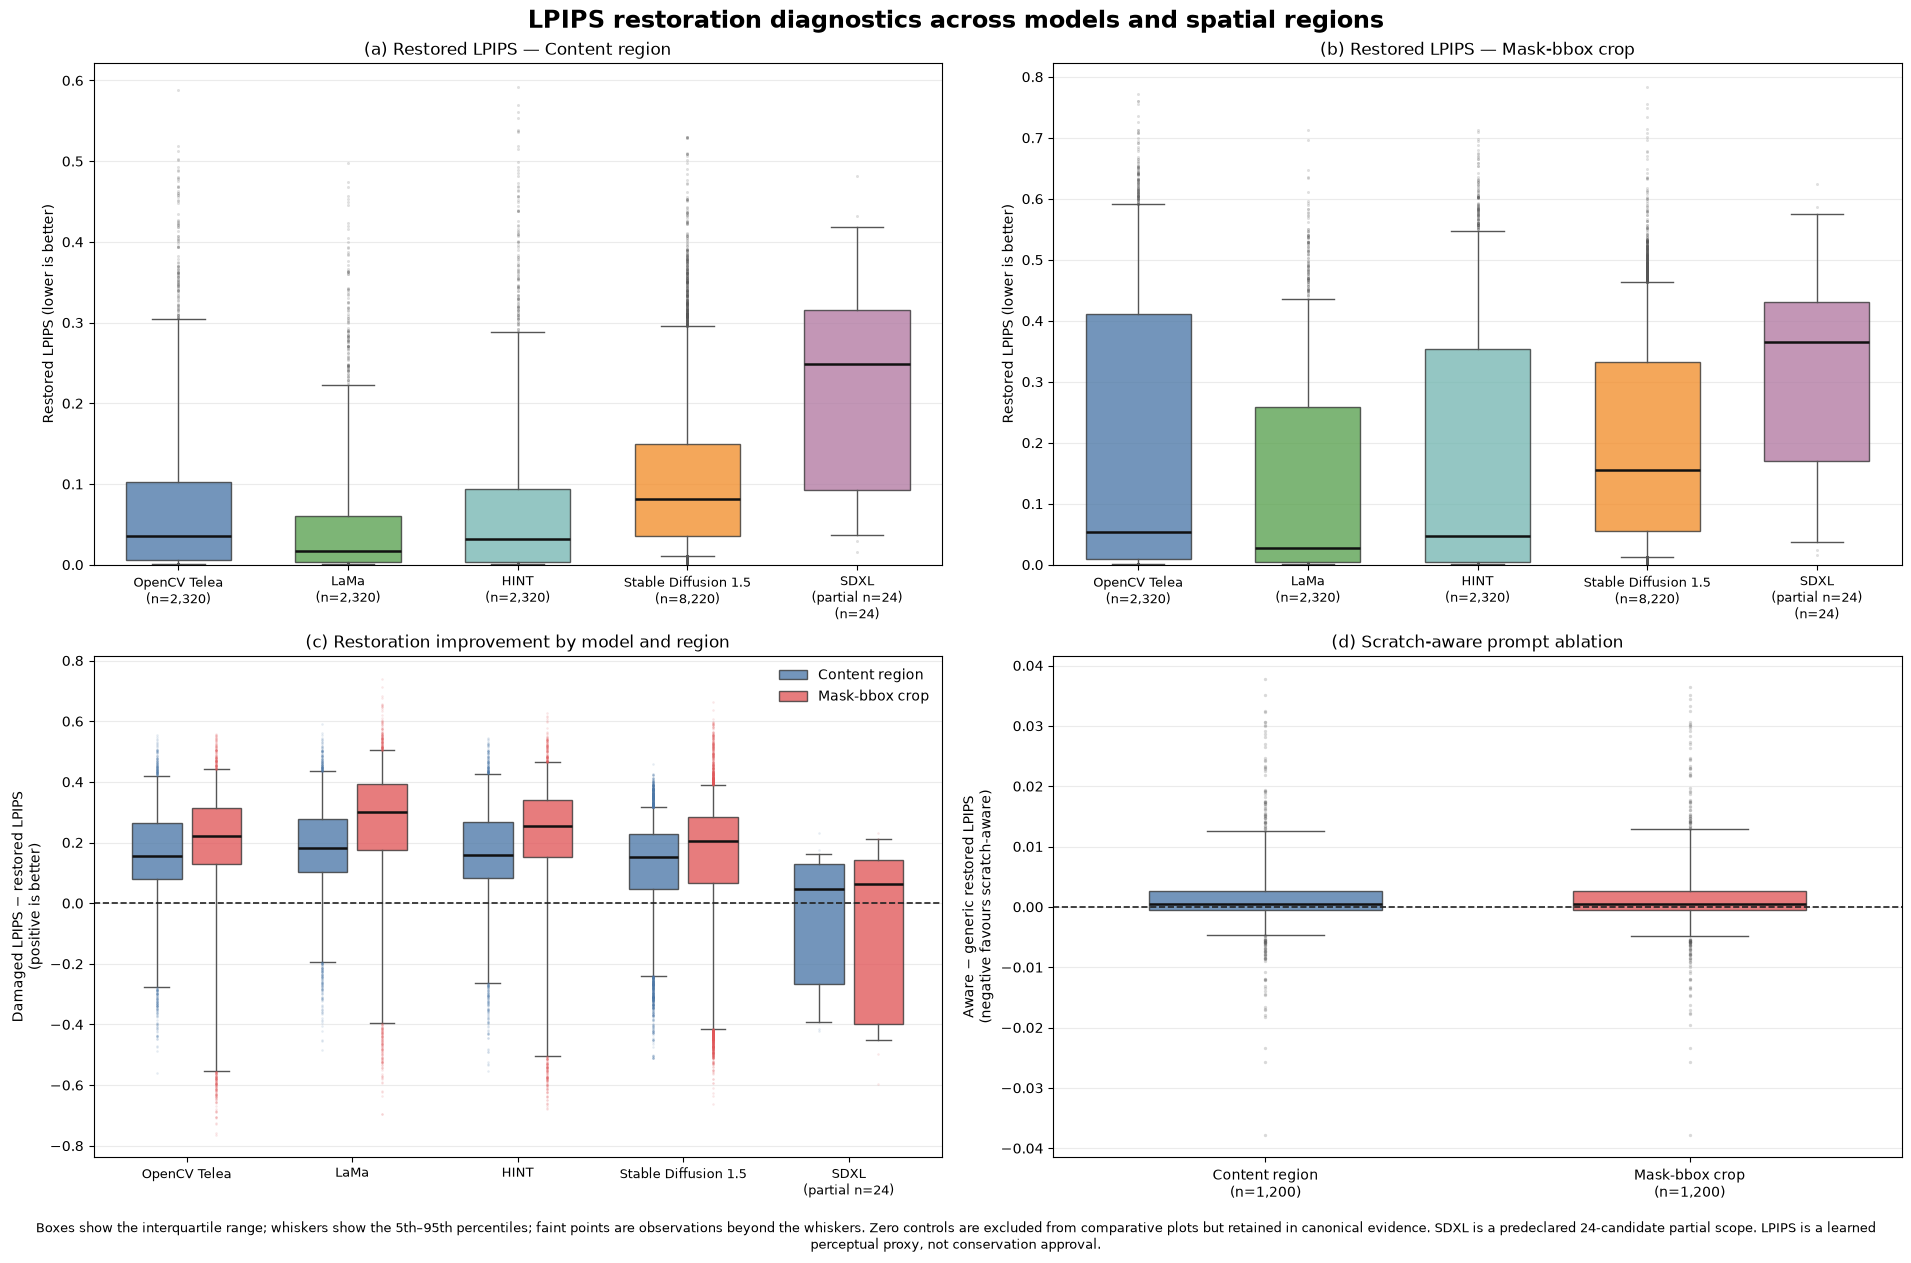

,figure_id,relative_path,format,mode,width,height,size_bytes,pixel_standard_deviation,nonblank,sha256
0,lpips_distributions,outputs/14_lpips_metrics/figures/lpips_distrib...,PNG,RGBA,3440,2268,404064,44.276662,True,a02dbe521bdd13dd5958c4317798c44e350ae543a1d2eb...


Canonical LPIPS diagnostic figure generated.
Figure path: outputs/14_lpips_metrics/figures/lpips_distributions.png
Figure dimensions: (3440, 2268)
Figure bytes: 404064
Figure SHA-256: a02dbe521bdd13dd5958c4317798c44e350ae543a1d2eb390ecd39e2460f8b57


In [23]:
import matplotlib.pyplot as plt

from matplotlib.patches import Patch
from PIL import Image


# ---------------------------------------------------------------------------
# Plotting helpers
# ---------------------------------------------------------------------------

def lpips_values(
    model_id,
    region_id,
    value_column,
):
    return (
        lpips_plot_df.loc[
            lpips_plot_df[
                "model_id"
            ].eq(model_id)
            & lpips_plot_df[
                "region_id"
            ].eq(region_id),
            value_column,
        ]
        .astype(float)
        .to_numpy()
    )


def style_boxplot(
    boxplot,
    colors,
):
    for box, color in zip(
        boxplot["boxes"],
        colors,
    ):
        box.set_facecolor(color)
        box.set_edgecolor("#333333")
        box.set_alpha(0.78)

    for median in boxplot["medians"]:
        median.set_color("#111111")
        median.set_linewidth(1.8)

    for whisker in boxplot["whiskers"]:
        whisker.set_color("#555555")

    for cap in boxplot["caps"]:
        cap.set_color("#555555")


# ---------------------------------------------------------------------------
# Four-panel canonical distribution figure
# ---------------------------------------------------------------------------

figure, axes = plt.subplots(
    2,
    2,
    figsize=(19, 12),
    constrained_layout=True,
)

content_axis = axes[0, 0]
bbox_axis = axes[0, 1]
improvement_axis = axes[1, 0]
scratch_axis = axes[1, 1]


# ---------------------------------------------------------------------------
# Panels A and B: restored LPIPS by model
# ---------------------------------------------------------------------------

for axis, region_id, panel_label in (
    (
        content_axis,
        "content_region",
        "(a)",
    ),
    (
        bbox_axis,
        "mask_bbox_crop",
        "(b)",
    ),
):
    model_values = [
        lpips_values(
            model_id,
            region_id,
            "restored_value",
        )
        for model_id in MODEL_ORDER
    ]

    tick_labels = [
        (
            MODEL_LABELS[model_id]
            + "\n"
            + f"(n={len(values):,})"
        )
        for model_id, values in zip(
            MODEL_ORDER,
            model_values,
        )
    ]

    model_boxplot = axis.boxplot(
        model_values,
        tick_labels=tick_labels,
        patch_artist=True,
        widths=0.62,
        whis=(5, 95),
        showfliers=True,
        flierprops={
            "marker": "o",
            "markersize": 2.2,
            "markerfacecolor": "#555555",
            "markeredgecolor": "none",
            "alpha": 0.18,
        },
    )

    style_boxplot(
        model_boxplot,
        [
            MODEL_COLORS[model_id]
            for model_id in MODEL_ORDER
        ],
    )

    axis.set_title(
        f"{panel_label} Restored LPIPS — "
        f"{REGION_LABELS[region_id]}"
    )
    axis.set_ylabel(
        "Restored LPIPS (lower is better)"
    )
    axis.set_ylim(bottom=0)
    axis.grid(
        axis="y",
        alpha=0.25,
    )
    axis.tick_params(
        axis="x",
        labelsize=9,
    )


# ---------------------------------------------------------------------------
# Panel C: improvement distributions by region
# ---------------------------------------------------------------------------

model_positions = np.arange(
    len(MODEL_ORDER),
    dtype=float,
)

region_offsets = {
    "content_region": -0.18,
    "mask_bbox_crop": 0.18,
}

for region_id in REGION_ORDER:
    region_improvements = [
        lpips_values(
            model_id,
            region_id,
            "improvement_value",
        )
        for model_id in MODEL_ORDER
    ]

    region_boxplot = improvement_axis.boxplot(
        region_improvements,
        positions=(
            model_positions
            + region_offsets[region_id]
        ),
        widths=0.30,
        patch_artist=True,
        manage_ticks=False,
        whis=(5, 95),
        showfliers=True,
        flierprops={
            "marker": "o",
            "markersize": 1.8,
            "markerfacecolor": (
                REGION_COLORS[region_id]
            ),
            "markeredgecolor": "none",
            "alpha": 0.14,
        },
    )

    style_boxplot(
        region_boxplot,
        [
            REGION_COLORS[region_id]
            for _ in MODEL_ORDER
        ],
    )

improvement_axis.axhline(
    0.0,
    color="#222222",
    linewidth=1.2,
    linestyle="--",
)

improvement_axis.set_xticks(
    model_positions
)

improvement_axis.set_xticklabels(
    [
        MODEL_LABELS[model_id]
        for model_id in MODEL_ORDER
    ],
    fontsize=9,
)

improvement_axis.set_title(
    "(c) Restoration improvement by model and region"
)

improvement_axis.set_ylabel(
    "Damaged LPIPS − restored LPIPS\n"
    "(positive is better)"
)

improvement_axis.grid(
    axis="y",
    alpha=0.25,
)

improvement_axis.legend(
    handles=[
        Patch(
            facecolor=REGION_COLORS[region_id],
            edgecolor="#333333",
            alpha=0.78,
            label=REGION_LABELS[region_id],
        )
        for region_id in REGION_ORDER
    ],
    loc="best",
    frameon=False,
)


# ---------------------------------------------------------------------------
# Panel D: paired scratch-aware prompt deltas
# ---------------------------------------------------------------------------

scratch_delta_values = [
    (
        scratch_delta_plot_df.loc[
            scratch_delta_plot_df[
                "region_id"
            ].eq(region_id),
            "restored_lpips_delta_aware_minus_generic",
        ]
        .astype(float)
        .to_numpy()
    )
    for region_id in REGION_ORDER
]

scratch_tick_labels = [
    (
        REGION_LABELS[region_id]
        + "\n"
        + f"(n={len(values):,})"
    )
    for region_id, values in zip(
        REGION_ORDER,
        scratch_delta_values,
    )
]

scratch_boxplot = scratch_axis.boxplot(
    scratch_delta_values,
    tick_labels=scratch_tick_labels,
    patch_artist=True,
    widths=0.55,
    whis=(5, 95),
    showfliers=True,
    flierprops={
        "marker": "o",
        "markersize": 2.4,
        "markerfacecolor": "#555555",
        "markeredgecolor": "none",
        "alpha": 0.22,
    },
)

style_boxplot(
    scratch_boxplot,
    [
        REGION_COLORS[region_id]
        for region_id in REGION_ORDER
    ],
)

scratch_axis.axhline(
    0.0,
    color="#222222",
    linewidth=1.2,
    linestyle="--",
)

scratch_axis.set_title(
    "(d) Scratch-aware prompt ablation"
)

scratch_axis.set_ylabel(
    "Aware − generic restored LPIPS\n"
    "(negative favours scratch-aware)"
)

scratch_axis.grid(
    axis="y",
    alpha=0.25,
)


# ---------------------------------------------------------------------------
# Figure-level title and methodological note
# ---------------------------------------------------------------------------

figure.suptitle(
    "LPIPS restoration diagnostics across models and spatial regions",
    fontsize=17,
    fontweight="bold",
)

figure.text(
    0.5,
    -0.012,
    (
        "Boxes show the interquartile range; whiskers show the "
        "5th–95th percentiles; faint points are observations beyond "
        "the whiskers. Zero controls are excluded from comparative "
        "plots but retained in canonical evidence. SDXL is a "
        "predeclared 24-candidate partial scope. LPIPS is a learned "
        "perceptual proxy, not conservation approval."
    ),
    ha="center",
    va="top",
    fontsize=9,
    wrap=True,
)


# ---------------------------------------------------------------------------
# Canonical figure persistence
# ---------------------------------------------------------------------------

OUTPUTS[
    "lpips_distributions"
].parent.mkdir(
    parents=True,
    exist_ok=True,
)

figure.savefig(
    OUTPUTS[
        "lpips_distributions"
    ],
    dpi=180,
    bbox_inches="tight",
    facecolor="white",
)

plt.show()
plt.close(figure)


# ---------------------------------------------------------------------------
# Saved-figure inspection
# ---------------------------------------------------------------------------

with Image.open(
    OUTPUTS[
        "lpips_distributions"
    ]
) as saved_figure:
    saved_format = saved_figure.format
    saved_width, saved_height = (
        saved_figure.size
    )
    saved_mode = saved_figure.mode

    saved_rgb = np.asarray(
        saved_figure.convert("RGB"),
        dtype=np.uint8,
    )

figure_audit_df = pd.DataFrame(
    [
        {
            "figure_id": (
                "lpips_distributions"
            ),
            "relative_path": to_repo_relative(
                OUTPUTS[
                    "lpips_distributions"
                ],
                PROJECT_ROOT,
            ),
            "format": saved_format,
            "mode": saved_mode,
            "width": int(saved_width),
            "height": int(saved_height),
            "size_bytes": int(
                OUTPUTS[
                    "lpips_distributions"
                ].stat().st_size
            ),
            "pixel_standard_deviation": float(
                saved_rgb.std()
            ),
            "nonblank": bool(
                saved_rgb.std() > 1.0
            ),
            "sha256": sha256_file(
                OUTPUTS[
                    "lpips_distributions"
                ]
            ),
        }
    ]
)

display(figure_audit_df)

print("Canonical LPIPS diagnostic figure generated.")
print(
    "Figure path:",
    to_repo_relative(
        OUTPUTS[
            "lpips_distributions"
        ],
        PROJECT_ROOT,
    ),
)
print(
    "Figure dimensions:",
    (
        saved_width,
        saved_height,
    ),
)
print(
    "Figure bytes:",
    OUTPUTS[
        "lpips_distributions"
    ].stat().st_size,
)
print(
    "Figure SHA-256:",
    figure_audit_df.loc[
        0,
        "sha256",
    ],
)

In [24]:
# ---------------------------------------------------------------------------
# Batch 6 analysis and visualization validation
# ---------------------------------------------------------------------------

preserved_checks = tuple(
    check
    for check in VALIDATION.checks
    if (
        check.validation_stage
        != "batch_6_analysis_visualization"
    )
)

VALIDATION = ValidationCollector()
VALIDATION.extend(preserved_checks)


def add_batch_6_check(
    check_id,
    description,
    expected,
    observed,
    passed,
    details="",
    severity="blocking",
):
    VALIDATION.add(
        validation_stage=(
            "batch_6_analysis_visualization"
        ),
        check_id=check_id,
        check_description=description,
        severity=severity,
        expected=expected,
        observed=observed,
        passed=bool(passed),
        details=details,
    )


# ---------------------------------------------------------------------------
# Exact comparative plotting population
# ---------------------------------------------------------------------------

expected_plot_metric_rows = int(
    EXPECTED_COUNTS[
        "total_metric_rows"
    ]
    - EXPECTED_COUNTS[
        "zero_control_candidates"
    ]
)

expected_plot_candidates = int(
    EXPECTED_COUNTS[
        "evaluated_candidates"
    ]
    - EXPECTED_COUNTS[
        "zero_control_candidates"
    ]
)

expected_plot_metric_ids = set(
    lpips_analysis_df.loc[
        ~lpips_analysis_df[
            "is_zero_control"
        ].fillna(False).astype(bool),
        "metric_row_id",
    ].astype(str)
)

observed_plot_metric_ids = set(
    lpips_plot_df[
        "metric_row_id"
    ].astype(str)
)

plot_metric_id_difference = {
    "missing": sorted(
        expected_plot_metric_ids
        - observed_plot_metric_ids
    ),
    "extra": sorted(
        observed_plot_metric_ids
        - expected_plot_metric_ids
    ),
}

add_batch_6_check(
    "comparative_plot_exact_subset",
    "Comparative plotting evidence is exactly the non-zero-control metric subset.",
    {
        "missing": [],
        "extra": [],
    },
    {
        "missing": (
            plot_metric_id_difference[
                "missing"
            ][:10]
        ),
        "extra": (
            plot_metric_id_difference[
                "extra"
            ][:10]
        ),
    },
    (
        not plot_metric_id_difference[
            "missing"
        ]
        and not plot_metric_id_difference[
            "extra"
        ]
    ),
)

add_batch_6_check(
    "comparative_plot_metric_rows",
    "The plotting population contains every non-zero-control metric row.",
    expected_plot_metric_rows,
    len(lpips_plot_df),
    (
        len(lpips_plot_df)
        == expected_plot_metric_rows
    ),
)

add_batch_6_check(
    "comparative_plot_candidates",
    "The plotting population contains every non-zero-control candidate.",
    expected_plot_candidates,
    int(
        lpips_plot_df[
            "candidate_id"
        ].nunique()
    ),
    (
        lpips_plot_df[
            "candidate_id"
        ].nunique()
        == expected_plot_candidates
    ),
)

zero_controls_in_plot_count = int(
    lpips_plot_df[
        "is_zero_control"
    ].fillna(False).astype(bool).sum()
)

add_batch_6_check(
    "zero_controls_excluded_from_comparative_plot",
    "Exact identity controls are excluded only from comparative visualization.",
    0,
    zero_controls_in_plot_count,
    zero_controls_in_plot_count == 0,
)


# ---------------------------------------------------------------------------
# Model and region coverage
# ---------------------------------------------------------------------------

expected_plot_rows_by_model_region = {
    "opencv_telea|content_region": 2320,
    "opencv_telea|mask_bbox_crop": 2320,
    "lama|content_region": 2320,
    "lama|mask_bbox_crop": 2320,
    "hint_places2|content_region": 2320,
    "hint_places2|mask_bbox_crop": 2320,
    (
        "stable_diffusion_inpainting"
        "|content_region"
    ): 8220,
    (
        "stable_diffusion_inpainting"
        "|mask_bbox_crop"
    ): 8220,
    "sdxl_inpainting|content_region": 24,
    "sdxl_inpainting|mask_bbox_crop": 24,
}

observed_plot_rows_by_model_region = {
    f"{model_id}|{region_id}": int(row_count)
    for (
        model_id,
        region_id,
    ), row_count in (
        lpips_plot_df
        .groupby(
            [
                "model_id",
                "region_id",
            ]
        )
        .size()
        .items()
    )
}

add_batch_6_check(
    "plot_model_region_cardinality",
    (
        "Every model-region plotting group has "
        "its exact expected row count."
    ),
    expected_plot_rows_by_model_region,
    observed_plot_rows_by_model_region,
    (
        observed_plot_rows_by_model_region
        == expected_plot_rows_by_model_region
    ),
)

expected_plot_summary_rows = (
    len(MODEL_ORDER)
    * len(REGION_ORDER)
)

add_batch_6_check(
    "plot_summary_rows",
    (
        "The model-region summary contains all ten "
        "model-region combinations."
    ),
    expected_plot_summary_rows,
    len(plot_model_region_summary_df),
    (
        len(plot_model_region_summary_df)
        == expected_plot_summary_rows
    ),
)

observed_plot_models = set(
    lpips_plot_df[
        "model_id"
    ].astype(str)
)

observed_plot_regions = set(
    lpips_plot_df[
        "region_id"
    ].astype(str)
)

add_batch_6_check(
    "plot_model_coverage",
    (
        "The canonical figure contains all five "
        "restoration models."
    ),
    set(MODEL_ORDER),
    observed_plot_models,
    observed_plot_models == set(MODEL_ORDER),
)

add_batch_6_check(
    "plot_region_coverage",
    "The canonical figure contains both approved LPIPS regions.",
    set(REGION_ORDER),
    observed_plot_regions,
    observed_plot_regions == set(REGION_ORDER),
)

expected_sdxl_metric_rows = int(
    EXPECTED_COUNTS[
        "metric_rows_by_model"
    ]["sdxl_inpainting"]
)

observed_sdxl_metric_rows = int(
    lpips_plot_df[
        "model_id"
    ].eq(
        "sdxl_inpainting"
    ).sum()
)

add_batch_6_check(
    "sdxl_partial_scope_visible",
    (
        "The plotting evidence retains the complete "
        "48-row SDXL partial scope."
    ),
    expected_sdxl_metric_rows,
    observed_sdxl_metric_rows,
    (
        observed_sdxl_metric_rows
        == expected_sdxl_metric_rows
    ),
)


# ---------------------------------------------------------------------------
# Scratch-prompt diagnostic integrity
# ---------------------------------------------------------------------------

scratch_delta_finite_count = int(
    np.isfinite(
        scratch_delta_plot_df[
            "restored_lpips_delta_aware_minus_generic"
        ].to_numpy(dtype=float)
    ).sum()
)

add_batch_6_check(
    "scratch_prompt_plot_pairs",
    (
        "The prompt-ablation panel contains all 2,400 "
        "matched case-seed-region pairs."
    ),
    EXPECTED_SCRATCH_PROMPT_REGIONAL_ROWS,
    len(scratch_delta_plot_df),
    (
        len(scratch_delta_plot_df)
        == EXPECTED_SCRATCH_PROMPT_REGIONAL_ROWS
    ),
)

add_batch_6_check(
    "scratch_prompt_plot_values_finite",
    "Every plotted paired prompt delta is finite.",
    EXPECTED_SCRATCH_PROMPT_REGIONAL_ROWS,
    scratch_delta_finite_count,
    (
        scratch_delta_finite_count
        == EXPECTED_SCRATCH_PROMPT_REGIONAL_ROWS
    ),
)

add_batch_6_check(
    "scratch_prompt_plot_descriptive",
    (
        "Scratch-prompt direction remains descriptive "
        "and does not filter candidates."
    ),
    "all matched pairs retained",
    {
        "matched_pairs": len(
            scratch_delta_plot_df
        ),
        "content_median_delta": float(
            scratch_delta_plot_summary_df.loc[
                scratch_delta_plot_summary_df[
                    "region_id"
                ].eq("content_region"),
                "median_aware_minus_generic",
            ].iloc[0]
        ),
        "bbox_median_delta": float(
            scratch_delta_plot_summary_df.loc[
                scratch_delta_plot_summary_df[
                    "region_id"
                ].eq("mask_bbox_crop"),
                "median_aware_minus_generic",
            ].iloc[0]
        ),
    },
    (
        len(scratch_delta_plot_df)
        == EXPECTED_SCRATCH_PROMPT_REGIONAL_ROWS
    ),
    severity="info",
)


# ---------------------------------------------------------------------------
# Saved-figure integrity
# ---------------------------------------------------------------------------

figure_record = figure_audit_df.iloc[0]

add_batch_6_check(
    "lpips_figure_exists",
    "The canonical LPIPS distribution figure exists.",
    True,
    OUTPUTS[
        "lpips_distributions"
    ].is_file(),
    OUTPUTS[
        "lpips_distributions"
    ].is_file(),
)

add_batch_6_check(
    "lpips_figure_format",
    "The canonical LPIPS figure is a valid PNG image.",
    "PNG",
    figure_record["format"],
    figure_record["format"] == "PNG",
)

figure_dimensions_valid = bool(
    int(figure_record["width"]) >= 2000
    and int(figure_record["height"]) >= 1400
)

add_batch_6_check(
    "lpips_figure_dimensions",
    "The canonical LPIPS figure has publication-usable dimensions.",
    {
        "minimum_width": 2000,
        "minimum_height": 1400,
    },
    {
        "width": int(
            figure_record["width"]
        ),
        "height": int(
            figure_record["height"]
        ),
    },
    figure_dimensions_valid,
)

add_batch_6_check(
    "lpips_figure_nonblank",
    "The canonical LPIPS figure contains nonblank visual content.",
    True,
    bool(figure_record["nonblank"]),
    bool(figure_record["nonblank"]),
    details={
        "pixel_standard_deviation": float(
            figure_record[
                "pixel_standard_deviation"
            ]
        )
    },
)

figure_checksum_valid = bool(
    len(
        str(
            figure_record[
                "sha256"
            ]
        )
    )
    == 64
)

add_batch_6_check(
    "lpips_figure_checksum",
    "The canonical LPIPS figure has a complete SHA-256 checksum.",
    64,
    len(
        str(
            figure_record[
                "sha256"
            ]
        )
    ),
    figure_checksum_valid,
)


# ---------------------------------------------------------------------------
# Notebook-owned persistence boundary
# ---------------------------------------------------------------------------

work_directory = (
    WORK_PATHS[
        "checkpoint"
    ].parent.resolve()
)

files_outside_work = {
    to_repo_relative(
        path,
        PROJECT_ROOT,
    )
    for path in (
        NOTEBOOK_OUTPUT_ROOT.rglob("*")
    )
    if (
        path.is_file()
        and work_directory
        not in path.resolve().parents
    )
}

expected_files_outside_work = {
    to_repo_relative(
        OUTPUTS[
            "lpips_distributions"
        ],
        PROJECT_ROOT,
    )
}

add_batch_6_check(
    "batch_6_persistence_scope",
    "Batch 6 creates only the canonical figure outside notebook-owned temporary work.",
    expected_files_outside_work,
    files_outside_work,
    (
        files_outside_work
        == expected_files_outside_work
    ),
)

premature_canonical_outputs = {
    output_key: to_repo_relative(
        OUTPUTS[output_key],
        PROJECT_ROOT,
    )
    for output_key in (
        "lpips_metrics",
        "run_manifest",
        "artifacts",
        "validation",
    )
    if OUTPUTS[output_key].exists()
}

add_batch_6_check(
    "remaining_canonical_outputs_deferred",
    "Metrics, manifests, and consolidated validation remain unwritten.",
    {},
    premature_canonical_outputs,
    not premature_canonical_outputs,
)


# ---------------------------------------------------------------------------
# Consolidated validation view
# ---------------------------------------------------------------------------

all_validation_df = (
    VALIDATION.to_dataframe()
)

batch_6_validation_df = (
    all_validation_df.loc[
        all_validation_df[
            "validation_stage"
        ].eq(
            "batch_6_analysis_visualization"
        )
    ]
    .reset_index(drop=True)
)

display(batch_6_validation_df)

VALIDATION.raise_for_blocking()

print("Batch 6 LPIPS analysis and visualization passed.")
print(
    "Batch 6 validation checks:",
    len(batch_6_validation_df),
)
print(
    "Blocking failures across Batches 1-6:",
    len(VALIDATION.blocking_failures),
)
print(
    "Canonical figure:",
    to_repo_relative(
        OUTPUTS[
            "lpips_distributions"
        ],
        PROJECT_ROOT,
    ),
)
print(
    "Canonical figure bytes:",
    int(
        figure_record[
            "size_bytes"
        ]
    ),
)
print(
    "Scratch-aware better fraction by region:",
    {
        str(row.region_id): float(
            row.scratch_aware_better_fraction
        )
        for row in (
            scratch_delta_plot_summary_df
            .itertuples(index=False)
        )
    },
)
print(
    "Canonical metric and handoff files remain deferred."
)

,validation_stage,check_id,check_description,severity,expected,observed,passed,details
0,batch_6_analysis_visualization,comparative_plot_exact_subset,Comparative plotting evidence is exactly the n...,blocking,"{""extra"": [], ""missing"": []}","{""extra"": [], ""missing"": []}",True,
1,batch_6_analysis_visualization,comparative_plot_metric_rows,The plotting population contains every non-zer...,blocking,30408,30408,True,
2,batch_6_analysis_visualization,comparative_plot_candidates,The plotting population contains every non-zer...,blocking,15204,15204,True,
3,batch_6_analysis_visualization,zero_controls_excluded_from_comparative_plot,Exact identity controls are excluded only from...,blocking,0,0,True,
4,batch_6_analysis_visualization,plot_model_region_cardinality,Every model-region plotting group has its exac...,blocking,"{""hint_places2|content_region"": 2320, ""hint_pl...","{""hint_places2|content_region"": 2320, ""hint_pl...",True,
5,batch_6_analysis_visualization,plot_summary_rows,The model-region summary contains all ten mode...,blocking,10,10,True,
6,batch_6_analysis_visualization,plot_model_coverage,The canonical figure contains all five restora...,blocking,"""{'lama', 'opencv_telea', 'hint_places2', 'sdx...","""{'lama', 'opencv_telea', 'hint_places2', 'sdx...",True,
7,batch_6_analysis_visualization,plot_region_coverage,The canonical figure contains both approved LP...,blocking,"""{'mask_bbox_crop', 'content_region'}""","""{'mask_bbox_crop', 'content_region'}""",True,
8,batch_6_analysis_visualization,sdxl_partial_scope_visible,The plotting evidence retains the complete 48-...,blocking,48,48,True,
9,batch_6_analysis_visualization,scratch_prompt_plot_pairs,"The prompt-ablation panel contains all 2,400 m...",blocking,2400,2400,True,


Batch 6 LPIPS analysis and visualization passed.
Batch 6 validation checks: 19
Blocking failures across Batches 1-6: 0
Canonical figure: outputs/14_lpips_metrics/figures/lpips_distributions.png
Canonical figure bytes: 404064
Scratch-aware better fraction by region: {'content_region': 0.3491666666666667, 'mask_bbox_crop': 0.35583333333333333}
Canonical metric and handoff files remain deferred.


## Batch 7 — Canonical LPIPS metric persistence

This batch atomically persists the scientifically validated 31,608-row LPIPS table and reloads it from disk.

The canonical reload must preserve:

- the exact `lpips_metrics.v1` column order and schema;
- all deterministic metric-row identifiers;
- candidate, model, region, transform, network, device, package, and version provenance;
- every finite LPIPS distance and signed improvement;
- all 16,404 candidates across Telea, LaMa, HINT, Stable Diffusion, and the bounded SDXL evidence;
- numerical values within strict round-trip tolerance.

The validated distribution figure remains unchanged. Universal manifests, consolidated validation persistence, project-path registry updates, and temporary-work cleanup remain deferred to the final handoff batch.

In [25]:
import os
import time

from uuid import uuid4

from restoration_eval.schemas import (
    LPIPS_METRICS_COLUMNS,
)


# ---------------------------------------------------------------------------
# Windows-safe canonical CSV persistence
# ---------------------------------------------------------------------------

CANONICAL_WRITE_ATTEMPTS = 8
CANONICAL_INITIAL_RETRY_SECONDS = 0.125


def write_canonical_dataframe_atomic(
    dataframe,
    destination,
):
    destination = Path(destination)

    destination.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    retry_seconds = (
        CANONICAL_INITIAL_RETRY_SECONDS
    )

    last_error = None

    for attempt_number in range(
        1,
        CANONICAL_WRITE_ATTEMPTS + 1,
    ):
        temporary_path = (
            destination.parent
            / (
                destination.name
                + "."
                + uuid4().hex
                + ".tmp"
            )
        )

        try:
            dataframe.to_csv(
                temporary_path,
                index=False,
                lineterminator="\n",
            )

            os.replace(
                temporary_path,
                destination,
            )

            return {
                "path": destination,
                "attempts": attempt_number,
                "temporary_path": temporary_path,
            }

        except PermissionError as exc:
            last_error = exc

            try:
                temporary_path.unlink(
                    missing_ok=True
                )
            except OSError:
                pass

            if (
                attempt_number
                < CANONICAL_WRITE_ATTEMPTS
            ):
                time.sleep(
                    retry_seconds
                )

                retry_seconds = min(
                    retry_seconds * 2,
                    2.0,
                )

        except Exception:
            try:
                temporary_path.unlink(
                    missing_ok=True
                )
            except OSError:
                pass

            raise

    raise PermissionError(
        "Could not atomically persist the canonical "
        f"LPIPS table after {CANONICAL_WRITE_ATTEMPTS} "
        f"attempts: {last_error}"
    )


# ---------------------------------------------------------------------------
# Exact canonical table
# ---------------------------------------------------------------------------

canonical_lpips_source_df = (
    full_metrics_df.loc[
        :,
        LPIPS_METRICS_COLUMNS,
    ]
    .copy()
)

canonical_write_result = (
    write_canonical_dataframe_atomic(
        canonical_lpips_source_df,
        OUTPUTS["lpips_metrics"],
    )
)

canonical_lpips_reloaded_df = pd.read_csv(
    OUTPUTS["lpips_metrics"],
    low_memory=False,
)


print("Canonical LPIPS metric table persisted and reloaded.")
print(
    "Canonical path:",
    to_repo_relative(
        OUTPUTS["lpips_metrics"],
        PROJECT_ROOT,
    ),
)
print(
    "Atomic write attempts:",
    canonical_write_result[
        "attempts"
    ],
)
print(
    "Persisted bytes:",
    OUTPUTS[
        "lpips_metrics"
    ].stat().st_size,
)
print(
    "Source rows:",
    len(canonical_lpips_source_df),
)
print(
    "Reloaded rows:",
    len(canonical_lpips_reloaded_df),
)
print(
    "Reloaded columns:",
    len(canonical_lpips_reloaded_df.columns),
)

Canonical LPIPS metric table persisted and reloaded.
Canonical path: outputs/14_lpips_metrics/metrics/lpips_metrics.csv
Atomic write attempts: 1
Persisted bytes: 13939180
Source rows: 31608
Reloaded rows: 31608
Reloaded columns: 26


In [26]:
# ---------------------------------------------------------------------------
# Canonical schema and scientific validation
# ---------------------------------------------------------------------------

canonical_lpips_schema = (
    validate_dataframe(
        canonical_lpips_reloaded_df,
        LPIPS_METRICS_SCHEMA,
        allow_extra_columns=False,
    )
)

canonical_lpips_validation = (
    validate_lpips_metrics(
        canonical_lpips_reloaded_df,
        evaluation_worklist_df,
        project_root=PROJECT_ROOT,
        config=lpips_config,
        expected_plan=(
            lpips_execution_plan_df
        ),
    )
)


# ---------------------------------------------------------------------------
# Order-independent table comparison
# ---------------------------------------------------------------------------

source_lpips_sorted_df = (
    canonical_lpips_source_df
    .sort_values(
        "metric_row_id",
        kind="stable",
    )
    .reset_index(drop=True)
)

reloaded_lpips_sorted_df = (
    canonical_lpips_reloaded_df
    .sort_values(
        "metric_row_id",
        kind="stable",
    )
    .reset_index(drop=True)
)

canonical_identifier_match = bool(
    source_lpips_sorted_df[
        "metric_row_id"
    ].astype(str).equals(
        reloaded_lpips_sorted_df[
            "metric_row_id"
        ].astype(str)
    )
)


# ---------------------------------------------------------------------------
# Numerical round-trip
# ---------------------------------------------------------------------------

LPIPS_NUMERIC_COLUMNS = [
    "region_pixel_count",
    "region_width",
    "region_height",
    "input_width",
    "input_height",
    "damaged_value",
    "restored_value",
    "improvement_value",
    "metric_runtime_seconds",
]

source_numeric_values = (
    source_lpips_sorted_df[
        LPIPS_NUMERIC_COLUMNS
    ].to_numpy(dtype=float)
)

reloaded_numeric_values = (
    reloaded_lpips_sorted_df[
        LPIPS_NUMERIC_COLUMNS
    ].to_numpy(dtype=float)
)

canonical_numeric_match = bool(
    np.allclose(
        source_numeric_values,
        reloaded_numeric_values,
        rtol=1e-12,
        atol=1e-12,
        equal_nan=True,
    )
)

canonical_numeric_maximum_difference = float(
    np.abs(
        source_numeric_values
        - reloaded_numeric_values
    ).max()
)


# ---------------------------------------------------------------------------
# Categorical and issue-field round-trip
# ---------------------------------------------------------------------------

LPIPS_CATEGORICAL_COLUMNS = [
    column
    for column in LPIPS_METRICS_COLUMNS
    if column
    not in {
        *LPIPS_NUMERIC_COLUMNS,
        "issue",
    }
]

canonical_categorical_match = all(
    source_lpips_sorted_df[
        column
    ]
    .fillna("")
    .astype(str)
    .equals(
        reloaded_lpips_sorted_df[
            column
        ]
        .fillna("")
        .astype(str)
    )
    for column in (
        LPIPS_CATEGORICAL_COLUMNS
    )
)

canonical_issue_match = bool(
    source_lpips_sorted_df[
        "issue"
    ]
    .fillna("")
    .astype(str)
    .equals(
        reloaded_lpips_sorted_df[
            "issue"
        ]
        .fillna("")
        .astype(str)
    )
)


# ---------------------------------------------------------------------------
# Numerical and candidate evidence
# ---------------------------------------------------------------------------

canonical_numeric_values = (
    canonical_lpips_reloaded_df[
        [
            "damaged_value",
            "restored_value",
            "improvement_value",
            "metric_runtime_seconds",
        ]
    ].to_numpy(dtype=float)
)

canonical_nonfinite_count = int(
    (
        ~np.isfinite(
            canonical_numeric_values
        )
    ).sum()
)

canonical_negative_improvement_count = int(
    canonical_lpips_reloaded_df[
        "improvement_value"
    ].lt(0).sum()
)

canonical_positive_improvement_count = int(
    canonical_lpips_reloaded_df[
        "improvement_value"
    ].gt(0).sum()
)

canonical_model_row_counts = {
    str(model_id): int(row_count)
    for model_id, row_count in (
        canonical_lpips_reloaded_df
        .groupby("model_id")
        .size()
        .items()
    )
}

canonical_region_row_counts = {
    str(region_id): int(row_count)
    for region_id, row_count in (
        canonical_lpips_reloaded_df
        .groupby("region_id")
        .size()
        .items()
    )
}


# ---------------------------------------------------------------------------
# Canonical file evidence
# ---------------------------------------------------------------------------

canonical_lpips_file_audit_df = pd.DataFrame(
    [
        {
            "artifact_key": (
                "lpips_metrics.metrics"
            ),
            "relative_path": (
                to_repo_relative(
                    OUTPUTS[
                        "lpips_metrics"
                    ],
                    PROJECT_ROOT,
                )
            ),
            "format": "csv",
            "schema_version": (
                LPIPS_METRICS_SCHEMA.version
            ),
            "row_count": int(
                len(
                    canonical_lpips_reloaded_df
                )
            ),
            "column_count": int(
                len(
                    canonical_lpips_reloaded_df.columns
                )
            ),
            "candidate_count": int(
                canonical_lpips_reloaded_df[
                    "candidate_id"
                ].nunique()
            ),
            "model_count": int(
                canonical_lpips_reloaded_df[
                    "model_id"
                ].nunique()
            ),
            "region_count": int(
                canonical_lpips_reloaded_df[
                    "region_id"
                ].nunique()
            ),
            "size_bytes": int(
                OUTPUTS[
                    "lpips_metrics"
                ].stat().st_size
            ),
            "sha256": sha256_file(
                OUTPUTS[
                    "lpips_metrics"
                ]
            ),
            "schema_passed": bool(
                canonical_lpips_schema.passed
            ),
            "scientific_validation_passed": bool(
                canonical_lpips_validation[
                    "passed"
                ]
            ),
        }
    ]
)

display(canonical_lpips_file_audit_df)

print("Canonical LPIPS round-trip inspection complete.")
print(
    "Schema passed:",
    canonical_lpips_schema.passed,
)
print(
    "Scientific validation passed:",
    canonical_lpips_validation[
        "passed"
    ],
)
print(
    "Identifiers preserved:",
    canonical_identifier_match,
)
print(
    "Numerical values preserved:",
    canonical_numeric_match,
)
print(
    "Maximum numerical difference:",
    canonical_numeric_maximum_difference,
)
print(
    "Categorical provenance preserved:",
    canonical_categorical_match,
)
print(
    "Issue field preserved:",
    canonical_issue_match,
)
print(
    "Nonfinite values:",
    canonical_nonfinite_count,
)
print(
    "Negative improvements retained:",
    canonical_negative_improvement_count,
)
print(
    "Positive improvements retained:",
    canonical_positive_improvement_count,
)
print(
    "Model row counts:",
    canonical_model_row_counts,
)
print(
    "Region row counts:",
    canonical_region_row_counts,
)

,artifact_key,relative_path,format,schema_version,row_count,column_count,candidate_count,model_count,region_count,size_bytes,sha256,schema_passed,scientific_validation_passed
0,lpips_metrics.metrics,outputs/14_lpips_metrics/metrics/lpips_metrics...,csv,lpips_metrics.v1,31608,26,16404,5,2,13939180,0d2b125a5045459db4d07648ac52af14faeb5c4ae91873...,True,True


Canonical LPIPS round-trip inspection complete.
Schema passed: True
Scientific validation passed: True
Identifiers preserved: True
Numerical values preserved: True
Maximum numerical difference: 1.1102230246251565e-16
Categorical provenance preserved: True
Issue field preserved: True
Nonfinite values: 0
Negative improvements retained: 5290
Positive improvements retained: 25118
Model row counts: {'hint_places2': 4940, 'lama': 4940, 'opencv_telea': 4940, 'sdxl_inpainting': 48, 'stable_diffusion_inpainting': 16740}
Region row counts: {'content_region': 16404, 'mask_bbox_crop': 15204}


In [27]:
# ---------------------------------------------------------------------------
# Batch 7 canonical persistence validation
# ---------------------------------------------------------------------------

preserved_checks = tuple(
    check
    for check in VALIDATION.checks
    if (
        check.validation_stage
        != "batch_7_canonical_persistence"
    )
)

VALIDATION = ValidationCollector()
VALIDATION.extend(preserved_checks)


def add_batch_7_check(
    check_id,
    description,
    expected,
    observed,
    passed,
    details="",
    severity="blocking",
):
    VALIDATION.add(
        validation_stage=(
            "batch_7_canonical_persistence"
        ),
        check_id=check_id,
        check_description=description,
        severity=severity,
        expected=expected,
        observed=observed,
        passed=bool(passed),
        details=details,
    )


# ---------------------------------------------------------------------------
# Canonical table integrity
# ---------------------------------------------------------------------------

add_batch_7_check(
    "canonical_lpips_exists",
    "The canonical LPIPS metric CSV exists.",
    True,
    OUTPUTS[
        "lpips_metrics"
    ].is_file(),
    OUTPUTS[
        "lpips_metrics"
    ].is_file(),
)

add_batch_7_check(
    "canonical_lpips_schema",
    "The canonical CSV satisfies lpips_metrics.v1 without extra columns.",
    True,
    canonical_lpips_schema.to_dict(),
    canonical_lpips_schema.passed,
)

add_batch_7_check(
    "canonical_lpips_scientific_validation",
    "The canonical CSV passes complete LPIPS structural and scientific validation.",
    True,
    canonical_lpips_validation,
    canonical_lpips_validation[
        "passed"
    ],
)

add_batch_7_check(
    "canonical_lpips_row_count",
    "The canonical CSV contains all 31608 rows.",
    EXPECTED_COUNTS[
        "total_metric_rows"
    ],
    len(canonical_lpips_reloaded_df),
    (
        len(canonical_lpips_reloaded_df)
        == EXPECTED_COUNTS[
            "total_metric_rows"
        ]
    ),
)

add_batch_7_check(
    "canonical_lpips_column_order",
    "The canonical CSV uses the exact versioned LPIPS column order.",
    list(LPIPS_METRICS_COLUMNS),
    list(
        canonical_lpips_reloaded_df.columns
    ),
    (
        list(
            canonical_lpips_reloaded_df.columns
        )
        == list(LPIPS_METRICS_COLUMNS)
    ),
)

add_batch_7_check(
    "canonical_lpips_candidate_count",
    "The canonical CSV retains all 16404 evaluated candidates.",
    EXPECTED_COUNTS[
        "evaluated_candidates"
    ],
    int(
        canonical_lpips_reloaded_df[
            "candidate_id"
        ].nunique()
    ),
    (
        canonical_lpips_reloaded_df[
            "candidate_id"
        ].nunique()
        == EXPECTED_COUNTS[
            "evaluated_candidates"
        ]
    ),
)

add_batch_7_check(
    "canonical_identifier_roundtrip",
    "Canonical persistence preserves every deterministic metric-row identifier.",
    True,
    canonical_identifier_match,
    canonical_identifier_match,
)

add_batch_7_check(
    "canonical_numeric_roundtrip",
    "Canonical persistence preserves all numerical values within strict tolerance.",
    True,
    {
        "matched": canonical_numeric_match,
        "maximum_absolute_difference": (
            canonical_numeric_maximum_difference
        ),
    },
    canonical_numeric_match,
)

add_batch_7_check(
    "canonical_categorical_roundtrip",
    "Canonical persistence preserves categorical and provenance fields.",
    True,
    canonical_categorical_match,
    canonical_categorical_match,
)

add_batch_7_check(
    "canonical_issue_roundtrip",
    "Canonical persistence preserves explicit issue values.",
    True,
    canonical_issue_match,
    canonical_issue_match,
)

add_batch_7_check(
    "canonical_finite_value_policy",
    "The canonical LPIPS evidence contains no nonfinite numerical values.",
    0,
    canonical_nonfinite_count,
    canonical_nonfinite_count == 0,
)

add_batch_7_check(
    "canonical_model_cardinality",
    "The canonical CSV preserves exact model-level LPIPS row counts.",
    EXPECTED_COUNTS[
        "metric_rows_by_model"
    ],
    canonical_model_row_counts,
    (
        canonical_model_row_counts
        == EXPECTED_COUNTS[
            "metric_rows_by_model"
        ]
    ),
)

add_batch_7_check(
    "canonical_region_cardinality",
    "The canonical CSV preserves exact region-level LPIPS row counts.",
    {
        "content_region": (
            EXPECTED_COUNTS[
                "content_region_rows"
            ]
        ),
        "mask_bbox_crop": (
            EXPECTED_COUNTS[
                "mask_bbox_crop_rows"
            ]
        ),
    },
    canonical_region_row_counts,
    (
        canonical_region_row_counts
        == {
            "content_region": (
                EXPECTED_COUNTS[
                    "content_region_rows"
                ]
            ),
            "mask_bbox_crop": (
                EXPECTED_COUNTS[
                    "mask_bbox_crop_rows"
                ]
            ),
        }
    ),
)

canonical_lpips_checksum = str(
    canonical_lpips_file_audit_df.iloc[
        0
    ]["sha256"]
)

add_batch_7_check(
    "canonical_lpips_checksum",
    "The canonical LPIPS metric CSV has a complete SHA-256 checksum.",
    64,
    len(canonical_lpips_checksum),
    len(canonical_lpips_checksum) == 64,
)

add_batch_7_check(
    "canonical_lpips_file_size",
    "The canonical LPIPS metric CSV is nonempty.",
    "greater than zero",
    int(
        OUTPUTS[
            "lpips_metrics"
        ].stat().st_size
    ),
    (
        OUTPUTS[
            "lpips_metrics"
        ].stat().st_size
        > 0
    ),
)


# ---------------------------------------------------------------------------
# Figure retention and output scope
# ---------------------------------------------------------------------------

current_figure_checksum = sha256_file(
    OUTPUTS[
        "lpips_distributions"
    ]
)

validated_figure_checksum = str(
    figure_audit_df.iloc[
        0
    ]["sha256"]
)

add_batch_7_check(
    "canonical_figure_retained",
    "The validated LPIPS diagnostic figure remains unchanged.",
    validated_figure_checksum,
    current_figure_checksum,
    (
        current_figure_checksum
        == validated_figure_checksum
    ),
)

work_directory = (
    WORK_PATHS[
        "checkpoint"
    ].parent.resolve()
)

allowed_files_outside_work = {
    OUTPUTS[
        "lpips_metrics"
    ].resolve(),
    OUTPUTS[
        "lpips_distributions"
    ].resolve(),
}

observed_files_outside_work = {
    path.resolve()
    for path in (
        NOTEBOOK_OUTPUT_ROOT.rglob("*")
    )
    if (
        path.is_file()
        and work_directory
        not in path.resolve().parents
    )
}

unexpected_files_outside_work = sorted(
    to_repo_relative(
        path,
        PROJECT_ROOT,
    )
    for path in (
        observed_files_outside_work
        - allowed_files_outside_work
    )
)

add_batch_7_check(
    "canonical_persistence_output_scope",
    "Batch 7 contains only approved metrics and figure files outside temporary work.",
    [],
    unexpected_files_outside_work,
    not unexpected_files_outside_work,
)

handoff_outputs_exist_early = {
    output_key: OUTPUTS[
        output_key
    ].exists()
    for output_key in (
        "run_manifest",
        "artifacts",
        "validation",
    )
}

add_batch_7_check(
    "handoff_outputs_deferred",
    "Universal manifests and consolidated validation remain deferred.",
    {
        "run_manifest": False,
        "artifacts": False,
        "validation": False,
    },
    handoff_outputs_exist_early,
    (
        handoff_outputs_exist_early
        == {
            "run_manifest": False,
            "artifacts": False,
            "validation": False,
        }
    ),
)

add_batch_7_check(
    "canonical_atomic_write",
    "The canonical metric table was written to its exact path.",
    to_repo_relative(
        OUTPUTS[
            "lpips_metrics"
        ],
        PROJECT_ROOT,
    ),
    to_repo_relative(
        canonical_write_result[
            "path"
        ],
        PROJECT_ROOT,
    ),
    (
        canonical_write_result[
            "path"
        ].resolve()
        == OUTPUTS[
            "lpips_metrics"
        ].resolve()
    ),
    details={
        "attempts": canonical_write_result[
            "attempts"
        ]
    },
)


# ---------------------------------------------------------------------------
# Batch gate
# ---------------------------------------------------------------------------

all_validation_df = (
    VALIDATION.to_dataframe()
)

batch_7_validation_df = (
    all_validation_df.loc[
        all_validation_df[
            "validation_stage"
        ].eq(
            "batch_7_canonical_persistence"
        )
    ]
    .reset_index(drop=True)
)

display(batch_7_validation_df)

VALIDATION.raise_for_blocking()

print("Batch 7 canonical LPIPS persistence passed.")
print(
    "Batch 7 validation checks:",
    len(batch_7_validation_df),
)
print(
    "Blocking failures across Batches 1-7:",
    len(VALIDATION.blocking_failures),
)
print(
    "Canonical LPIPS rows:",
    len(canonical_lpips_reloaded_df),
)
print(
    "Canonical LPIPS checksum:",
    canonical_lpips_checksum,
)
print(
    "Canonical figure checksum:",
    current_figure_checksum,
)
print(
    "Temporary checkpoint retained until final handoff."
)

,validation_stage,check_id,check_description,severity,expected,observed,passed,details
0,batch_7_canonical_persistence,canonical_lpips_exists,The canonical LPIPS metric CSV exists.,blocking,True,True,True,
1,batch_7_canonical_persistence,canonical_lpips_schema,The canonical CSV satisfies lpips_metrics.v1 w...,blocking,True,"{""column_count"": 26, ""duplicate_primary_key_ro...",True,
2,batch_7_canonical_persistence,canonical_lpips_scientific_validation,The canonical CSV passes complete LPIPS struct...,blocking,True,"{""error_row_count"": 0, ""expected_row_count"": 3...",True,
3,batch_7_canonical_persistence,canonical_lpips_row_count,The canonical CSV contains all 31608 rows.,blocking,31608,31608,True,
4,batch_7_canonical_persistence,canonical_lpips_column_order,The canonical CSV uses the exact versioned LPI...,blocking,"[""metric_row_id"", ""case_id"", ""candidate_id"", ""...","[""metric_row_id"", ""case_id"", ""candidate_id"", ""...",True,
5,batch_7_canonical_persistence,canonical_lpips_candidate_count,The canonical CSV retains all 16404 evaluated ...,blocking,16404,16404,True,
6,batch_7_canonical_persistence,canonical_identifier_roundtrip,Canonical persistence preserves every determin...,blocking,True,True,True,
7,batch_7_canonical_persistence,canonical_numeric_roundtrip,Canonical persistence preserves all numerical ...,blocking,True,"{""matched"": true, ""maximum_absolute_difference...",True,
8,batch_7_canonical_persistence,canonical_categorical_roundtrip,Canonical persistence preserves categorical an...,blocking,True,True,True,
9,batch_7_canonical_persistence,canonical_issue_roundtrip,Canonical persistence preserves explicit issue...,blocking,True,True,True,


Batch 7 canonical LPIPS persistence passed.
Batch 7 validation checks: 19
Blocking failures across Batches 1-7: 0
Canonical LPIPS rows: 31608
Canonical LPIPS checksum: 0d2b125a5045459db4d07648ac52af14faeb5c4ae9187328fce9fd31d492d129
Canonical figure checksum: a02dbe521bdd13dd5958c4317798c44e350ae543a1d2eb390ecd39e2460f8b57
Temporary checkpoint retained until final handoff.


## Batch 8 - Final handoff and completion gate

This batch verifies Notebook 14 against every responsibility in the approved roadmap, writes the consolidated validation and universal manifests, removes the validated temporary LPIPS checkpoint, and updates the authoritative project-path registry.

The completion gate requires:

- exactly five canonical Notebook 14 files;
- three registered downstream artifacts;
- zero temporary work files;
- zero blocking validation failures;
- complete checksum agreement;
- a completed, passed, and refactored run manifest.

The project inventory is refreshed externally only after the completed notebook has been saved and independently inspected.

In [28]:
# ---------------------------------------------------------------------------
# Final handoff imports and constants
# ---------------------------------------------------------------------------

from restoration_eval.manifests import (
    artifact_records_dataframe,
    build_artifact_record,
    build_run_manifest,
)

from restoration_eval.paths import (
    upsert_project_path_artifacts,
    write_project_paths_registry,
)

from restoration_eval.schemas import (
    ARTIFACT_MANIFEST_SCHEMA,
    VALIDATION_CHECKS_SCHEMA,
)


FINAL_CANONICAL_FILE_COUNT = 5
FINAL_ARTIFACT_RECORD_COUNT = 3
FINAL_RUN_ID = f"run_{uuid4().hex}"


# ---------------------------------------------------------------------------
# Windows-safe JSON persistence
# ---------------------------------------------------------------------------

def write_json_atomic_retry(
    payload,
    destination,
    attempts=8,
    initial_retry_seconds=0.125,
):
    destination = Path(destination)

    destination.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    retry_seconds = (
        initial_retry_seconds
    )
    last_error = None

    for attempt_number in range(
        1,
        attempts + 1,
    ):
        temporary_path = (
            destination.parent
            / (
                destination.name
                + "."
                + uuid4().hex
                + ".tmp"
            )
        )

        try:
            temporary_path.write_text(
                json.dumps(
                    payload,
                    indent=2,
                    ensure_ascii=False,
                )
                + "\n",
                encoding="utf-8",
                newline="\n",
            )

            os.replace(
                temporary_path,
                destination,
            )

            return {
                "path": destination,
                "attempts": attempt_number,
            }

        except PermissionError as exc:
            last_error = exc

            try:
                temporary_path.unlink(
                    missing_ok=True
                )
            except OSError:
                pass

            if attempt_number < attempts:
                time.sleep(retry_seconds)
                retry_seconds = min(
                    retry_seconds * 2,
                    2.0,
                )

        except Exception:
            try:
                temporary_path.unlink(
                    missing_ok=True
                )
            except OSError:
                pass

            raise

    raise PermissionError(
        "Could not atomically persist JSON after "
        f"{attempts} attempts: {last_error}"
    )


def call_with_permission_retry(
    function,
    *args,
    attempts=8,
    initial_retry_seconds=0.125,
    **kwargs,
):
    retry_seconds = (
        initial_retry_seconds
    )
    last_error = None

    for attempt_number in range(
        1,
        attempts + 1,
    ):
        try:
            return {
                "result": function(
                    *args,
                    **kwargs,
                ),
                "attempts": attempt_number,
            }

        except PermissionError as exc:
            last_error = exc

            if attempt_number < attempts:
                time.sleep(retry_seconds)
                retry_seconds = min(
                    retry_seconds * 2,
                    2.0,
                )

    raise PermissionError(
        "Operation remained unavailable after "
        f"{attempts} attempts: {last_error}"
    )


# ---------------------------------------------------------------------------
# Validation summary
# ---------------------------------------------------------------------------

def validation_stage_summary():
    validation_frame = (
        VALIDATION.to_dataframe()
    )

    stage_records = (
        validation_frame
        .groupby(
            "validation_stage",
            as_index=False,
        )
        .agg(
            check_count=(
                "check_id",
                "size",
            ),
            passed_count=(
                "passed",
                lambda values: int(
                    values.astype(bool).sum()
                ),
            ),
            failed_count=(
                "passed",
                lambda values: int(
                    (~values.astype(bool)).sum()
                ),
            ),
            blocking_failure_count=(
                "severity",
                lambda severities: 0,
            ),
        )
        .to_dict("records")
    )

    for record in stage_records:
        stage_name = record[
            "validation_stage"
        ]

        stage_frame = (
            validation_frame.loc[
                validation_frame[
                    "validation_stage"
                ].eq(stage_name)
            ]
        )

        record[
            "blocking_failure_count"
        ] = int(
            (
                ~stage_frame[
                    "passed"
                ].astype(bool)
                & stage_frame[
                    "severity"
                ].eq("blocking")
            ).sum()
        )

        for integer_field in (
            "check_count",
            "passed_count",
            "failed_count",
            "blocking_failure_count",
        ):
            record[integer_field] = int(
                record[integer_field]
            )

    return {
        **VALIDATION.summary(),
        "stages": stage_records,
    }


# ---------------------------------------------------------------------------
# Artifact records
# ---------------------------------------------------------------------------

def build_notebook_14_artifact_records():
    validation_rows = len(
        VALIDATION.to_dataframe()
    )

    return [
        build_artifact_record(
            artifact_key=(
                "lpips_metrics.metrics"
            ),
            producer_notebook=NOTEBOOK_STEM,
            path=OUTPUTS[
                "lpips_metrics"
            ],
            artifact_type="table",
            artifact_role=(
                "primary_downstream_evidence"
            ),
            schema_version=(
                LPIPS_METRICS_SCHEMA.version
            ),
            dataset_scope="controlled_300",
            experiment_id=(
                "cross_experiment_lpips"
            ),
            validation_status="passed",
            row_count=len(
                canonical_lpips_reloaded_df
            ),
            project_root=PROJECT_ROOT,
        ),
        build_artifact_record(
            artifact_key=(
                "lpips_metrics.distributions"
            ),
            producer_notebook=NOTEBOOK_STEM,
            path=OUTPUTS[
                "lpips_distributions"
            ],
            artifact_type="figure",
            artifact_role=(
                "reporting_visualization"
            ),
            schema_version=(
                "figure.lpips_distributions.v1"
            ),
            dataset_scope="controlled_300",
            experiment_id=(
                "cross_experiment_lpips"
            ),
            validation_status="passed",
            row_count=1,
            project_root=PROJECT_ROOT,
        ),
        build_artifact_record(
            artifact_key=(
                "validation.14_lpips_metrics"
            ),
            producer_notebook=NOTEBOOK_STEM,
            path=OUTPUTS[
                "validation"
            ],
            artifact_type="table",
            artifact_role=(
                "validation_evidence"
            ),
            schema_version=(
                VALIDATION_CHECKS_SCHEMA.version
            ),
            dataset_scope="controlled_300",
            experiment_id=(
                "cross_experiment_lpips"
            ),
            validation_status="passed",
            row_count=validation_rows,
            project_root=PROJECT_ROOT,
        ),
    ]


# ---------------------------------------------------------------------------
# Run-manifest outputs
# ---------------------------------------------------------------------------

def build_notebook_14_run_outputs(
    validation_rows,
):
    return [
        {
            "artifact_key": (
                "lpips_metrics.metrics"
            ),
            "relative_path": to_repo_relative(
                OUTPUTS[
                    "lpips_metrics"
                ],
                PROJECT_ROOT,
            ),
            "artifact_type": "table",
            "artifact_role": (
                "primary_downstream_evidence"
            ),
            "schema_version": (
                LPIPS_METRICS_SCHEMA.version
            ),
            "expected_row_count": (
                EXPECTED_COUNTS[
                    "total_metric_rows"
                ]
            ),
        },
        {
            "artifact_key": (
                "lpips_metrics.distributions"
            ),
            "relative_path": to_repo_relative(
                OUTPUTS[
                    "lpips_distributions"
                ],
                PROJECT_ROOT,
            ),
            "artifact_type": "figure",
            "artifact_role": (
                "reporting_visualization"
            ),
            "schema_version": (
                "figure.lpips_distributions.v1"
            ),
            "expected_row_count": 1,
        },
        {
            "artifact_key": (
                "validation.14_lpips_metrics"
            ),
            "relative_path": to_repo_relative(
                OUTPUTS[
                    "validation"
                ],
                PROJECT_ROOT,
            ),
            "artifact_type": "table",
            "artifact_role": (
                "validation_evidence"
            ),
            "schema_version": (
                VALIDATION_CHECKS_SCHEMA.version
            ),
            "expected_row_count": int(
                validation_rows
            ),
        },
        {
            "artifact_key": (
                "lpips_metrics.artifacts"
            ),
            "relative_path": to_repo_relative(
                OUTPUTS[
                    "artifacts"
                ],
                PROJECT_ROOT,
            ),
            "artifact_type": "manifest",
            "artifact_role": (
                "artifact_discovery"
            ),
            "schema_version": (
                ARTIFACT_MANIFEST_SCHEMA.version
            ),
            "expected_row_count": (
                FINAL_ARTIFACT_RECORD_COUNT
            ),
        },
        {
            "artifact_key": (
                "lpips_metrics.run_manifest"
            ),
            "relative_path": to_repo_relative(
                OUTPUTS[
                    "run_manifest"
                ],
                PROJECT_ROOT,
            ),
            "artifact_type": "manifest",
            "artifact_role": (
                "run_provenance"
            ),
            "schema_version": (
                "run_manifest.v1"
            ),
            "expected_row_count": 1,
        },
    ]


# ---------------------------------------------------------------------------
# Universal run manifest
# ---------------------------------------------------------------------------

def build_notebook_14_run_manifest(
    run_status,
    completion_gate_passed,
):
    validation_rows = len(
        VALIDATION.to_dataframe()
    )

    configuration_paths = [
        to_repo_relative(
            LPIPS_CONFIG_PATH,
            PROJECT_ROOT,
        ),
        to_repo_relative(
            INPUTS[
                "evaluation_contract_config"
            ],
            PROJECT_ROOT,
        ),
    ]

    configuration_checksums = {
        relative_path: sha256_file(
            PROJECT_ROOT
            / relative_path
        )
        for relative_path in (
            configuration_paths
        )
    }

    manifest_inputs = json.loads(
        input_contract_df.to_json(
            orient="records"
        )
    )

    expected_counts = {
        **EXPECTED_COUNTS,
        "scratch_prompt_matched_pairs": (
            EXPECTED_SCRATCH_PROMPT_REGIONAL_ROWS
        ),
        "canonical_file_count": (
            FINAL_CANONICAL_FILE_COUNT
        ),
        "artifact_record_count": (
            FINAL_ARTIFACT_RECORD_COUNT
        ),
        "validation_row_count": int(
            validation_rows
        ),
        "temporary_work_file_count": 0,
        "blocking_validation_failures": 0,
    }

    observed_counts = {
        "evaluated_unique_cases": int(
            canonical_lpips_reloaded_df[
                "case_id"
            ].nunique()
        ),
        "evaluated_candidates": int(
            canonical_lpips_reloaded_df[
                "candidate_id"
            ].nunique()
        ),
        "total_metric_rows": int(
            len(
                canonical_lpips_reloaded_df
            )
        ),
        "content_region_rows": int(
            canonical_lpips_reloaded_df[
                "region_id"
            ].eq(
                "content_region"
            ).sum()
        ),
        "mask_bbox_crop_rows": int(
            canonical_lpips_reloaded_df[
                "region_id"
            ].eq(
                "mask_bbox_crop"
            ).sum()
        ),
        "damaged_baseline_pairs": int(
            canonical_lpips_reloaded_df[
                [
                    "case_id",
                    "region_id",
                ]
            ].drop_duplicates().shape[0]
        ),
        "scratch_prompt_matched_pairs": int(
            len(
                matched_scratch_prompt_df
            )
        ),
        "negative_improvement_rows": int(
            canonical_lpips_reloaded_df[
                "improvement_value"
            ].lt(0).sum()
        ),
        "positive_improvement_rows": int(
            canonical_lpips_reloaded_df[
                "improvement_value"
            ].gt(0).sum()
        ),
        "validation_row_count": int(
            validation_rows
        ),
        "artifact_record_count": (
            FINAL_ARTIFACT_RECORD_COUNT
        ),
        "canonical_file_count": (
            FINAL_CANONICAL_FILE_COUNT
        ),
        "temporary_work_file_count": 0,
        "blocking_validation_failures": int(
            len(
                VALIDATION.blocking_failures
            )
        ),
    }

    limitations = list(
        LPIPS_CONFIG[
            "known_limitations"
        ]
    )

    limitations.append(
        "The scratch-aware prompt comparison is "
        "descriptive and did not determine candidate "
        "selection or validation success."
    )

    manifest = build_run_manifest(
        notebook_id=NOTEBOOK_ID,
        notebook_name=NOTEBOOK_STEM,
        origin=(
            "Consolidates Existing Notebooks "
            "11, 17, and 24"
        ),
        run_status=run_status,
        started_at_utc=RUN_STARTED_AT_UTC,
        completed_at_utc=utc_now_iso(),
        inventory_run_id=inventory_run[
            "inventory_run_id"
        ],
        dataset_versions={
            "preprocessed_images": (
                PREPROCESSED_IMAGES_SCHEMA.version
            ),
            "case_registry": (
                CASE_REGISTRY_SCHEMA.version
            ),
            "model_eligibility": (
                MODEL_ELIGIBILITY_SCHEMA.version
            ),
            "region_policy": (
                REGION_POLICY_SCHEMA.version
            ),
            "restorations": (
                RESTORATIONS_SCHEMA.version
            ),
            "stable_diffusion_candidates": (
                STABLE_DIFFUSION_CANDIDATES_SCHEMA.version
            ),
            "sdxl_partial_candidates": (
                SDXL_PARTIAL_CANDIDATES_SCHEMA.version
            ),
            "evaluation_worklist": (
                EVALUATION_WORKLIST_SCHEMA_VERSION
            ),
            "lpips_metrics": (
                LPIPS_METRICS_SCHEMA.version
            ),
        },
        configuration_paths=(
            configuration_paths
        ),
        configuration_checksums_by_path=(
            configuration_checksums
        ),
        helper_versions={
            "restoration_eval": (
                PACKAGE_VERSION
            ),
            "evaluation_inputs": (
                EVALUATION_INPUTS_MODULE_VERSION
            ),
            "manifests": (
                MANIFESTS_MODULE_VERSION
            ),
            "metrics_lpips": (
                LPIPS_MODULE_VERSION
            ),
            "paths": (
                PATHS_MODULE_VERSION
            ),
            "regions": (
                REGIONS_MODULE_VERSION
            ),
            "schemas": (
                SCHEMAS_MODULE_VERSION
            ),
            "validation": (
                VALIDATION_MODULE_VERSION
            ),
        },
        inputs=manifest_inputs,
        outputs=(
            build_notebook_14_run_outputs(
                validation_rows
            )
        ),
        expected_counts=expected_counts,
        observed_counts=observed_counts,
        validation_summary=(
            validation_stage_summary()
        ),
        known_limitations=limitations,
        project_root=PROJECT_ROOT,
        package_names=(
            "lpips",
            "torch",
            "torchvision",
            "numpy",
            "pandas",
            "matplotlib",
            "Pillow",
        ),
        hardware={
            "metric_device": LPIPS_DEVICE,
            "cuda_available": bool(
                torch.cuda.is_available()
            ),
            "cuda_device_name": (
                torch.cuda.get_device_name(0)
                if torch.cuda.is_available()
                else ""
            ),
            "lpips_network": (
                LPIPS_CONFIG[
                    "model"
                ]["network"]
            ),
            "lpips_model_state_sha256": (
                LPIPS_MODEL_STATE_SHA256
            ),
            "full_execution_seconds": float(
                FULL_EXECUTION_SECONDS
            ),
        },
        run_id=FINAL_RUN_ID,
    )

    manifest.update(
        {
            "refactor_status": (
                "refactored"
                if completion_gate_passed
                else "in_progress"
            ),
            "validation_status": (
                "passed"
                if completion_gate_passed
                else "pending"
            ),
            "depends_on": [
                "02_image_preprocessing",
                (
                    "08_experiment_contracts_"
                    "and_region_policy"
                ),
                "09_opencv_telea_restoration",
                "10_lama_restoration",
                (
                    "11_stable_diffusion_"
                    "restoration"
                ),
                (
                    "12_sdxl_feasibility_"
                    "or_restoration"
                ),
                "12a_hint_restoration",
            ],
            "applicable_dataset_scopes": [
                "controlled_300",
            ],
            "applicable_experiment_scopes": [
                "canonical_missing_region",
                "damage_size_sensitivity",
                "mask_robustness",
                "synthetic_degradation",
                "stable_diffusion_prompt_ablation",
                "sdxl_partial_feasibility",
            ],
            "expensive_execution": {
                "performed": True,
                "device": LPIPS_DEVICE,
                "metric_rows": int(
                    len(
                        canonical_lpips_reloaded_df
                    )
                ),
                "execution_seconds": float(
                    FULL_EXECUTION_SECONDS
                ),
                "checkpointed": True,
                "checkpoint_removed_after_validation": bool(
                    completion_gate_passed
                ),
            },
            "completion_gate_passed": bool(
                completion_gate_passed
            ),
        }
    )

    return manifest


print("Final Notebook 14 handoff helpers prepared.")
print(
    "Required canonical files:",
    FINAL_CANONICAL_FILE_COUNT,
)
print(
    "Registered downstream artifacts:",
    FINAL_ARTIFACT_RECORD_COUNT,
)
print(
    "Final run ID:",
    FINAL_RUN_ID,
)
print(
    "Registry mutation remains deferred until "
    "the completion gate passes."
)

Final Notebook 14 handoff helpers prepared.
Required canonical files: 5
Registered downstream artifacts: 3
Final run ID: run_27cb11ae9aa94133ad474b2f38cab122
Registry mutation remains deferred until the completion gate passes.


In [33]:
# ---------------------------------------------------------------------------
# Roadmap completion validation
# ---------------------------------------------------------------------------

preserved_checks = tuple(
    check
    for check in VALIDATION.checks
    if (
        check.validation_stage
        != "batch_8_roadmap_completion"
    )
)

VALIDATION = ValidationCollector()
VALIDATION.extend(preserved_checks)


def add_batch_8_roadmap_check(
    check_id,
    description,
    expected,
    observed,
    passed,
    details="",
    severity="blocking",
):
    VALIDATION.add(
        validation_stage=(
            "batch_8_roadmap_completion"
        ),
        check_id=check_id,
        check_description=description,
        severity=severity,
        expected=expected,
        observed=observed,
        passed=bool(passed),
        details=details,
    )


# ---------------------------------------------------------------------------
# Exact metric and candidate scope
# ---------------------------------------------------------------------------

add_batch_8_roadmap_check(
    "roadmap_metric_rows",
    "Notebook 14 computes the complete approved 31608-row LPIPS table.",
    EXPECTED_COUNTS[
        "total_metric_rows"
    ],
    len(canonical_lpips_reloaded_df),
    (
        len(canonical_lpips_reloaded_df)
        == EXPECTED_COUNTS[
            "total_metric_rows"
        ]
    ),
)

canonical_candidate_ids = set(
    canonical_lpips_reloaded_df[
        "candidate_id"
    ].astype(str)
)

worklist_candidate_ids = set(
    evaluation_worklist_df[
        "candidate_id"
    ].astype(str)
)

add_batch_8_roadmap_check(
    "roadmap_candidate_scope",
    "Every completed and technically valid restoration candidate is represented.",
    {
        "candidate_count": (
            EXPECTED_COUNTS[
                "evaluated_candidates"
            ]
        ),
        "exact_worklist_match": True,
    },
    {
        "candidate_count": len(
            canonical_candidate_ids
        ),
        "exact_worklist_match": (
            canonical_candidate_ids
            == worklist_candidate_ids
        ),
    },
    (
        len(canonical_candidate_ids)
        == EXPECTED_COUNTS[
            "evaluated_candidates"
        ]
        and canonical_candidate_ids
        == worklist_candidate_ids
    ),
)

add_batch_8_roadmap_check(
    "roadmap_model_scope",
    "Telea, LaMa, Stable Diffusion, HINT and partial SDXL evidence retain exact row counts.",
    EXPECTED_COUNTS[
        "metric_rows_by_model"
    ],
    canonical_model_row_counts,
    (
        canonical_model_row_counts
        == EXPECTED_COUNTS[
            "metric_rows_by_model"
        ]
    ),
)


# ---------------------------------------------------------------------------
# Spatially meaningful LPIPS regions
# ---------------------------------------------------------------------------

canonical_regions = set(
    canonical_lpips_reloaded_df[
        "region_id"
    ].astype(str)
)

add_batch_8_roadmap_check(
    "roadmap_active_regions",
    "LPIPS uses only content-region and mask-bounding-box rectangular inputs.",
    set(LPIPS_ACTIVE_REGIONS),
    canonical_regions,
    (
        canonical_regions
        == set(LPIPS_ACTIVE_REGIONS)
    ),
)

prohibited_region_rows = int(
    canonical_lpips_reloaded_df[
        "region_id"
    ].isin(
        [
            "masked_region",
            "boundary_region",
            "full_image",
            "patch_window",
        ]
    ).sum()
)

add_batch_8_roadmap_check(
    "roadmap_prohibited_regions",
    "No sparse, boundary, full-image, or deferred patch-window LPIPS rows exist.",
    0,
    prohibited_region_rows,
    prohibited_region_rows == 0,
)

add_batch_8_roadmap_check(
    "roadmap_region_cardinality",
    "Both approved LPIPS regions retain exact expected row counts.",
    {
        "content_region": (
            EXPECTED_COUNTS[
                "content_region_rows"
            ]
        ),
        "mask_bbox_crop": (
            EXPECTED_COUNTS[
                "mask_bbox_crop_rows"
            ]
        ),
    },
    canonical_region_row_counts,
    (
        canonical_region_row_counts
        == {
            "content_region": (
                EXPECTED_COUNTS[
                    "content_region_rows"
                ]
            ),
            "mask_bbox_crop": (
                EXPECTED_COUNTS[
                    "mask_bbox_crop_rows"
                ]
            ),
        }
    ),
)


# ---------------------------------------------------------------------------
# Clean/damaged/restored comparison and improvement
# ---------------------------------------------------------------------------

roadmap_improvement_error = float(
    np.abs(
        canonical_lpips_reloaded_df[
            "damaged_value"
        ].to_numpy(dtype=float)
        - canonical_lpips_reloaded_df[
            "restored_value"
        ].to_numpy(dtype=float)
        - canonical_lpips_reloaded_df[
            "improvement_value"
        ].to_numpy(dtype=float)
    ).max()
)

add_batch_8_roadmap_check(
    "roadmap_improvement_definition",
    "Improvement equals damaged LPIPS minus restored LPIPS.",
    (
        f"<= "
        f"{LPIPS_CONFIG['finite_value_policy']['improvement_tolerance']}"
    ),
    roadmap_improvement_error,
    (
        roadmap_improvement_error
        <= LPIPS_CONFIG[
            "finite_value_policy"
        ][
            "improvement_tolerance"
        ]
    ),
)

add_batch_8_roadmap_check(
    "roadmap_signed_improvements",
    "Both improvements and regressions are retained without clipping.",
    {
        "positive_rows": (
            "greater than zero"
        ),
        "negative_rows": (
            "greater than zero"
        ),
    },
    {
        "positive_rows": (
            canonical_positive_improvement_count
        ),
        "negative_rows": (
            canonical_negative_improvement_count
        ),
    },
    (
        canonical_positive_improvement_count > 0
        and canonical_negative_improvement_count > 0
    ),
)


# ---------------------------------------------------------------------------
# Provenance and finite-value policy
# ---------------------------------------------------------------------------

required_provenance_columns = [
    "network",
    "lpips_package_version",
    "input_width",
    "input_height",
    "device",
    "region_id",
    "metric_runtime_seconds",
    "metric_version",
    "region_policy_version",
    "resize_policy",
    "schema_version",
]

provenance_missing_count = int(
    canonical_lpips_reloaded_df[
        required_provenance_columns
    ].isna().sum().sum()
)

add_batch_8_roadmap_check(
    "roadmap_metric_provenance",
    "Network, package, input size, device, region, runtime, and version provenance are complete.",
    0,
    provenance_missing_count,
    provenance_missing_count == 0,
)

add_batch_8_roadmap_check(
    "roadmap_finite_values",
    "Every successful canonical LPIPS value and runtime is finite.",
    0,
    canonical_nonfinite_count,
    canonical_nonfinite_count == 0,
)

add_batch_8_roadmap_check(
    "roadmap_frozen_network",
    "Every row uses the approved AlexNet LPIPS implementation.",
    {
        "network": {"alex"},
        "metric_version": {
            LPIPS_METRIC_VERSION
        },
        "package_version": {
            get_package_version("lpips")
        },
    },
    {
        "network": set(
            canonical_lpips_reloaded_df[
                "network"
            ].astype(str)
        ),
        "metric_version": set(
            canonical_lpips_reloaded_df[
                "metric_version"
            ].astype(str)
        ),
        "package_version": set(
            canonical_lpips_reloaded_df[
                "lpips_package_version"
            ].astype(str)
        ),
    },
    (
        set(
            canonical_lpips_reloaded_df[
                "network"
            ].astype(str)
        )
        == {"alex"}
        and set(
            canonical_lpips_reloaded_df[
                "metric_version"
            ].astype(str)
        )
        == {LPIPS_METRIC_VERSION}
        and set(
            canonical_lpips_reloaded_df[
                "lpips_package_version"
            ].astype(str)
        )
        == {
            get_package_version("lpips")
        }
    ),
)


# ---------------------------------------------------------------------------
# Exact execution-plan and diagnostic coverage
# ---------------------------------------------------------------------------

canonical_plan_keys = set(
    zip(
        canonical_lpips_reloaded_df[
            "candidate_id"
        ].astype(str),
        canonical_lpips_reloaded_df[
            "region_id"
        ].astype(str),
    )
)

expected_plan_keys = set(
    zip(
        lpips_execution_plan_df[
            "candidate_id"
        ].astype(str),
        lpips_execution_plan_df[
            "region_id"
        ].astype(str),
    )
)

add_batch_8_roadmap_check(
    "roadmap_execution_plan",
    "Canonical LPIPS rows exactly match the approved candidate-region execution plan.",
    {
        "missing": 0,
        "extra": 0,
    },
    {
        "missing": len(
            expected_plan_keys
            - canonical_plan_keys
        ),
        "extra": len(
            canonical_plan_keys
            - expected_plan_keys
        ),
    },
    (
        canonical_plan_keys
        == expected_plan_keys
    ),
)

add_batch_8_roadmap_check(
    "roadmap_scratch_prompt_ablation",
    (
        "The complete 300-painting, four-seed, "
        "two-region scratch-prompt ablation is retained."
    ),
    {
        "matched_pairs": (
            EXPECTED_SCRATCH_PROMPT_REGIONAL_ROWS
        ),
        "paintings": (
            EXPECTED_SCRATCH_ABLATION_PAINTINGS
        ),
        "seeds": 4,
        "regions": 2,
    },
    {
        "matched_pairs": len(
            matched_scratch_prompt_df
        ),
        "paintings": int(
            matched_scratch_prompt_df[
                "case_id"
            ].nunique()
        ),
        "seeds": int(
            matched_scratch_prompt_df[
                "seed"
            ].nunique()
        ),
        "regions": int(
            matched_scratch_prompt_df[
                "region_id"
            ].nunique()
        ),
    },
    (
        len(matched_scratch_prompt_df)
        == EXPECTED_SCRATCH_PROMPT_REGIONAL_ROWS
        and matched_scratch_prompt_df[
            "case_id"
        ].nunique()
        == EXPECTED_SCRATCH_ABLATION_PAINTINGS
        and matched_scratch_prompt_df[
            "seed"
        ].nunique()
        == 4
        and matched_scratch_prompt_df[
            "region_id"
        ].nunique()
        == 2
    ),
)

expected_sdxl_candidates = int(
    EXPECTED_COUNTS[
        "candidates_by_model"
    ]["sdxl_inpainting"]
)

expected_sdxl_rows = int(
    EXPECTED_COUNTS[
        "metric_rows_by_model"
    ]["sdxl_inpainting"]
)

observed_sdxl_candidates = int(
    canonical_lpips_reloaded_df.loc[
        canonical_lpips_reloaded_df[
            "model_id"
        ].eq("sdxl_inpainting"),
        "candidate_id",
    ].nunique()
)

observed_sdxl_rows = int(
    canonical_lpips_reloaded_df[
        "model_id"
    ].eq("sdxl_inpainting").sum()
)

add_batch_8_roadmap_check(
    "roadmap_sdxl_partial_scope",
    (
        "The 24 completed SDXL candidates produce "
        "48 region rows without placeholders."
    ),
    {
        "candidates": expected_sdxl_candidates,
        "metric_rows": expected_sdxl_rows,
    },
    {
        "candidates": observed_sdxl_candidates,
        "metric_rows": observed_sdxl_rows,
    },
    (
        observed_sdxl_candidates
        == expected_sdxl_candidates
        and observed_sdxl_rows
        == expected_sdxl_rows
    ),
)

# ---------------------------------------------------------------------------
# Canonical output readiness
# ---------------------------------------------------------------------------

add_batch_8_roadmap_check(
    "roadmap_compact_figure",
    "The required compact LPIPS diagnostic figure exists and remains validated.",
    True,
    {
        "exists": OUTPUTS[
            "lpips_distributions"
        ].is_file(),
        "checksum": sha256_file(
            OUTPUTS[
                "lpips_distributions"
            ]
        ),
        "nonblank": bool(
            figure_audit_df.iloc[
                0
            ]["nonblank"]
        ),
    },
    (
        OUTPUTS[
            "lpips_distributions"
        ].is_file()
        and bool(
            figure_audit_df.iloc[
                0
            ]["nonblank"]
        )
        and sha256_file(
            OUTPUTS[
                "lpips_distributions"
            ]
        )
        == validated_figure_checksum
    ),
)

add_batch_8_roadmap_check(
    "roadmap_canonical_metric",
    "The normalized canonical LPIPS metric table exists and passes validation.",
    True,
    {
        "exists": OUTPUTS[
            "lpips_metrics"
        ].is_file(),
        "schema_passed": (
            canonical_lpips_schema.passed
        ),
        "scientific_validation_passed": (
            canonical_lpips_validation[
                "passed"
            ]
        ),
    },
    (
        OUTPUTS[
            "lpips_metrics"
        ].is_file()
        and canonical_lpips_schema.passed
        and canonical_lpips_validation[
            "passed"
        ]
    ),
)


batch_8_roadmap_df = (
    VALIDATION.to_dataframe().loc[
        lambda frame: frame[
            "validation_stage"
        ].eq(
            "batch_8_roadmap_completion"
        )
    ]
    .reset_index(drop=True)
)

display(batch_8_roadmap_df)

VALIDATION.raise_for_blocking()

print("Notebook 14 roadmap coverage passed.")
print(
    "Roadmap completion checks:",
    len(batch_8_roadmap_df),
)
print(
    "Blocking failures before handoff:",
    len(VALIDATION.blocking_failures),
)
print(
    "Canonical handoff persistence remains deferred "
    "to the next cell."
)

,validation_stage,check_id,check_description,severity,expected,observed,passed,details
0,batch_8_roadmap_completion,roadmap_metric_rows,Notebook 14 computes the complete approved 316...,blocking,31608,31608,True,
1,batch_8_roadmap_completion,roadmap_candidate_scope,Every completed and technically valid restorat...,blocking,"{""candidate_count"": 16404, ""exact_worklist_mat...","{""candidate_count"": 16404, ""exact_worklist_mat...",True,
2,batch_8_roadmap_completion,roadmap_model_scope,"Telea, LaMa, Stable Diffusion, HINT and partia...",blocking,"{""hint_places2"": 4940, ""lama"": 4940, ""opencv_t...","{""hint_places2"": 4940, ""lama"": 4940, ""opencv_t...",True,
3,batch_8_roadmap_completion,roadmap_active_regions,LPIPS uses only content-region and mask-boundi...,blocking,"""{'mask_bbox_crop', 'content_region'}""","""{'mask_bbox_crop', 'content_region'}""",True,
4,batch_8_roadmap_completion,roadmap_prohibited_regions,"No sparse, boundary, full-image, or deferred p...",blocking,0,0,True,
5,batch_8_roadmap_completion,roadmap_region_cardinality,Both approved LPIPS regions retain exact expec...,blocking,"{""content_region"": 16404, ""mask_bbox_crop"": 15...","{""content_region"": 16404, ""mask_bbox_crop"": 15...",True,
6,batch_8_roadmap_completion,roadmap_improvement_definition,Improvement equals damaged LPIPS minus restore...,blocking,<= 1e-06,2.220446049250313e-16,True,
7,batch_8_roadmap_completion,roadmap_signed_improvements,Both improvements and regressions are retained...,blocking,"{""negative_rows"": ""greater than zero"", ""positi...","{""negative_rows"": 5290, ""positive_rows"": 25118}",True,
8,batch_8_roadmap_completion,roadmap_metric_provenance,"Network, package, input size, device, region, ...",blocking,0,0,True,
9,batch_8_roadmap_completion,roadmap_finite_values,Every successful canonical LPIPS value and run...,blocking,0,0,True,


Notebook 14 roadmap coverage passed.
Roadmap completion checks: 16
Blocking failures before handoff: 0
Canonical handoff persistence remains deferred to the next cell.


In [34]:
# ---------------------------------------------------------------------------
# Stage consolidated validation
# ---------------------------------------------------------------------------

staged_validation_df = (
    VALIDATION.to_dataframe()
)

staged_validation_write = (
    write_canonical_dataframe_atomic(
        staged_validation_df,
        OUTPUTS["validation"],
    )
)


# ---------------------------------------------------------------------------
# Stage artifact and run manifests
# ---------------------------------------------------------------------------

staged_artifact_records = (
    build_notebook_14_artifact_records()
)

staged_artifacts_df = (
    artifact_records_dataframe(
        staged_artifact_records
    )
)

staged_artifacts_write = (
    write_canonical_dataframe_atomic(
        staged_artifacts_df,
        OUTPUTS["artifacts"],
    )
)

staged_run_manifest = (
    build_notebook_14_run_manifest(
        run_status="partial",
        completion_gate_passed=False,
    )
)

staged_run_manifest_write = (
    write_json_atomic_retry(
        staged_run_manifest,
        OUTPUTS["run_manifest"],
    )
)


# ---------------------------------------------------------------------------
# Strict temporary-work cleanup
# ---------------------------------------------------------------------------

work_root = (
    NOTEBOOK_OUTPUT_ROOT
    / "work"
)

expected_work_files = {
    WORK_PATHS[
        "checkpoint"
    ].resolve(),
    CHECKPOINT_METADATA_PATH.resolve(),
}

work_files_before_cleanup = {
    path.resolve()
    for path in (
        work_root.rglob("*")
    )
    if path.is_file()
} if work_root.exists() else set()

unexpected_work_files = sorted(
    to_repo_relative(
        path,
        PROJECT_ROOT,
    )
    for path in (
        work_files_before_cleanup
        - expected_work_files
    )
)

if unexpected_work_files:
    raise RuntimeError(
        "Unexpected Notebook 14 work files prevent "
        "automatic cleanup: "
        + str(unexpected_work_files)
    )

for temporary_path in sorted(
    work_files_before_cleanup
):
    temporary_path.unlink()

remaining_work_files = sorted(
    path
    for path in (
        work_root.rglob("*")
    )
    if path.is_file()
) if work_root.exists() else []

if remaining_work_files:
    raise RuntimeError(
        "Temporary files remain after checkpoint "
        "cleanup: "
        + str(remaining_work_files)
    )

if (
    work_root.exists()
    and not any(work_root.iterdir())
):
    work_root.rmdir()


print("Notebook 14 handoff artifacts staged.")
print(
    "Staged validation rows:",
    len(staged_validation_df),
)
print(
    "Staged artifact records:",
    len(staged_artifacts_df),
)
print(
    "Validation write attempts:",
    staged_validation_write[
        "attempts"
    ],
)
print(
    "Artifact-manifest write attempts:",
    staged_artifacts_write[
        "attempts"
    ],
)
print(
    "Run-manifest write attempts:",
    staged_run_manifest_write[
        "attempts"
    ],
)
print(
    "Temporary files removed:",
    len(work_files_before_cleanup),
)
print(
    "Temporary work files remaining:",
    len(remaining_work_files),
)
print(
    "Project-path registry has not yet been mutated."
)

Notebook 14 handoff artifacts staged.
Staged validation rows: 261
Staged artifact records: 3
Validation write attempts: 1
Artifact-manifest write attempts: 1
Run-manifest write attempts: 1
Temporary files removed: 0
Temporary work files remaining: 0
Project-path registry has not yet been mutated.


In [35]:
# ---------------------------------------------------------------------------
# Inspect staged handoff
# ---------------------------------------------------------------------------

staged_artifacts_reloaded_df = pd.read_csv(
    OUTPUTS["artifacts"],
    keep_default_na=False,
)

staged_artifact_schema = (
    validate_dataframe(
        staged_artifacts_reloaded_df,
        ARTIFACT_MANIFEST_SCHEMA,
        allow_extra_columns=False,
    )
)

with OUTPUTS[
    "run_manifest"
].open(
    "r",
    encoding="utf-8",
) as manifest_handle:
    staged_run_manifest_reloaded = (
        json.load(manifest_handle)
    )

staged_artifact_checksum_failures = []

for record in (
    staged_artifacts_reloaded_df
    .to_dict("records")
):
    artifact_path = resolve_repo_path(
        record["relative_path"],
        PROJECT_ROOT,
        must_exist=True,
    )

    if (
        sha256_file(artifact_path)
        != record["checksum"]
    ):
        staged_artifact_checksum_failures.append(
            record["artifact_key"]
        )


# ---------------------------------------------------------------------------
# Exact owned-file and registry proposal
# ---------------------------------------------------------------------------

expected_owned_files = {
    path.resolve()
    for path in OUTPUTS.values()
}

observed_owned_files = {
    path.resolve()
    for path in (
        NOTEBOOK_OUTPUT_ROOT.rglob("*")
    )
    if path.is_file()
}

remaining_work_files = sorted(
    path
    for path in (
        NOTEBOOK_OUTPUT_ROOT
        / "work"
    ).rglob("*")
    if path.is_file()
) if (
    NOTEBOOK_OUTPUT_ROOT
    / "work"
).exists() else []

proposed_registry = (
    upsert_project_path_artifacts(
        project_paths_registry,
        staged_artifact_records,
    )
)

proposed_registry_errors = (
    validate_project_paths_registry(
        proposed_registry
    )
)

proposed_registry_records = {
    record["artifact_key"]: record
    for record in proposed_registry[
        "artifacts"
    ]
}

required_registry_keys = {
    record["artifact_key"]
    for record in (
        staged_artifact_records
    )
}

registry_proposal_matches = all(
    (
        artifact_key
        in proposed_registry_records
        and proposed_registry_records[
            artifact_key
        ][
            "validation_status"
        ]
        == "passed"
        and proposed_registry_records[
            artifact_key
        ][
            "checksum"
        ]
        == next(
            record["checksum"]
            for record in (
                staged_artifact_records
            )
            if record[
                "artifact_key"
            ]
            == artifact_key
        )
    )
    for artifact_key in (
        required_registry_keys
    )
)

completed_manifest_preview = (
    build_notebook_14_run_manifest(
        run_status="completed",
        completion_gate_passed=True,
    )
)


# ---------------------------------------------------------------------------
# Completion-gate checks
# ---------------------------------------------------------------------------

preserved_checks = tuple(
    check
    for check in VALIDATION.checks
    if (
        check.validation_stage
        != "batch_8_completion_gate"
    )
)

VALIDATION = ValidationCollector()
VALIDATION.extend(preserved_checks)


def add_batch_8_completion_check(
    check_id,
    description,
    expected,
    observed,
    passed,
    details="",
    severity="blocking",
):
    VALIDATION.add(
        validation_stage=(
            "batch_8_completion_gate"
        ),
        check_id=check_id,
        check_description=description,
        severity=severity,
        expected=expected,
        observed=observed,
        passed=bool(passed),
        details=details,
    )


add_batch_8_completion_check(
    "artifact_manifest_schema",
    "The three-record artifact manifest satisfies artifact_manifest.v1.",
    True,
    staged_artifact_schema.to_dict(),
    staged_artifact_schema.passed,
)

add_batch_8_completion_check(
    "artifact_record_count",
    "Exactly three downstream artifacts are registered.",
    FINAL_ARTIFACT_RECORD_COUNT,
    len(
        staged_artifacts_reloaded_df
    ),
    (
        len(
            staged_artifacts_reloaded_df
        )
        == FINAL_ARTIFACT_RECORD_COUNT
    ),
)

add_batch_8_completion_check(
    "artifact_checksums",
    "Every staged artifact checksum matches its persisted file.",
    [],
    staged_artifact_checksum_failures,
    not staged_artifact_checksum_failures,
)

add_batch_8_completion_check(
    "canonical_output_contract",
    "Exactly the five approved Notebook 14 canonical files exist.",
    sorted(
        to_repo_relative(
            path,
            PROJECT_ROOT,
        )
        for path in expected_owned_files
    ),
    sorted(
        to_repo_relative(
            path,
            PROJECT_ROOT,
        )
        for path in observed_owned_files
    ),
    (
        observed_owned_files
        == expected_owned_files
    ),
)

add_batch_8_completion_check(
    "temporary_work_cleanup",
    "All Notebook 14 temporary checkpoint files are absent.",
    [],
    [
        to_repo_relative(
            path,
            PROJECT_ROOT,
        )
        for path in (
            remaining_work_files
        )
    ],
    not remaining_work_files,
)

validation_files = sorted(
    path.resolve()
    for path in (
        NOTEBOOK_OUTPUT_ROOT
        / "validation"
    ).rglob("*")
    if path.is_file()
)

add_batch_8_completion_check(
    "consolidated_validation_only",
    "Exactly one consolidated validation CSV exists.",
    [
        to_repo_relative(
            OUTPUTS[
                "validation"
            ],
            PROJECT_ROOT,
        )
    ],
    [
        to_repo_relative(
            path,
            PROJECT_ROOT,
        )
        for path in (
            validation_files
        )
    ],
    (
        validation_files
        == [
            OUTPUTS[
                "validation"
            ].resolve()
        ]
    ),
)

manifest_status_preview = {
    "run_status": (
        completed_manifest_preview[
            "run_status"
        ]
    ),
    "validation_status": (
        completed_manifest_preview[
            "validation_status"
        ]
    ),
    "refactor_status": (
        completed_manifest_preview[
            "refactor_status"
        ]
    ),
    "completion_gate_passed": (
        completed_manifest_preview[
            "completion_gate_passed"
        ]
    ),
}

add_batch_8_completion_check(
    "run_manifest_contract",
    "The final manifest records completed, passed, and refactored status.",
    {
        "run_status": "completed",
        "validation_status": "passed",
        "refactor_status": "refactored",
        "completion_gate_passed": True,
    },
    manifest_status_preview,
    (
        manifest_status_preview
        == {
            "run_status": "completed",
            "validation_status": "passed",
            "refactor_status": "refactored",
            "completion_gate_passed": True,
        }
    ),
)

add_batch_8_completion_check(
    "registry_proposal_valid",
    "The proposed project-path registry satisfies its schema.",
    [],
    proposed_registry_errors,
    not proposed_registry_errors,
)

add_batch_8_completion_check(
    "registry_artifact_handoff",
    "All three passed downstream artifacts are present in the registry proposal.",
    sorted(required_registry_keys),
    sorted(
        required_registry_keys.intersection(
            proposed_registry_records
        )
    ),
    registry_proposal_matches,
)

add_batch_8_completion_check(
    "zero_blocking_failures",
    "No blocking validation failure exists before final persistence.",
    0,
    len(VALIDATION.blocking_failures),
    len(VALIDATION.blocking_failures) == 0,
)

VALIDATION.raise_for_blocking()


# ---------------------------------------------------------------------------
# Persist checksum-consistent final handoff
# ---------------------------------------------------------------------------

final_validation_df = (
    VALIDATION.to_dataframe()
)

final_validation_write = (
    write_canonical_dataframe_atomic(
        final_validation_df,
        OUTPUTS["validation"],
    )
)

final_artifact_records = (
    build_notebook_14_artifact_records()
)

final_artifacts_df = (
    artifact_records_dataframe(
        final_artifact_records
    )
)

final_artifacts_write = (
    write_canonical_dataframe_atomic(
        final_artifacts_df,
        OUTPUTS["artifacts"],
    )
)

final_run_manifest = (
    build_notebook_14_run_manifest(
        run_status="completed",
        completion_gate_passed=True,
    )
)

final_run_manifest_write = (
    write_json_atomic_retry(
        final_run_manifest,
        OUTPUTS["run_manifest"],
    )
)

final_project_paths_registry = (
    upsert_project_path_artifacts(
        project_paths_registry,
        final_artifact_records,
    )
)

registry_write_result = (
    call_with_permission_retry(
        write_project_paths_registry,
        final_project_paths_registry,
        PROJECT_ROOT,
    )
)


print("Notebook 14 final handoff persisted.")
print(
    "Final validation rows:",
    len(final_validation_df),
)
print(
    "Final artifact records:",
    len(final_artifacts_df),
)
print(
    "Validation write attempts:",
    final_validation_write[
        "attempts"
    ],
)
print(
    "Artifact write attempts:",
    final_artifacts_write[
        "attempts"
    ],
)
print(
    "Run-manifest write attempts:",
    final_run_manifest_write[
        "attempts"
    ],
)
print(
    "Project-path registry write attempts:",
    registry_write_result[
        "attempts"
    ],
)

Notebook 14 final handoff persisted.
Final validation rows: 261
Final artifact records: 3
Validation write attempts: 1
Artifact write attempts: 1
Run-manifest write attempts: 1
Project-path registry write attempts: 1


In [36]:
# ---------------------------------------------------------------------------
# Independent final reload
# ---------------------------------------------------------------------------

persisted_validation_df = pd.read_csv(
    OUTPUTS["validation"],
    keep_default_na=False,
)

persisted_artifacts_df = pd.read_csv(
    OUTPUTS["artifacts"],
    keep_default_na=False,
)

with OUTPUTS[
    "run_manifest"
].open(
    "r",
    encoding="utf-8",
) as manifest_handle:
    persisted_run_manifest = json.load(
        manifest_handle
    )

persisted_registry = (
    load_project_paths_registry(
        PROJECT_ROOT,
    )
)

persisted_validation_schema = (
    validate_dataframe(
        persisted_validation_df,
        VALIDATION_CHECKS_SCHEMA,
        allow_extra_columns=False,
    )
)

persisted_artifact_schema = (
    validate_dataframe(
        persisted_artifacts_df,
        ARTIFACT_MANIFEST_SCHEMA,
        allow_extra_columns=False,
    )
)

persisted_registry_errors = (
    validate_project_paths_registry(
        persisted_registry
    )
)

persisted_registry_records = {
    record["artifact_key"]: record
    for record in persisted_registry[
        "artifacts"
    ]
}


# ---------------------------------------------------------------------------
# Independent checksum and registry verification
# ---------------------------------------------------------------------------

final_checksum_failures = []

for record in (
    persisted_artifacts_df
    .to_dict("records")
):
    artifact_path = resolve_repo_path(
        record["relative_path"],
        PROJECT_ROOT,
        must_exist=True,
    )

    if (
        sha256_file(artifact_path)
        != record["checksum"]
    ):
        final_checksum_failures.append(
            record["artifact_key"]
        )

final_registry_failures = []

for record in final_artifact_records:
    registry_record = (
        persisted_registry_records.get(
            record["artifact_key"]
        )
    )

    if (
        registry_record is None
        or registry_record[
            "relative_path"
        ]
        != record["relative_path"]
        or registry_record[
            "validation_status"
        ]
        != "passed"
        or registry_record[
            "checksum"
        ]
        != record["checksum"]
    ):
        final_registry_failures.append(
            record["artifact_key"]
        )


# ---------------------------------------------------------------------------
# Exact final state
# ---------------------------------------------------------------------------

final_owned_files = {
    path.resolve()
    for path in (
        NOTEBOOK_OUTPUT_ROOT.rglob("*")
    )
    if path.is_file()
}

persisted_blocking_failures = int(
    (
        ~persisted_validation_df[
            "passed"
        ].astype(bool)
        & persisted_validation_df[
            "severity"
        ].eq("blocking")
    ).sum()
)

final_failures = []

if not persisted_validation_schema.passed:
    final_failures.append(
        "validation schema"
    )

if not persisted_artifact_schema.passed:
    final_failures.append(
        "artifact schema"
    )

if (
    len(persisted_artifacts_df)
    != FINAL_ARTIFACT_RECORD_COUNT
):
    final_failures.append(
        "artifact record count"
    )

if (
    final_owned_files
    != expected_owned_files
):
    final_failures.append(
        "canonical output contract"
    )

if final_checksum_failures:
    final_failures.append(
        "artifact checksums"
    )

if final_registry_failures:
    final_failures.append(
        "registry records"
    )

if persisted_registry_errors:
    final_failures.append(
        "registry schema"
    )

if (
    len(persisted_validation_df)
    != len(final_validation_df)
):
    final_failures.append(
        "validation row count"
    )

if persisted_blocking_failures:
    final_failures.append(
        "blocking validation failures"
    )

if (
    persisted_run_manifest[
        "run_status"
    ]
    != "completed"
    or persisted_run_manifest[
        "validation_status"
    ]
    != "passed"
    or persisted_run_manifest[
        "refactor_status"
    ]
    != "refactored"
    or not persisted_run_manifest[
        "completion_gate_passed"
    ]
):
    final_failures.append(
        "run-manifest completion status"
    )

if (
    NOTEBOOK_OUTPUT_ROOT
    / "work"
).exists():
    final_failures.append(
        "temporary work directory"
    )

if final_failures:
    raise RuntimeError(
        "Notebook 14 final completion "
        "assertion failed: "
        + ", ".join(final_failures)
    )


# ---------------------------------------------------------------------------
# Final human-readable summaries
# ---------------------------------------------------------------------------

final_validation_stage_summary_df = (
    persisted_validation_df
    .groupby(
        "validation_stage",
        as_index=False,
    )
    .agg(
        checks=(
            "check_id",
            "size",
        ),
        passed=(
            "passed",
            lambda values: int(
                values.astype(bool).sum()
            ),
        ),
    )
)

registered_notebook_14_artifacts_df = (
    pd.DataFrame(
        [
            persisted_registry_records[
                artifact_key
            ]
            for artifact_key in sorted(
                {
                    record[
                        "artifact_key"
                    ]
                    for record in (
                        final_artifact_records
                    )
                }
            )
        ]
    )
)

display(final_validation_stage_summary_df)
display(persisted_artifacts_df)
display(registered_notebook_14_artifacts_df)

print("Notebook 14 completion gate passed.")
print(
    "Final validation rows:",
    len(persisted_validation_df),
)
print(
    "Blocking failures:",
    persisted_blocking_failures,
)
print(
    "Canonical files:",
    len(final_owned_files),
)
print(
    "Registered downstream artifacts:",
    len(
        registered_notebook_14_artifacts_df
    ),
)
print(
    "Artifact checksum failures:",
    final_checksum_failures,
)
print(
    "Registry failures:",
    final_registry_failures,
)
print(
    "Run status:",
    persisted_run_manifest[
        "run_status"
    ],
)
print(
    "Validation status:",
    persisted_run_manifest[
        "validation_status"
    ],
)
print(
    "Refactor status:",
    persisted_run_manifest[
        "refactor_status"
    ],
)
print(
    "Completion gate:",
    persisted_run_manifest[
        "completion_gate_passed"
    ],
)
print(
    "Temporary work directory exists:",
    (
        NOTEBOOK_OUTPUT_ROOT
        / "work"
    ).exists(),
)

,validation_stage,checks,passed
0,batch_1_preflight,91,91
1,batch_2_input_loading,49,49
2,batch_3_smoke_test,16,16
3,batch_4_full_execution,17,17
4,batch_5_scientific_validation,24,24
5,batch_6_analysis_visualization,19,19
6,batch_7_canonical_persistence,19,19
7,batch_8_completion_gate,10,10
8,batch_8_roadmap_completion,16,16


,artifact_id,artifact_key,producer_notebook,artifact_type,artifact_role,relative_path,format,dataset_scope,experiment_id,schema_version,row_count,file_count,size_bytes,checksum,validation_status
0,artifact_d247220986c40e28a458,lpips_metrics.metrics,14_lpips_metrics,table,primary_downstream_evidence,outputs/14_lpips_metrics/metrics/lpips_metrics...,csv,controlled_300,cross_experiment_lpips,lpips_metrics.v1,31608,1,13939180,0d2b125a5045459db4d07648ac52af14faeb5c4ae91873...,passed
1,artifact_bc25176592171406a937,lpips_metrics.distributions,14_lpips_metrics,figure,reporting_visualization,outputs/14_lpips_metrics/figures/lpips_distrib...,png,controlled_300,cross_experiment_lpips,figure.lpips_distributions.v1,1,1,404064,a02dbe521bdd13dd5958c4317798c44e350ae543a1d2eb...,passed
2,artifact_ab5357105b25f740b15e,validation.14_lpips_metrics,14_lpips_metrics,table,validation_evidence,outputs/14_lpips_metrics/validation/checks.csv,csv,controlled_300,cross_experiment_lpips,validation_checks.v1,261,1,62406,df69ae90aa5242ea42d23c4986ab4e0b6e436c62bd82ea...,passed


,artifact_key,producer_notebook,relative_path,artifact_type,artifact_role,schema_version,dataset_scope,experiment_scope,validation_status,row_count,file_count,checksum
0,lpips_metrics.distributions,14_lpips_metrics,outputs/14_lpips_metrics/figures/lpips_distrib...,figure,reporting_visualization,figure.lpips_distributions.v1,controlled_300,cross_experiment_lpips,passed,1,1,a02dbe521bdd13dd5958c4317798c44e350ae543a1d2eb...
1,lpips_metrics.metrics,14_lpips_metrics,outputs/14_lpips_metrics/metrics/lpips_metrics...,table,primary_downstream_evidence,lpips_metrics.v1,controlled_300,cross_experiment_lpips,passed,31608,1,0d2b125a5045459db4d07648ac52af14faeb5c4ae91873...
2,validation.14_lpips_metrics,14_lpips_metrics,outputs/14_lpips_metrics/validation/checks.csv,table,validation_evidence,validation_checks.v1,controlled_300,cross_experiment_lpips,passed,261,1,df69ae90aa5242ea42d23c4986ab4e0b6e436c62bd82ea...


Notebook 14 completion gate passed.
Final validation rows: 261
Blocking failures: 0
Canonical files: 5
Registered downstream artifacts: 3
Artifact checksum failures: []
Registry failures: []
Run status: completed
Validation status: passed
Refactor status: refactored
Completion gate: True
Temporary work directory exists: False
